# 0 Imports

In [1]:
import sys
import urllib.request

import pandas              as pd
import numpy               as np
import matplotlib.pyplot   as plt

from pathlib               import Path

from scipy                 import stats            as ss
from sklearn               import ensemble         as en
from sklearn               import preprocessing    as pp
from sklearn               import linear_model     as lm
from sklearn.metrics       import roc_auc_score
from sklearn.inspection    import permutation_importance
from sklearn.base          import clone, BaseEstimator, ClassifierMixin
from sklearn.pipeline      import make_pipeline
from sklearn.impute        import SimpleImputer

print(sys.version)

3.12.13 (main, Jun 11 2026, 04:03:26) [Clang 22.1.3 ]


## 0.1 Helper Functions

In [2]:
#################################### DATA DESCRIPTION #################################### 

def basic_info (data):
    print(f'Number of rows:{data.shape[0]}')
    print(f'Number of cols:{data.shape[1]}')
    print('\n')
    print("Data types:")
    print('\n')
    print(data.dtypes)
    print('\n')
    print("NA count:")
    print('\n')
    print(data.isna().sum())
    print('\n')
    print("Unique values:")
    print('\n')
    print(data.nunique())

    return data.head()

#################################### EXPLORATORY DATA ANALYSIS #################################### 

# Helper para features contínuas assimétricas. Clip p/ visualização (p1–p99); describe() usa os dados brutos.
def hist_continua(serie, titulo, p_low=1, p_high=99, bins=50):
    print(serie.describe().apply('{0:.2f}'.format))
    n_nulos = serie.isna().sum()
    print(f"Nulos: {n_nulos} ({n_nulos / len(serie):.0%} de nulos)")
    lo, hi = np.nanpercentile(serie, [p_low, p_high])
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.hist(serie.clip(lo, hi).dropna(), bins=bins, color="#4C72B0")
    ax.set_title(titulo + f"  (clip p{p_low}–p{p_high})")
    ax.set_ylabel("Nº de cobranças")
    plt.tight_layout()
    plt.show()

# Helper para features categóricas / baixa cardinalidade. Nulos como barra própria.
def bar_categorica(serie, titulo):
    contagem = serie.value_counts(dropna=False)
    print(contagem)
    n_nulos = serie.isna().sum()
    print(f"Nulos: {n_nulos} ({n_nulos / len(serie):.0%} de nulos)")
    fig, ax = plt.subplots(figsize=(7, 4))
    rotulos = [str(x) for x in contagem.index]
    ax.bar(rotulos, contagem.values, color="#4C72B0")
    ax.set_title(titulo)
    ax.set_ylabel("Nº de cobranças")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

# Taxa de inadimplência por faixa
def taxa_por_faixa(feature, titulo, q=10):
    tmp = df3[[feature, "INADIMPLENTE"]].dropna(subset=[feature]).copy()
    tmp["faixa"] = pd.qcut(tmp[feature], q=q, duplicates="drop")
    taxa = tmp.groupby("faixa", observed=True)["INADIMPLENTE"].mean()
    n = tmp.groupby("faixa", observed=True).size()
    print(f"Nulos excluídos: {df3[feature].isna().sum()}")
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.bar(range(len(taxa)), taxa.values, color="#4C72B0")
    ax.axhline(base_rate, color="#C44E52", linestyle="--", label=f"Base rate {base_rate:.1%}")
    ax.set_xticks(range(len(taxa)))
    ax.set_xticklabels([str(i) for i in taxa.index], rotation=45, ha="right")
    ax.set_ylabel("Taxa de inadimplência")
    ax.set_title(f"{titulo} - inadimplência por faixa")
    ax.legend()
    plt.tight_layout()
    plt.show()

# Taxa de inadimplência por categoria. Nulo entra como categoria própria.
def taxa_por_categoria(feature, titulo):
    tmp = df3[[feature, "INADIMPLENTE"]].copy()
    tmp[feature] = tmp[feature].fillna("NULO")
    g = tmp.groupby(feature)["INADIMPLENTE"]
    taxa = g.mean().sort_values(ascending=False)
    n = g.size()
    print(pd.DataFrame({"taxa": taxa.round(4), "n": n}).sort_values("taxa", ascending=False))
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar([str(x) for x in taxa.index], taxa.values, color="#4C72B0")
    ax.axhline(base_rate, color="#C44E52", linestyle="--", label=f"Base rate {base_rate:.1%}")
    ax.set_ylabel("Taxa de inadimplência")
    ax.set_title(f"{titulo} - inadimplência por categoria")
    ax.legend()
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

def volume_por_faixa(feature, titulo, q=10, bins=None):
    tmp = df3[[feature, "INADIMPLENTE"]].dropna(subset=[feature]).copy()
    tmp["faixa"] = pd.cut(tmp[feature], bins) if bins is not None \
                   else pd.qcut(tmp[feature], q=q, duplicates="drop")
    g = tmp.groupby("faixa", observed=True)["INADIMPLENTE"]
    tab = pd.DataFrame({"taxa": g.mean().round(4), "n": g.size(), "inadimplentes": g.sum()})
    tab["%_do_total"] = (tab["inadimplentes"] / TOTAL_INAD * 100).round(1)
    print(tab)
    print(f"Nulos excluídos: {df3[feature].isna().sum()}")
    _plot_volume(tab, titulo)

def volume_por_categoria(feature, titulo):
    tmp = df3[[feature, "INADIMPLENTE"]].copy()
    tmp[feature] = tmp[feature].fillna("NULO")
    g = tmp.groupby(feature)["INADIMPLENTE"]
    tab = pd.DataFrame({"taxa": g.mean().round(4), "n": g.size(), "inadimplentes": g.sum()})
    tab["%_do_total"] = (tab["inadimplentes"] / TOTAL_INAD * 100).round(1)
    tab = tab.sort_values("inadimplentes", ascending=False)
    print(tab)
    _plot_volume(tab, titulo)

def volume_por_faixa_com_nulos(feature, titulo, q=10):
    faixa = pd.qcut(df3[feature], q, duplicates="drop")
    faixa = faixa.cat.add_categories("NULO").fillna("NULO")
    g = df3.groupby(faixa, observed=True)["INADIMPLENTE"]
    tab = pd.DataFrame({"taxa": g.mean().round(4), "n": g.size(), "inadimplentes": g.sum()})
    tab["%_do_total"] = (tab["inadimplentes"] / TOTAL_INAD * 100).round(1)
    print(tab)
    _plot_volume(tab, titulo)
    
def _plot_volume(tab, titulo):
    x = range(len(tab))
    fig, ax1 = plt.subplots(figsize=(10, 4))
    ax1.bar(x, tab["inadimplentes"], color="#4C72B0")
    ax1.set_ylabel("Nº de inadimplentes", color="#4C72B0")
    ax1.set_xticks(list(x))
    ax1.set_xticklabels([str(i) for i in tab.index], rotation=45, ha="right")
    ax2 = ax1.twinx()
    ax2.plot(list(x), tab["taxa"], color="#C44E52", marker="o", linewidth=2)
    ax2.axhline(base_rate, color="black", linestyle="--", linewidth=1)
    ax2.set_ylabel("Taxa de inadimplência", color="#C44E52")
    ax2.set_ylim(0, max(tab["taxa"].max() * 1.15, base_rate * 1.5))
    ax1.set_title(f"{titulo} - volume (barras) vs taxa (linha)")
    plt.tight_layout()
    plt.show()

def heatmap_matriz(matriz, titulo, vmin=-1, vmax=1, cmap="RdBu_r"):
    fig, ax = plt.subplots(figsize=(8, 6.5))
    im = ax.imshow(matriz.values, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_xticks(range(len(matriz.columns)))
    ax.set_xticklabels(matriz.columns, rotation=45, ha="right")
    ax.set_yticks(range(len(matriz.index)))
    ax.set_yticklabels(matriz.index)
    for i in range(len(matriz.index)):
        for j in range(len(matriz.columns)):
            v = matriz.values[i, j]
            ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                    color="white" if abs(v) > 0.65 else "black", fontsize=9)
    ax.set_title(titulo)
    fig.colorbar(im, ax=ax, shrink=0.8)
    plt.tight_layout()
    plt.show()

def pares_mais_associados(matriz, n=10):
    mask = np.triu(np.ones(matriz.shape), k=1).astype(bool)
    return matriz.abs().where(mask).stack().sort_values(ascending=False).head(n)

#################################### DATA PREPARATION ####################################

def codificar(df):
    df = df.copy()
    df['PORTE_RISCO'] = df['PORTE'].map(porte_risco).fillna(3).astype(int)
    for col, cats in categorias.items():
        # Categoria não mapeada viraria nan em silêncio. Os acentos importam:
        # 'Serviços' escrito sem cedilha jogaria a base inteira na coluna _nan.
        novas = set(df[col].dropna().unique()) - set(cats)
        assert not novas, f'{col}: categoria não mapeada {novas}'
        d = pd.get_dummies(pd.Categorical(df[col], categories=cats),
                           prefix=col, dummy_na=True, dtype=int)
        d.index = df.index
        df = pd.concat([df, d], axis=1)
    return df
    
#################################### FEATURE SELECTION ####################################
    
# Múltiplos seeds porque a diferença esperada é da ordem do ruído do modelo.
def ablacao(cols, nome, seeds=(0, 1, 2, 3, 4)):
    a, k, rec = [], [], []
    for s in seeds:
        # clone: instância nova a cada seed. set_params no objeto global
        # sobrescreveria o modelo que a 5.2 treinou para a permutação.
        m = clone(model_fs).set_params(random_state=s)
        m.fit(x_train[cols], y_train)
        p = m.predict_proba(x_val[cols])[:, 1]
        a.append(roc_auc_score(y_val, p))
        k.append(ks_score(y_val.values, p))
        d = pd.DataFrame({'INADIMPLENTE': y_val.values, 'score': p}) \
              .sort_values('score', ascending=False)
        rec.append(recall_at_k(d, int(len(d) * 0.2) - 1)[0])
    return pd.DataFrame([{'conjunto': nome, 'n': len(cols),
                          'AUC': np.mean(a), 'AUC_std': np.std(a),
                          'KS': np.mean(k), 'recall@20%': np.mean(rec)}])

#################################### MACHINE LEARNING ####################################

# cada fold treina no passado e valida nas 5 safras seguintes
def folds_temporais(safras, n_val=5, min_train=15, step=5):
    u = sorted(pd.unique(safras))
    folds, i = [], min_train
    while i + n_val <= len(u):
        tr = np.where(np.isin(safras, u[:i]))[0]
        va = np.where(np.isin(safras, u[i:i + n_val]))[0]
        folds.append((tr, va, u[i], u[i + n_val - 1]))
        i += step
    return folds

def precision_at_k(data, k, target='INADIMPLENTE'):
    data = data.reset_index(drop=True)
    data['ranking'] = data.index + 1
    data['precision_at_k'] = data[target].cumsum() / data['ranking']
    return (data.loc[k, 'precision_at_k'], data)

def recall_at_k(data, k, target='INADIMPLENTE'):
    data = data.reset_index(drop=True)
    data['ranking'] = data.index + 1
    data['recall_at_k'] = data[target].cumsum() / data[target].sum()
    return (data.loc[k, 'recall_at_k'], data)

# distância máxima entre as distribuições acumuladas de bons e maus.
def ks_score(y_true, y_score):   
    return ss.ks_2samp(y_score[y_true == 1], y_score[y_true == 0]).statistic

def metricas(y, p):
    # Ranqueamento, não classificação. AUC e KS medem discriminação; recall por
    # fatia e lift traduzem o score em leitura operacional de fila de cobrança.
    y = np.asarray(y)
    d = pd.DataFrame({'INADIMPLENTE': y, 'score': p}).sort_values('score', ascending=False)
    out = {'AUC': roc_auc_score(y, p), 'KS': ks_score(y, p)}
    for f in (0.05, 0.10, 0.20):
        out[f'recall@{f:.0%}'] = recall_at_k(d.copy(), int(len(d) * f) - 1)[0]
    out['lift@20%'] = precision_at_k(d.copy(), int(len(d) * 0.2) - 1)[0] / y.mean()
    return out

# Ranqueamento, não classificação: AUC/KS para discriminação e recall por fatia.
def avaliar(y_true, y_score, nome='modelo', fatias=(0.05, 0.10, 0.20)):
    y_true = np.asarray(y_true); y_score = np.asarray(y_score)
    linha = {'modelo': nome,
             'AUC': roc_auc_score(y_true, y_score),
             'KS': ks_score(y_true, y_score)}
    d = pd.DataFrame({'INADIMPLENTE': y_true, 'score': y_score}) \
          .sort_values('score', ascending=False)
    for f in fatias:
        k = int(len(d) * f) - 1
        linha[f'recall@{f:.0%}'] = recall_at_k(d.copy(), k)[0]
    return pd.DataFrame([linha])

## 0.1 Load Data

In [3]:
BASE_URL = "https://raw.githubusercontent.com/datarisk-io/datarisk-case-ds-junior/master/data"
DATA_DIR = Path("data")
ARQUIVOS = [
    "base_cadastral.csv",
    "base_info.csv",
    "base_pagamentos_desenvolvimento.csv",
    "base_pagamentos_teste.csv",
]

DATA_DIR.mkdir(exist_ok=True)

for nome in ARQUIVOS:
    destino = DATA_DIR / nome
    if destino.exists():
        print(f"{nome}: já existe, pulando download")
        continue
    urllib.request.urlretrieve(f"{BASE_URL}/{nome}", destino)
    print(f"{nome}: baixado ({destino.stat().st_size / 1024:.0f} KB)")

base_cadastral.csv: já existe, pulando download
base_info.csv: já existe, pulando download
base_pagamentos_desenvolvimento.csv: já existe, pulando download
base_pagamentos_teste.csv: já existe, pulando download


In [4]:
raw_cadastral = pd.read_csv("data/base_cadastral.csv",sep=";")
raw_info = pd.read_csv("data/base_info.csv",sep=";")
raw_pag_dev = pd.read_csv("data/base_pagamentos_desenvolvimento.csv",sep=";")
raw_pag_teste = pd.read_csv("data/base_pagamentos_teste.csv",sep=";")

# 1 Data Description

## 1.1 Base Cadastral

In [5]:
basic_info (raw_cadastral)

Number of rows:1315
Number of cols:8


Data types:


ID_CLIENTE             int64
DATA_CADASTRO            str
DDD                      str
FLAG_PF                  str
SEGMENTO_INDUSTRIAL      str
DOMINIO_EMAIL            str
PORTE                    str
CEP_2_DIG                str
dtype: object


NA count:


ID_CLIENTE                0
DATA_CADASTRO             0
DDD                     237
FLAG_PF                1249
SEGMENTO_INDUSTRIAL      83
DOMINIO_EMAIL            30
PORTE                    41
CEP_2_DIG                 0
dtype: int64


Unique values:


ID_CLIENTE             1315
DATA_CADASTRO           777
DDD                      79
FLAG_PF                   1
SEGMENTO_INDUSTRIAL       3
DOMINIO_EMAIL             6
PORTE                     3
CEP_2_DIG                90
dtype: int64


,ID_CLIENTE,DATA_CADASTRO,DDD,FLAG_PF,SEGMENTO_INDUSTRIAL,DOMINIO_EMAIL,PORTE,CEP_2_DIG
0,1661240395903230676,2013-08-22,99,NaN,Serviços,YAHOO,PEQUENO,65
1,8274986328479596038,2017-01-25,31,NaN,Comércio,YAHOO,MEDIO,77
2,345447888460137901,2000-08-15,75,NaN,Serviços,HOTMAIL,PEQUENO,48
3,1003144834589372198,2017-08-06,49,NaN,Serviços,OUTLOOK,PEQUENO,89
4,324916756972236008,2011-02-14,88,NaN,Serviços,GMAIL,GRANDE,62


In [6]:
datas = pd.to_datetime(raw_cadastral["DATA_CADASTRO"])
datas.min(), datas.max()

(Timestamp('2000-08-15 00:00:00'), Timestamp('2021-07-18 00:00:00'))

## 1.2 Base Info

In [7]:
basic_info (raw_info)

Number of rows:24401
Number of cols:4


Data types:


ID_CLIENTE              int64
SAFRA_REF                 str
RENDA_MES_ANTERIOR    float64
NO_FUNCIONARIOS       float64
dtype: object


NA count:


ID_CLIENTE               0
SAFRA_REF                0
RENDA_MES_ANTERIOR     717
NO_FUNCIONARIOS       1252
dtype: int64


Unique values:


ID_CLIENTE             1336
SAFRA_REF                40
RENDA_MES_ANTERIOR    23196
NO_FUNCIONARIOS         128
dtype: int64


,ID_CLIENTE,SAFRA_REF,RENDA_MES_ANTERIOR,NO_FUNCIONARIOS
0,1661240395903230676,2018-09,16913.0,NaN
1,8274986328479596038,2018-09,106430.0,141.0
2,345447888460137901,2018-09,707439.0,99.0
3,1003144834589372198,2018-09,239659.0,96.0
4,324916756972236008,2018-09,203123.0,103.0


In [8]:
datas = pd.to_datetime(raw_info["SAFRA_REF"])
datas.min(), datas.max()

(Timestamp('2018-09-01 00:00:00'), Timestamp('2021-12-01 00:00:00'))

In [9]:
# Cobertura temporal de base_info: 40 safras, ~500-700 clientes por mês.
# Confirma que não há buracos no histórico mensal. 
# A queda em 2021-12 (311) indica mês parcial, mas está fora do período de teste (2021-07 a 2021-11).

raw_info["SAFRA_REF"].value_counts().sort_index()

SAFRA_REF
2018-09    531
2018-10    566
2018-11    554
2018-12    563
2019-01    557
2019-02    561
2019-03    553
2019-04    565
2019-05    571
2019-06    569
2019-07    605
2019-08    587
2019-09    586
2019-10    608
2019-11    610
2019-12    599
2020-01    609
2020-02    585
2020-03    589
2020-04    542
2020-05    566
2020-06    609
2020-07    620
2020-08    637
2020-09    639
2020-10    661
2020-11    631
2020-12    671
2021-01    636
2021-02    667
2021-03    674
2021-04    653
2021-05    694
2021-06    708
2021-07    684
2021-08    710
2021-09    717
2021-10    714
2021-11    689
2021-12    311
Name: count, dtype: int64

In [10]:
raw_info[["RENDA_MES_ANTERIOR","NO_FUNCIONARIOS"]].describe().apply(lambda s: s.apply('{0:.2f}'.format))

,RENDA_MES_ANTERIOR,NO_FUNCIONARIOS
count,23684.00,23149.00
mean,288751.40,117.80
std,211594.79,21.46
min,105.00,0.00
25%,133866.25,106.00
50%,240998.50,118.00
75%,392501.75,131.00
max,1682759.00,198.00


## 1.3 Base Pagamentos Desenvolvimento

In [11]:
basic_info (raw_pag_dev)

Number of rows:77414
Number of cols:7


Data types:


ID_CLIENTE                  int64
SAFRA_REF                     str
DATA_EMISSAO_DOCUMENTO        str
DATA_PAGAMENTO                str
DATA_VENCIMENTO               str
VALOR_A_PAGAR             float64
TAXA                      float64
dtype: object


NA count:


ID_CLIENTE                   0
SAFRA_REF                    0
DATA_EMISSAO_DOCUMENTO       0
DATA_PAGAMENTO               0
DATA_VENCIMENTO              0
VALOR_A_PAGAR             1170
TAXA                         0
dtype: int64


Unique values:


ID_CLIENTE                 1248
SAFRA_REF                    35
DATA_EMISSAO_DOCUMENTO     1040
DATA_PAGAMENTO              921
DATA_VENCIMENTO             955
VALOR_A_PAGAR             67588
TAXA                          5
dtype: int64


,ID_CLIENTE,SAFRA_REF,DATA_EMISSAO_DOCUMENTO,DATA_PAGAMENTO,DATA_VENCIMENTO,VALOR_A_PAGAR,TAXA
0,1661240395903230676,2018-08,2018-08-17,2018-09-06,2018-09-06,35516.41,6.99
1,1661240395903230676,2018-08,2018-08-19,2018-09-11,2018-09-10,17758.21,6.99
2,1661240395903230676,2018-08,2018-08-26,2018-09-18,2018-09-17,17431.96,6.99
3,1661240395903230676,2018-08,2018-08-30,2018-10-11,2018-10-05,1341.00,6.99
4,1661240395903230676,2018-08,2018-08-31,2018-09-20,2018-09-20,21309.85,6.99


In [12]:
datas = pd.to_datetime(raw_pag_dev["SAFRA_REF"])
datas.min(), datas.max()

(Timestamp('2018-08-01 00:00:00'), Timestamp('2021-06-01 00:00:00'))

In [13]:
datas = pd.to_datetime(raw_pag_dev["DATA_EMISSAO_DOCUMENTO"])
datas.min(), datas.max()

(Timestamp('2018-08-17 00:00:00'), Timestamp('2021-06-30 00:00:00'))

In [14]:
raw_pag_dev[["VALOR_A_PAGAR","TAXA"]].describe().apply(lambda s: s.apply('{0:.2f}'.format))

,VALOR_A_PAGAR,TAXA
count,76244.00,77414.00
mean,46590.78,6.79
std,46433.93,1.80
min,0.10,4.99
25%,18765.36,5.99
50%,34758.69,5.99
75%,60933.84,6.99
max,4400000.00,11.99


## 1.4 Base Pagamentos Teste

In [15]:
basic_info(raw_pag_teste)

Number of rows:12275
Number of cols:6


Data types:


ID_CLIENTE                  int64
SAFRA_REF                     str
DATA_EMISSAO_DOCUMENTO        str
DATA_VENCIMENTO               str
VALOR_A_PAGAR             float64
TAXA                      float64
dtype: object


NA count:


ID_CLIENTE                  0
SAFRA_REF                   0
DATA_EMISSAO_DOCUMENTO      0
DATA_VENCIMENTO             0
VALOR_A_PAGAR             131
TAXA                        0
dtype: int64


Unique values:


ID_CLIENTE                  976
SAFRA_REF                     5
DATA_EMISSAO_DOCUMENTO      150
DATA_VENCIMENTO             141
VALOR_A_PAGAR             10850
TAXA                          5
dtype: int64


,ID_CLIENTE,SAFRA_REF,DATA_EMISSAO_DOCUMENTO,DATA_VENCIMENTO,VALOR_A_PAGAR,TAXA
0,5058298901476893676,2021-07,2021-07-14,2021-08-04,11204.75,4.99
1,274692171162531764,2021-07,2021-07-08,2021-08-23,60718.50,5.99
2,274692171162531764,2021-07,2021-07-11,2021-08-25,60718.50,5.99
3,274692171162531764,2021-07,2021-07-16,2021-08-30,62250.00,5.99
4,465309249432033993,2021-07,2021-07-05,2021-07-30,26593.95,6.99


In [16]:
datas = pd.to_datetime(raw_pag_teste["SAFRA_REF"])
datas.min(), datas.max()

(Timestamp('2021-07-01 00:00:00'), Timestamp('2021-11-01 00:00:00'))

In [17]:
datas = pd.to_datetime(raw_pag_teste["DATA_EMISSAO_DOCUMENTO"])
datas.min(), datas.max()

(Timestamp('2021-07-01 00:00:00'), Timestamp('2021-11-28 00:00:00'))

## 1.5 Join

In [18]:
# verifica se todo cliente da base de pagamentos existe na base cadastral.
# se True, o left join não gerará linhas sem dados cadastrais.

raw_pag_dev["ID_CLIENTE"].isin(raw_cadastral["ID_CLIENTE"]).all()

np.True_

In [19]:
# verifica se todo cliente da base cadastral existe na base de pagamentos.
# se False, alguns clientes cadastrados não têm transações na base de pagamentos (dev).

raw_cadastral["ID_CLIENTE"].isin(raw_pag_dev["ID_CLIENTE"]).all()

np.False_

In [20]:
# quantos clientes não tem transações

(~raw_cadastral["ID_CLIENTE"].isin(raw_pag_dev["ID_CLIENTE"])).sum()

np.int64(67)

In [21]:
# quantos clientes cadastrados sem transações no dev têm transações no teste

novos_no_teste = raw_cadastral.loc[~raw_cadastral["ID_CLIENTE"].isin(raw_pag_dev["ID_CLIENTE"]), "ID_CLIENTE"]
novos_no_teste.isin(raw_pag_teste["ID_CLIENTE"]).sum()

np.int64(67)

In [22]:
# 1º join: junta pagamentos com dados cadastrais (1:N por ID_CLIENTE).
# o assert garante que nenhuma linha foi duplicada: cadastral tem ID único.

pag_cadastral = raw_pag_dev.merge(raw_cadastral, on="ID_CLIENTE", how="left")
assert len(pag_cadastral) == len(raw_pag_dev), f"{len(raw_pag_dev)} → {len(pag_cadastral)}"
pag_cadastral.shape

(77414, 14)

In [23]:
# confirma se (ID_CLIENTE, SAFRA_REF) é chave única em base_info.
# se houver duplicates, o próximo join multiplicaria linhas.

raw_info.duplicated(subset=["ID_CLIENTE", "SAFRA_REF"]).sum()

np.int64(0)

In [24]:
# 2º join: junta com dados da base info (renda, funcionários) pela chave composta.

df1 = pag_cadastral.merge(raw_info, on=["ID_CLIENTE", "SAFRA_REF"], how="left")
df1.shape

(77414, 16)

## 1.6 Test set validation

In [25]:
# verifica se todo cliente tem histórico de pagamento
# se False, não.

raw_pag_teste["ID_CLIENTE"].isin(df1["ID_CLIENTE"]).all()

np.False_

In [26]:
# verificar quantas cobranças são de clientes sem histórico
# 228 cobranças (1,86% da base de teste)

print((~raw_pag_teste["ID_CLIENTE"].isin(df1["ID_CLIENTE"])).sum())

print((~raw_pag_teste["ID_CLIENTE"].isin(df1["ID_CLIENTE"])).mean())

228
0.018574338085539713


In [27]:
# quantos clientes diferentes da base de teste não têm histórico no desenvolvimento.
# 88 clientes distintos (9% dos 976 da base de teste) são novos.

raw_pag_teste.loc[~raw_pag_teste["ID_CLIENTE"].isin(df1["ID_CLIENTE"]), "ID_CLIENTE"].nunique()

88

In [28]:
# dos clientes novos (sem histórico), quantos têm cadastro.
# dos 88 novos, 67 têm cadastro.

novos = raw_pag_teste.loc[~raw_pag_teste["ID_CLIENTE"].isin(df1["ID_CLIENTE"]), "ID_CLIENTE"].unique()
raw_cadastral["ID_CLIENTE"].isin(novos).sum()

np.int64(67)

In [29]:
# quantas cobranças na base de teste são de clientes sem histórico e sem cadastro
# os 21 restantes (88 - 67) sem histórico nem cadastro equivalem a 38 cobranças.
# para essas linhas só existem VALOR_A_PAGAR, TAXA e datas.

sem_nada = [c for c in novos if c not in set(raw_cadastral["ID_CLIENTE"])]
raw_pag_teste["ID_CLIENTE"].isin(sem_nada).sum()

np.int64(38)

## Findings

- Dev e teste são separados no tempo, sem sobreposição de safra (dev até 2021-06, teste a partir de 2021-07).
  
- `base_pagamentos` é a tabela-fato (uma linha por cobrança);cadastral e info são dimensões.  
  Ambos os joins são left join sobre pagamentos e
  preservam as 77.414 linhas.

  
- **Target limpo:** `DATA_PAGAMENTO` não tem nulos.

  
- **Cold-start temporal:** 9% dos clientes de teste (88/976) não têm histórico no
  dev, correspondendo a 1,86% das cobranças.  
  Dos 88, 67 têm cadastro; 21 (38 cobranças) têm quase nada. Regra de preenchimento explícita?

# 2 Feature Engineering

In [30]:
df2=df1.copy()

In [31]:
df2.dtypes

ID_CLIENTE                  int64
SAFRA_REF                     str
DATA_EMISSAO_DOCUMENTO        str
DATA_PAGAMENTO                str
DATA_VENCIMENTO               str
VALOR_A_PAGAR             float64
TAXA                      float64
DATA_CADASTRO                 str
DDD                           str
FLAG_PF                       str
SEGMENTO_INDUSTRIAL           str
DOMINIO_EMAIL                 str
PORTE                         str
CEP_2_DIG                     str
RENDA_MES_ANTERIOR        float64
NO_FUNCIONARIOS           float64
dtype: object

In [32]:
df2.head()

,ID_CLIENTE,SAFRA_REF,DATA_EMISSAO_DOCUMENTO,DATA_PAGAMENTO,DATA_VENCIMENTO,VALOR_A_PAGAR,TAXA,DATA_CADASTRO,DDD,FLAG_PF,SEGMENTO_INDUSTRIAL,DOMINIO_EMAIL,PORTE,CEP_2_DIG,RENDA_MES_ANTERIOR,NO_FUNCIONARIOS
0,1661240395903230676,2018-08,2018-08-17,2018-09-06,2018-09-06,35516.41,6.99,2013-08-22,99,NaN,Serviços,YAHOO,PEQUENO,65,NaN,NaN
1,1661240395903230676,2018-08,2018-08-19,2018-09-11,2018-09-10,17758.21,6.99,2013-08-22,99,NaN,Serviços,YAHOO,PEQUENO,65,NaN,NaN
2,1661240395903230676,2018-08,2018-08-26,2018-09-18,2018-09-17,17431.96,6.99,2013-08-22,99,NaN,Serviços,YAHOO,PEQUENO,65,NaN,NaN
3,1661240395903230676,2018-08,2018-08-30,2018-10-11,2018-10-05,1341.00,6.99,2013-08-22,99,NaN,Serviços,YAHOO,PEQUENO,65,NaN,NaN
4,1661240395903230676,2018-08,2018-08-31,2018-09-20,2018-09-20,21309.85,6.99,2013-08-22,99,NaN,Serviços,YAHOO,PEQUENO,65,NaN,NaN


## 2.1 Change dtypes

In [33]:
df2["DATA_EMISSAO_DOCUMENTO"] = pd.to_datetime(df2["DATA_EMISSAO_DOCUMENTO"], format="%Y-%m-%d")
df2["DATA_PAGAMENTO"] = pd.to_datetime(df2["DATA_PAGAMENTO"], format="%Y-%m-%d")
df2["DATA_VENCIMENTO"] = pd.to_datetime(df2["DATA_VENCIMENTO"], format="%Y-%m-%d")
df2["DATA_CADASTRO"] = pd.to_datetime(df2["DATA_CADASTRO"], format="%Y-%m-%d")

## 2.2 Feature creation

### Temporal

In [34]:
df2["MES_VENCIMENTO"] = df2["DATA_VENCIMENTO"].dt.month
df2["SEMANA_VENCIMENTO"] = df2["DATA_VENCIMENTO"].dt.isocalendar().week.astype(int)
df2["DIA_SEMANA_VENCIMENTO"] = df2["DATA_VENCIMENTO"].dt.dayofweek

### Tempo de fidelidade

In [35]:
df2["DIAS_FIDELIDADE"] = (df2["DATA_EMISSAO_DOCUMENTO"] - pd.to_datetime(df2["DATA_CADASTRO"])).dt.days

### Dias para pagamento

In [36]:
df2["DIAS_PARA_VENCIMENTO"] = (df2["DATA_VENCIMENTO"] - df2["DATA_EMISSAO_DOCUMENTO"]).dt.days
df2["DIAS_PARA_VENCIMENTO"].describe()

count    77414.000000
mean        23.320575
std         26.137018
min       -420.000000
25%         16.000000
50%         18.000000
75%         24.000000
max       2677.000000
Name: DIAS_PARA_VENCIMENTO, dtype: float64

In [37]:
# Investigando valores negativos
# Ṕrovavelmente se deve a dívidas anteriores que forem reemitidas, já que de 27, 26 são inadimplentes

df2[df2["DIAS_PARA_VENCIMENTO"]<0]

,ID_CLIENTE,SAFRA_REF,DATA_EMISSAO_DOCUMENTO,DATA_PAGAMENTO,DATA_VENCIMENTO,VALOR_A_PAGAR,TAXA,DATA_CADASTRO,DDD,FLAG_PF,...,DOMINIO_EMAIL,PORTE,CEP_2_DIG,RENDA_MES_ANTERIOR,NO_FUNCIONARIOS,MES_VENCIMENTO,SEMANA_VENCIMENTO,DIA_SEMANA_VENCIMENTO,DIAS_FIDELIDADE,DIAS_PARA_VENCIMENTO
1099,1118514612547157551,2018-09,2018-09-02,2018-09-19,2018-08-27,58434.08,6.99,2013-10-31,65,NaN,...,YAHOO,PEQUENO,78,70472.0,87.0,8,35,0,1767,-6
1100,1118514612547157551,2018-09,2018-09-02,2018-09-18,2018-06-20,50000.00,6.99,2013-10-31,65,NaN,...,YAHOO,PEQUENO,78,70472.0,87.0,6,25,2,1767,-74
1101,1118514612547157551,2018-09,2018-09-02,2018-09-19,2018-07-25,58434.08,6.99,2013-10-31,65,NaN,...,YAHOO,PEQUENO,78,70472.0,87.0,7,30,2,1767,-39
1944,1977574645216036803,2018-09,2018-09-13,2018-09-28,2018-08-31,46674.40,5.99,2017-02-05,22,NaN,...,YAHOO,MEDIO,28,553341.0,104.0,8,35,4,585,-13
2565,8198518259946944874,2018-10,2018-10-12,2019-05-22,2017-11-27,11878.82,4.99,2013-01-31,61,NaN,...,HOTMAIL,MEDIO,70,210562.0,139.0,11,48,0,2080,-319
5009,6020593949794792044,2018-11,2018-11-06,2021-03-23,2018-11-05,278657.56,6.99,2014-03-27,51,NaN,...,YAHOO,PEQUENO,95,450205.0,118.0,11,45,0,1685,-1
5481,8198518259946944874,2018-11,2018-11-13,2018-06-19,2017-12-28,255.43,6.99,2013-01-31,61,NaN,...,HOTMAIL,MEDIO,70,217032.0,NaN,12,52,3,2112,-320
8379,8348574220426911086,2019-01,2019-01-03,2019-01-16,2018-12-17,10000.00,6.99,2011-02-14,11,NaN,...,AOL,PEQUENO,13,98595.0,109.0,12,51,0,2880,-17
16200,4442205629227031623,2019-03,2019-03-24,2019-06-12,2018-12-07,100000.00,5.99,2013-03-17,75,NaN,...,YAHOO,MEDIO,44,NaN,NaN,12,49,4,2198,-107
16201,4442205629227031623,2019-03,2019-03-24,2019-06-14,2018-12-07,63000.00,5.99,2013-03-17,75,NaN,...,YAHOO,MEDIO,44,NaN,NaN,12,49,4,2198,-107


In [38]:
# Verificando se o mesmo ocorre nos dados de teste

raw_pag_teste_check = (raw_pag_teste["DATA_VENCIMENTO"].pipe(pd.to_datetime) 
                       < raw_pag_teste["DATA_EMISSAO_DOCUMENTO"].pipe(pd.to_datetime)).sum()
raw_pag_teste_check

np.int64(2)

### Dívida sobre renda

In [39]:
# Verificando a existência de zeros

(df2["RENDA_MES_ANTERIOR"] == 0).sum()

np.int64(0)

In [40]:
# a maioria dos empréstimos é menor do que a renda anterior 

df2["VALOR_SOBRE_RENDA"] = df2["VALOR_A_PAGAR"] / df2["RENDA_MES_ANTERIOR"]
df2["VALOR_SOBRE_RENDA"].describe().apply('{0:.2f}'.format)

count    70210.00
mean         0.43
std          5.14
min          0.00
25%          0.07
50%          0.15
75%          0.34
max        683.12
Name: VALOR_SOBRE_RENDA, dtype: str

In [41]:
df2[df2["VALOR_SOBRE_RENDA"]>600]

,ID_CLIENTE,SAFRA_REF,DATA_EMISSAO_DOCUMENTO,DATA_PAGAMENTO,DATA_VENCIMENTO,VALOR_A_PAGAR,TAXA,DATA_CADASTRO,DDD,FLAG_PF,...,PORTE,CEP_2_DIG,RENDA_MES_ANTERIOR,NO_FUNCIONARIOS,MES_VENCIMENTO,SEMANA_VENCIMENTO,DIA_SEMANA_VENCIMENTO,DIAS_FIDELIDADE,DIAS_PARA_VENCIMENTO,VALOR_SOBRE_RENDA
15961,1292049196559782171,2019-04,2019-04-05,2019-04-18,2019-04-20,71727.8,5.99,2013-05-05,66,NaN,...,MEDIO,78,105.0,NaN,4,16,5,2161,15,683.121905


## 2.3 Feature correction

### FLAG_PF - replacing nans

In [42]:
df2["FLAG_PF"] = df2["FLAG_PF"].notna().astype(int)
df2["FLAG_PF"].value_counts()

FLAG_PF
0    77195
1      219
Name: count, dtype: int64

## 2.4 Target creation

In [43]:
df2["DIAS_ATRASO"] = (df2["DATA_PAGAMENTO"] - df2["DATA_VENCIMENTO"]).dt.days
df2["INADIMPLENTE"] = (df2["DIAS_ATRASO"] >= 5).astype(int)

In [44]:
df2["INADIMPLENTE"].value_counts(normalize=True) * 100

INADIMPLENTE
0    92.978014
1     7.021986
Name: proportion, dtype: float64

## 2.5 Drop columns

In [45]:
df2 = df2.drop(columns=["DATA_CADASTRO", "DDD", "CEP_2_DIG"])

## Findings

- **Target (`INADIMPLENTE`):** Taxa base de **7,02%**. 
  
- **Features temporais** ancoradas em `DATA_VENCIMENTO` (mês, semana, dia da
  semana): tentativa de adicionar sinal sazonal.
  
- **Features de risco criadas:** `DIAS_FIDELIDADE` (maturidade do cliente),
  `DIAS_PARA_VENCIMENTO` (janela de pagamento), `VALOR_SOBRE_RENDA`
  (comprometimento).

- **`FLAG_PF`** convertida para 0/1; só 0,28% são PF.

- **Anomalias:** 27 janelas negativas (dívidas reemitidas).

# 3 Exploratory Data Analysis

In [46]:
df3=df2.copy()

In [47]:
df3.head()

,ID_CLIENTE,SAFRA_REF,DATA_EMISSAO_DOCUMENTO,DATA_PAGAMENTO,DATA_VENCIMENTO,VALOR_A_PAGAR,TAXA,FLAG_PF,SEGMENTO_INDUSTRIAL,DOMINIO_EMAIL,...,RENDA_MES_ANTERIOR,NO_FUNCIONARIOS,MES_VENCIMENTO,SEMANA_VENCIMENTO,DIA_SEMANA_VENCIMENTO,DIAS_FIDELIDADE,DIAS_PARA_VENCIMENTO,VALOR_SOBRE_RENDA,DIAS_ATRASO,INADIMPLENTE
0,1661240395903230676,2018-08,2018-08-17,2018-09-06,2018-09-06,35516.41,6.99,0,Serviços,YAHOO,...,NaN,NaN,9,36,3,1821,20,NaN,0,0
1,1661240395903230676,2018-08,2018-08-19,2018-09-11,2018-09-10,17758.21,6.99,0,Serviços,YAHOO,...,NaN,NaN,9,37,0,1823,22,NaN,1,0
2,1661240395903230676,2018-08,2018-08-26,2018-09-18,2018-09-17,17431.96,6.99,0,Serviços,YAHOO,...,NaN,NaN,9,38,0,1830,22,NaN,1,0
3,1661240395903230676,2018-08,2018-08-30,2018-10-11,2018-10-05,1341.00,6.99,0,Serviços,YAHOO,...,NaN,NaN,10,40,4,1834,36,NaN,6,1
4,1661240395903230676,2018-08,2018-08-31,2018-09-20,2018-09-20,21309.85,6.99,0,Serviços,YAHOO,...,NaN,NaN,9,38,3,1835,20,NaN,0,0


## 3.1 Univariate Analysis

### INADIMPLENTE

INADIMPLENTE
0    71978
1     5436
Name: count, dtype: int64 

INADIMPLENTE
0    92.98
1     7.02
Name: proportion, dtype: float64


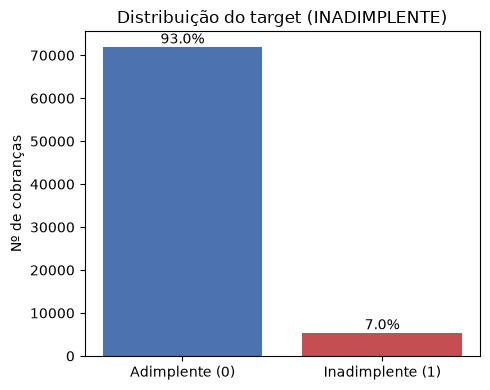

In [48]:
contagem = df3["INADIMPLENTE"].value_counts().sort_index()
proporcao = df3["INADIMPLENTE"].value_counts(normalize=True).sort_index() * 100
print(contagem, "\n")
print(proporcao.round(2))

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(["Adimplente (0)", "Inadimplente (1)"], contagem, color=["#4C72B0", "#C44E52"])
for i, v in enumerate(proporcao):
    ax.text(i, contagem.iloc[i], f"{v:.1f}%", ha="center", va="bottom")
ax.set_ylabel("Nº de cobranças")
ax.set_title("Distribuição do target (INADIMPLENTE)")
plt.tight_layout()
plt.show()

### SAFRA_REF	

2018-08 → 2021-06
Nº de safras: 35


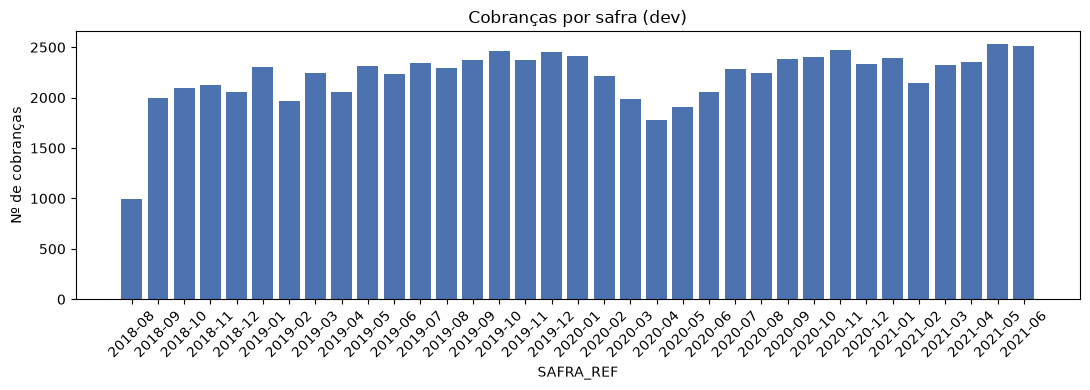

In [49]:
# mantida como string YYYY-MM.
print(df3["SAFRA_REF"].min(), "→", df3["SAFRA_REF"].max())
print("Nº de safras:", df3["SAFRA_REF"].nunique())

contagem = df3["SAFRA_REF"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(contagem.index, contagem.values, color="#4C72B0")
ax.set_xlabel("SAFRA_REF")
ax.set_ylabel("Nº de cobranças")
ax.set_title("Cobranças por safra (dev)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### DATA_EMISSAO_DOCUMENTO

2018-08-17 00:00:00 → 2021-06-30 00:00:00


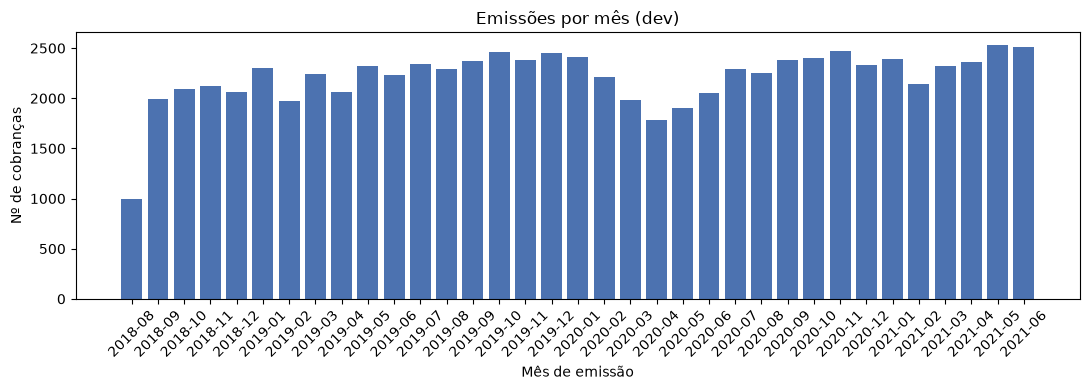

In [50]:
print(df3["DATA_EMISSAO_DOCUMENTO"].min(), "→", df3["DATA_EMISSAO_DOCUMENTO"].max())

por_mes = df3["DATA_EMISSAO_DOCUMENTO"].dt.to_period("M").value_counts().sort_index()
fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(por_mes.index.astype(str), por_mes.values, color="#4C72B0")
ax.set_xlabel("Mês de emissão")
ax.set_ylabel("Nº de cobranças")
ax.set_title("Emissões por mês (dev)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### DATA_PAGAMENTO

2018-06-19 00:00:00 → 2021-11-24 00:00:00
Nulos: 0


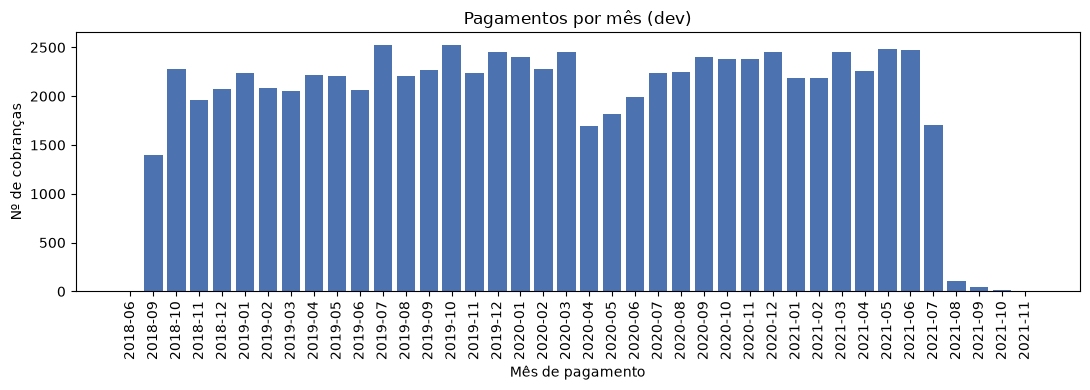

In [51]:
print(df3["DATA_PAGAMENTO"].min(), "→", df3["DATA_PAGAMENTO"].max())
print("Nulos:", df3["DATA_PAGAMENTO"].isna().sum())

por_mes = df3["DATA_PAGAMENTO"].dt.to_period("M").value_counts().sort_index()
fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(por_mes.index.astype(str), por_mes.values, color="#4C72B0")
ax.set_xlabel("Mês de pagamento")
ax.set_ylabel("Nº de cobranças")
ax.set_title("Pagamentos por mês (dev)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### DATA_VENCIMENTO

2017-11-27 00:00:00 → 2027-03-31 00:00:00


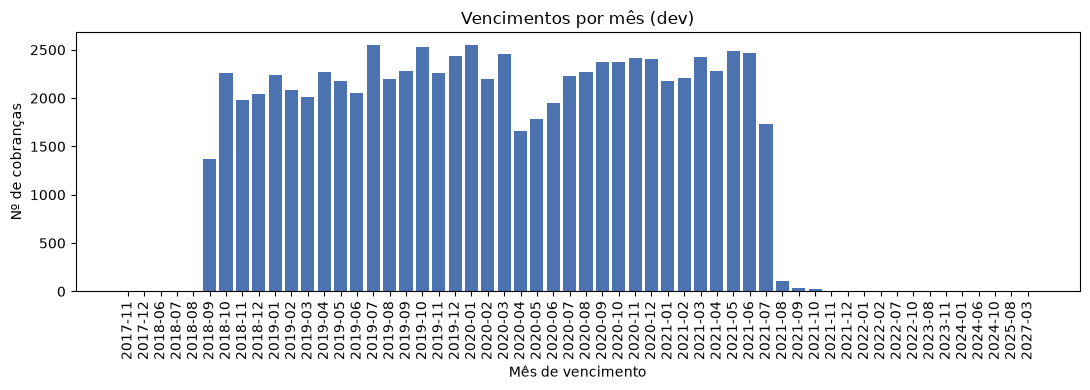

In [52]:
print(df3["DATA_VENCIMENTO"].min(), "→", df3["DATA_VENCIMENTO"].max())

por_mes = df3["DATA_VENCIMENTO"].dt.to_period("M").value_counts().sort_index()
fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(por_mes.index.astype(str), por_mes.values, color="#4C72B0")
ax.set_xlabel("Mês de vencimento")
ax.set_ylabel("Nº de cobranças")
ax.set_title("Vencimentos por mês (dev)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### VALOR_A_PAGAR

count      76244.00
mean       46590.78
std        46433.93
min            0.10
25%        18765.36
50%        34758.69
75%        60933.84
max      4400000.00
Name: VALOR_A_PAGAR, dtype: str
Nulos: 1170 (2% de nulos)


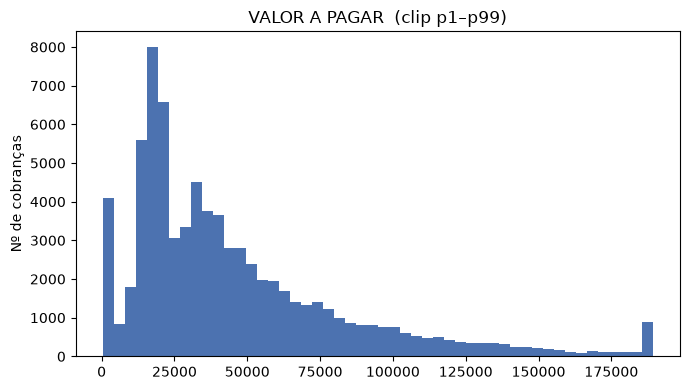

In [53]:
hist_continua(df3["VALOR_A_PAGAR"], "VALOR A PAGAR")

### TAXA

TAXA
5.99     26459
6.99     22021
4.99     15703
8.99      7934
11.99     5297
Name: count, dtype: int64
Nulos: 0 (0% de nulos)


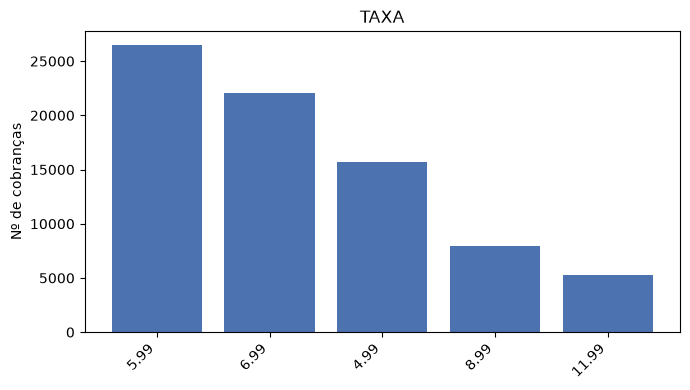

In [54]:
bar_categorica(df3["TAXA"], "TAXA")

### FLAG_PF

FLAG_PF
0    77195
1      219
Name: count, dtype: int64
Nulos: 0 (0% de nulos)


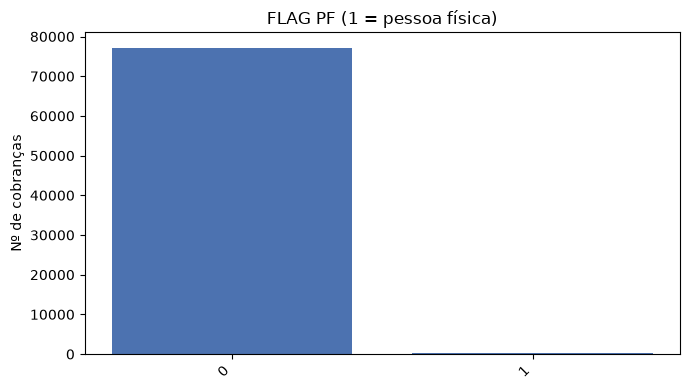

In [55]:
# só ~0,28% são PF
bar_categorica(df3["FLAG_PF"], "FLAG PF (1 = pessoa física)")

### SEGMENTO_INDUSTRIAL

SEGMENTO_INDUSTRIAL
Serviços     31638
Comércio     27062
Indústria    17297
NaN           1417
Name: count, dtype: int64
Nulos: 1417 (2% de nulos)


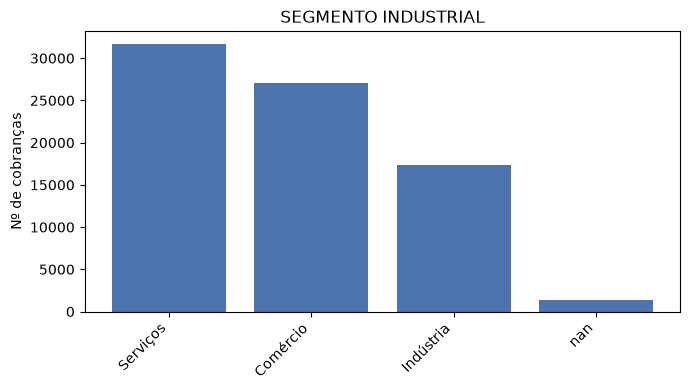

In [56]:
bar_categorica(df3["SEGMENTO_INDUSTRIAL"], "SEGMENTO INDUSTRIAL")

### DOMINIO_EMAIL

DOMINIO_EMAIL
YAHOO      25322
GMAIL      21407
HOTMAIL    18681
OUTLOOK     4808
AOL         4456
BOL         1842
NaN          898
Name: count, dtype: int64
Nulos: 898 (1% de nulos)


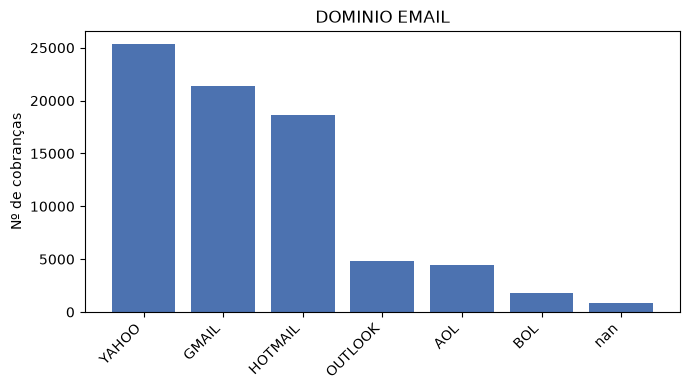

In [57]:
bar_categorica(df3["DOMINIO_EMAIL"], "DOMINIO EMAIL")

### PORTE

PORTE
MEDIO      29929
GRANDE     29032
PEQUENO    15977
NaN         2476
Name: count, dtype: int64
Nulos: 2476 (3% de nulos)


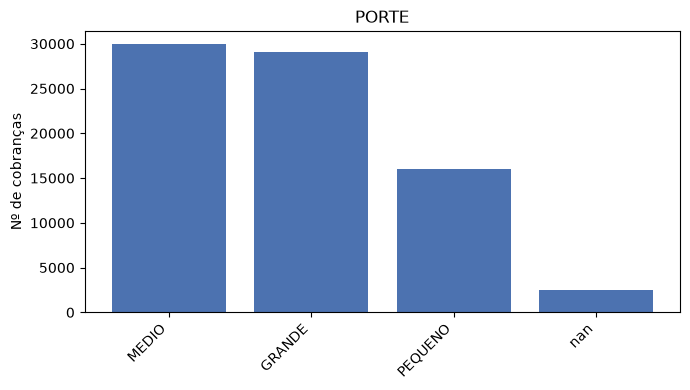

In [58]:
# Ordinal
bar_categorica(df3["PORTE"], "PORTE")

### RENDA_MES_ANTERIOR

count      71282.00
mean      291438.08
std       213293.16
min          105.00
25%       134074.25
50%       240502.00
75%       396250.00
max      1682759.00
Name: RENDA_MES_ANTERIOR, dtype: str
Nulos: 6132 (8% de nulos)


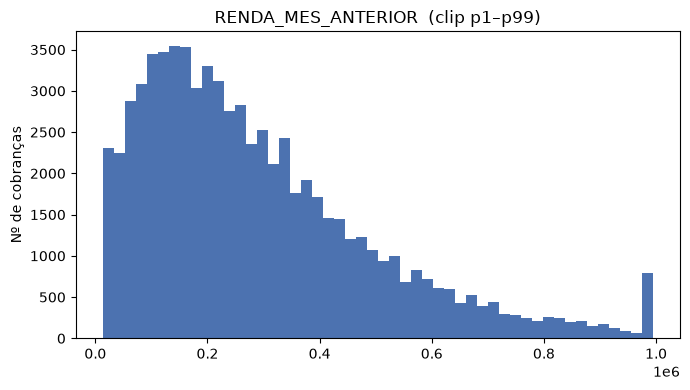

In [59]:
hist_continua(df3["RENDA_MES_ANTERIOR"], "RENDA_MES_ANTERIOR")

### NO_FUNCIONARIOS

count    69827.00
mean       117.69
std         18.78
min          0.00
25%        105.00
50%        118.00
75%        130.00
max        198.00
Name: NO_FUNCIONARIOS, dtype: str
Nulos: 7587 (10% de nulos)


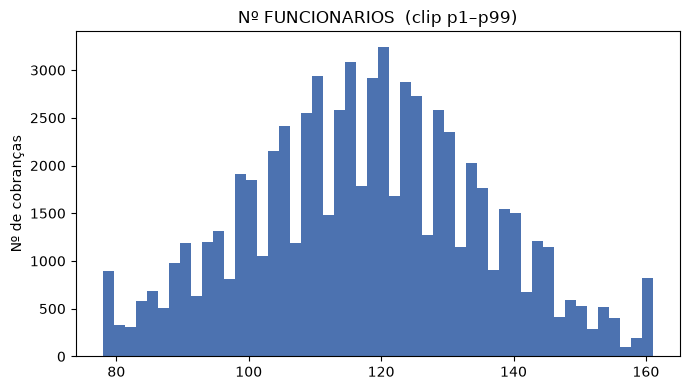

In [60]:
hist_continua(df3["NO_FUNCIONARIOS"], "Nº FUNCIONARIOS")

### DIAS_FIDELIDADE

count    77414.00
mean      3588.47
std       2270.39
min        -13.00
25%       1840.00
50%       3112.00
75%       5447.00
max       7624.00
Name: DIAS_FIDELIDADE, dtype: str
Nulos: 0 (0% de nulos)


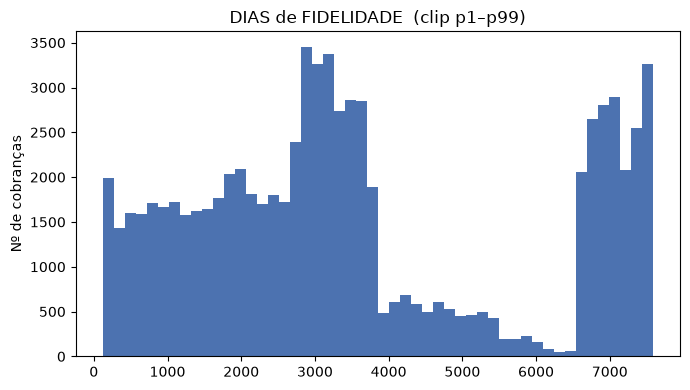

In [61]:
# DIAS_FIDELIDADE: maturidade do cliente na emissão (emissão − cadastro).
hist_continua(df3["DIAS_FIDELIDADE"], "DIAS de FIDELIDADE")

### DIAS_PARA_VENCIMENTO

Negativos: 27
count    77414.00
mean        23.32
std         26.14
min       -420.00
25%         16.00
50%         18.00
75%         24.00
max       2677.00
Name: DIAS_PARA_VENCIMENTO, dtype: str
Nulos: 0 (0% de nulos)


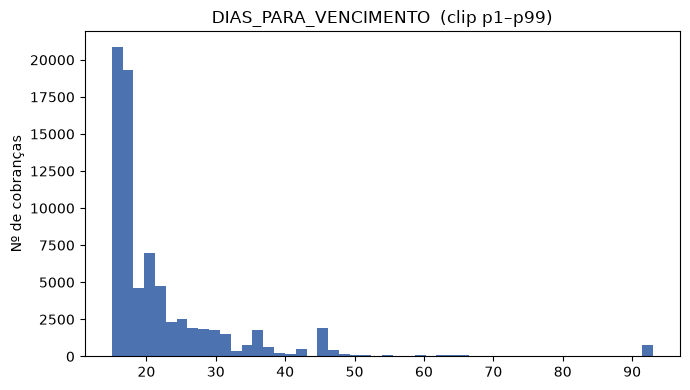

In [62]:
# Janela de pagamento (vencimento − emissão).
# expõe os 27 valores negativos (dívidas reemitidas/renegociadas): vencimento anterior à emissão. 
# Volume baixo: 0,03%

print("Negativos:", (df3["DIAS_PARA_VENCIMENTO"] < 0).sum())
hist_continua(df3["DIAS_PARA_VENCIMENTO"], "DIAS_PARA_VENCIMENTO", p_low=1, p_high=99)

### VALOR_SOBRE_RENDA

count    70210.00
mean         0.43
std          5.14
min          0.00
25%          0.07
50%          0.15
75%          0.34
max        683.12
Name: VALOR_SOBRE_RENDA, dtype: str
Nulos: 7204 (9% de nulos)


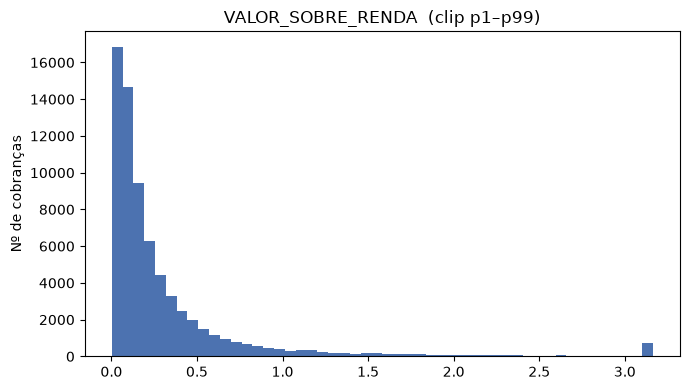

In [63]:
# omprometimento (valor / renda)
hist_continua(df3["VALOR_SOBRE_RENDA"], "VALOR_SOBRE_RENDA")

## 3.2 Bivariate Analysis

### SAFRA_REF	

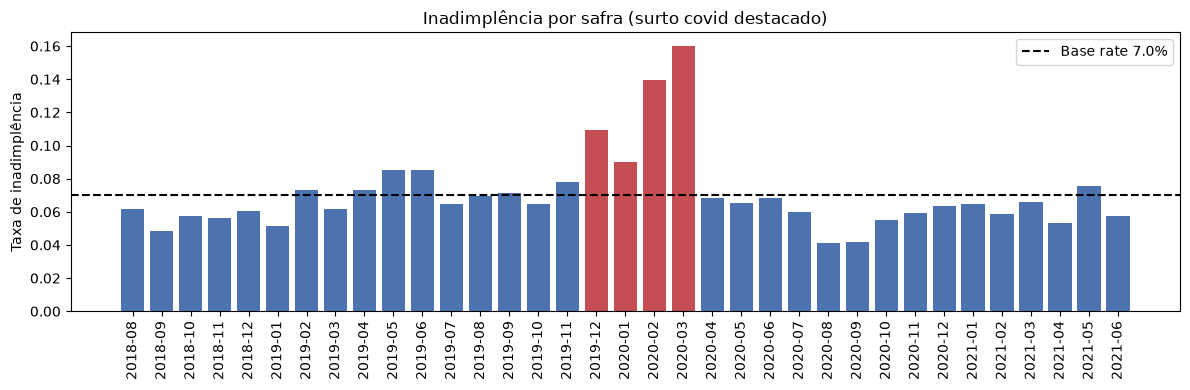

In [64]:
# A TAXA de inadimplência por safra sobe no surto?
taxa_safra = df3.groupby("SAFRA_REF")["INADIMPLENTE"].mean()

base_rate = df3["INADIMPLENTE"].mean()
TOTAL_INAD = df3["INADIMPLENTE"].sum()

fig, ax = plt.subplots(figsize=(12, 4))
cores = ["#C44E52" if "2019-12" <= s <= "2020-03" else "#4C72B0" for s in taxa_safra.index]
ax.bar(taxa_safra.index, taxa_safra.values, color=cores)
ax.axhline(base_rate, color="black", linestyle="--", label=f"Base rate {base_rate:.1%}")
ax.set_ylabel("Taxa de inadimplência")
ax.set_title("Inadimplência por safra (surto covid destacado)")
ax.legend()
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

             taxa     n  inadimplentes  %_do_total
SAFRA_REF                                         
2020-03    0.1603  1984            318         5.8
2020-02    0.1398  2210            309         5.7
2019-12    0.1095  2448            268         4.9
2020-01    0.0899  2414            217         4.0
2019-05    0.0855  2317            198         3.6
2021-05    0.0755  2531            191         3.5
2019-06    0.0852  2231            190         3.5
2019-11    0.0782  2377            186         3.4
2019-09    0.0712  2373            169         3.1
2019-10    0.0645  2464            159         2.9
2019-08    0.0694  2291            159         2.9
2021-01    0.0648  2393            155         2.9
2021-03    0.0662  2326            154         2.8
2019-07    0.0644  2343            151         2.8
2019-04    0.0734  2058            151         2.8
2020-12    0.0635  2332            148         2.7
2020-11    0.0591  2471            146         2.7
2021-06    0.0577  2513        

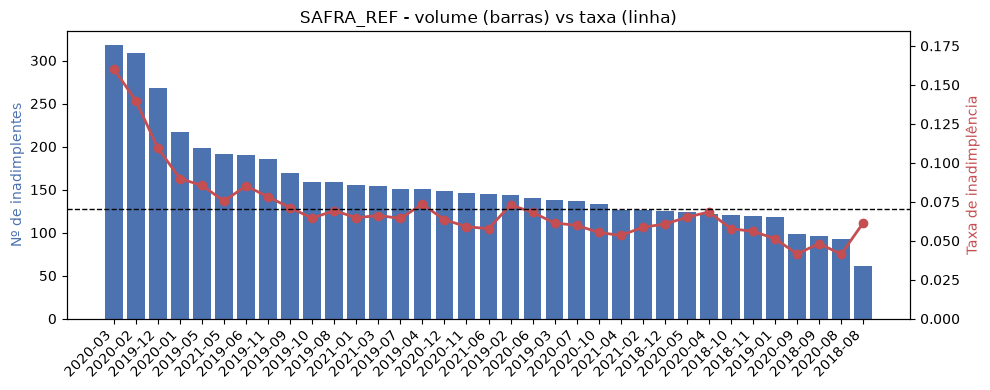

In [65]:
# SAFRA_REF: onde a inadimplência se acumulou ao longo do tempo.
volume_por_categoria("SAFRA_REF", "SAFRA_REF")

### VALOR_A_PAGAR

Nulos excluídos: 1170


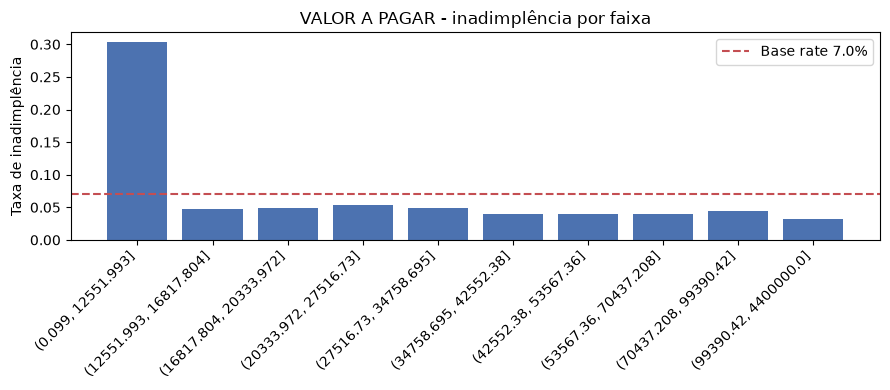

In [66]:
taxa_por_faixa("VALOR_A_PAGAR", "VALOR A PAGAR")

                           mean  size
sub                                  
(0.099, 499.0]         0.696382   774
(499.0, 945.6]         0.381969   843
(945.6, 1182.0]        0.248983  1229
(1182.0, 1380.078]     0.392157   204
(1380.078, 3263.0]     0.419397   763
(3263.0, 6663.61]      0.399738   763
(6663.61, 9253.28]     0.215223   762
(9253.28, 11023.616]   0.223097   762
(11023.616, 11934.53]  0.065617   762
(11934.53, 12551.99]   0.073394   763


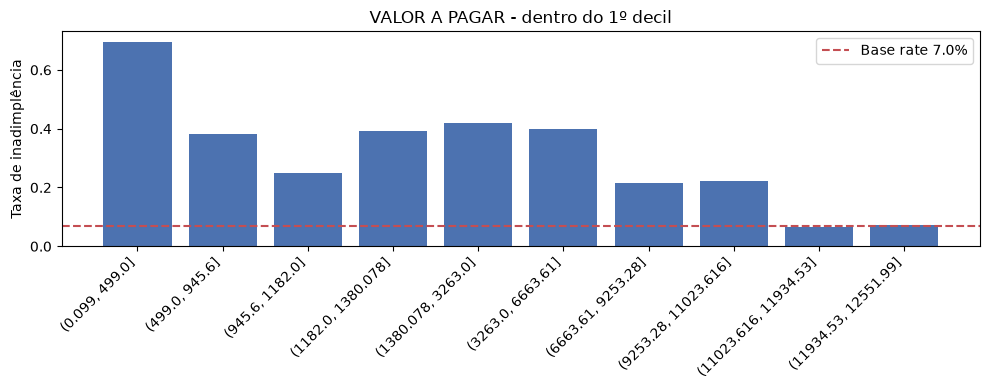

In [67]:
faixa1 = df3[df3["VALOR_A_PAGAR"] <= df3["VALOR_A_PAGAR"].quantile(0.10)].copy()
faixa1["sub"] = pd.qcut(faixa1["VALOR_A_PAGAR"], 10, duplicates="drop")
sub = faixa1.groupby("sub", observed=True)["INADIMPLENTE"].agg(["mean", "size"])
print(sub)
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(len(sub)), sub["mean"], color="#4C72B0")
ax.axhline(base_rate, color="#C44E52", linestyle="--", label=f"Base rate {base_rate:.1%}")
ax.set_xticks(range(len(sub)))
ax.set_xticklabels([str(i) for i in sub.index], rotation=45, ha="right")
ax.set_ylabel("Taxa de inadimplência")
ax.set_title("VALOR A PAGAR - dentro do 1º decil")
ax.legend()
plt.tight_layout()
plt.show()

                          mean  size
sub                                 
(0.099, 300.0]        0.683938   386
(300.0, 499.0]        0.708763   388
(499.0, 756.48]       0.459677   372
(756.48, 945.6]       0.320594   471
(945.6, 999.0]        0.182825   361
(999.0, 1182.0]       0.276498   868
(1182.0, 1380.078]    0.392157   204
(1380.078, 2228.382]  0.396325   381
(2228.382, 3263.0]    0.442408   382


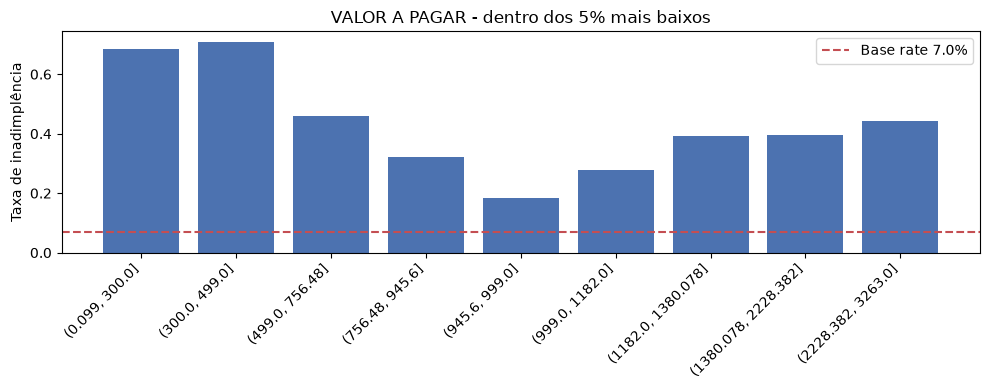

In [68]:
faixa1 = df3[df3["VALOR_A_PAGAR"] <= df3["VALOR_A_PAGAR"].quantile(0.05)].copy()
faixa1["sub"] = pd.qcut(faixa1["VALOR_A_PAGAR"], 10, duplicates="drop")
sub = faixa1.groupby("sub", observed=True)["INADIMPLENTE"].agg(["mean", "size"])
print(sub)
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(len(sub)), sub["mean"], color="#4C72B0")
ax.axhline(base_rate, color="#C44E52", linestyle="--", label=f"Base rate {base_rate:.1%}")
ax.set_xticks(range(len(sub)))
ax.set_xticklabels([str(i) for i in sub.index], rotation=45, ha="right")
ax.set_ylabel("Taxa de inadimplência")
ax.set_title("VALOR A PAGAR - dentro dos 5% mais baixos")
ax.legend()
plt.tight_layout()
plt.show()

                        mean  size
sub                               
(0.099, 225.4]      0.712281   285
(225.4, 360.0]      0.706485   293
(360.0, 587.97]     0.594203   276
(587.97, 756.0]     0.466899   287
(756.0, 935.5]      0.292929   297
(935.5, 982.65]     0.311111   270
(982.65, 1003.355]  0.193662   284
(1003.355, 1182.0]  0.272834   854


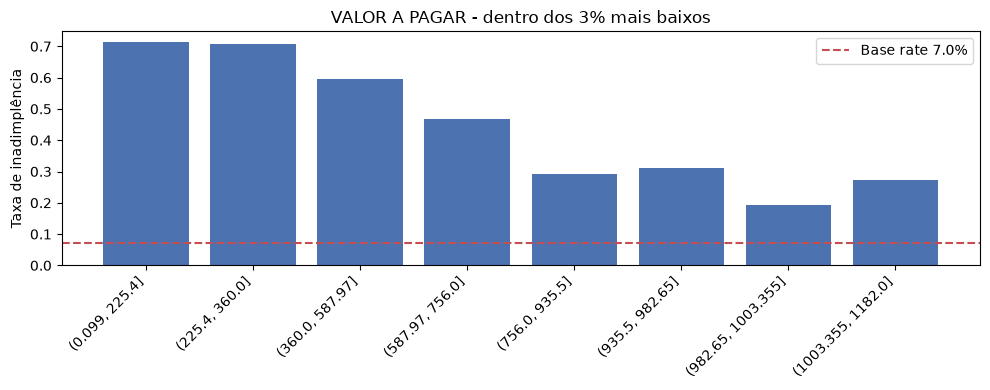

In [69]:
faixa1 = df3[df3["VALOR_A_PAGAR"] <= df3["VALOR_A_PAGAR"].quantile(0.03)].copy()
faixa1["sub"] = pd.qcut(faixa1["VALOR_A_PAGAR"], 10, duplicates="drop")
sub = faixa1.groupby("sub", observed=True)["INADIMPLENTE"].agg(["mean", "size"])
print(sub)
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(len(sub)), sub["mean"], color="#4C72B0")
ax.axhline(base_rate, color="#C44E52", linestyle="--", label=f"Base rate {base_rate:.1%}")
ax.set_xticks(range(len(sub)))
ax.set_xticklabels([str(i) for i in sub.index], rotation=45, ha="right")
ax.set_ylabel("Taxa de inadimplência")
ax.set_title("VALOR A PAGAR - dentro dos 3% mais baixos")
ax.legend()
plt.tight_layout()
plt.show()

                        mean  size
sub                               
(0.099, 56.685]     0.807692    78
(56.685, 127.924]   0.818182    77
(127.924, 196.95]   0.649351    77
(196.95, 250.0]     0.543210    81
(250.0, 302.09]     0.608108    74
(302.09, 360.0]     0.759162   191
(360.0, 396.396]    0.682927    41
(396.396, 470.313]  0.662338    77
(470.313, 499.0]    0.641026    78


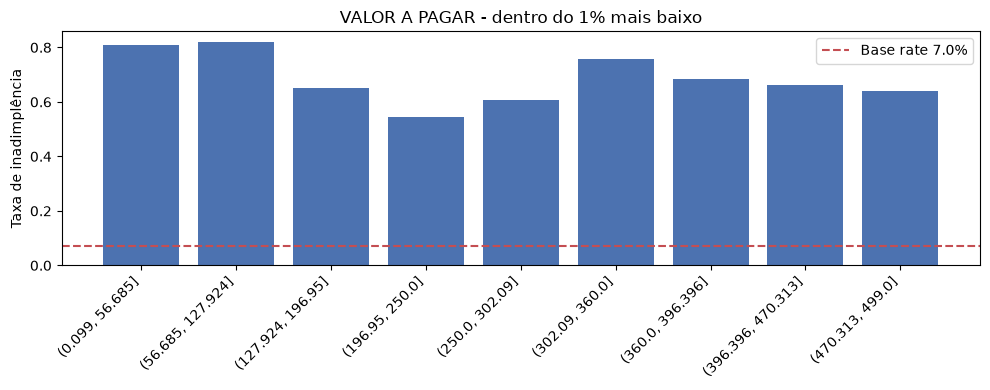

In [70]:
faixa1 = df3[df3["VALOR_A_PAGAR"] <= df3["VALOR_A_PAGAR"].quantile(0.01)].copy()
faixa1["sub"] = pd.qcut(faixa1["VALOR_A_PAGAR"], 10, duplicates="drop")
sub = faixa1.groupby("sub", observed=True)["INADIMPLENTE"].agg(["mean", "size"])
print(sub)
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(len(sub)), sub["mean"], color="#4C72B0")
ax.axhline(base_rate, color="#C44E52", linestyle="--", label=f"Base rate {base_rate:.1%}")
ax.set_xticks(range(len(sub)))
ax.set_xticklabels([str(i) for i in sub.index], rotation=45, ha="right")
ax.set_ylabel("Taxa de inadimplência")
ax.set_title("VALOR A PAGAR - dentro do 1% mais baixo")
ax.legend()
plt.tight_layout()
plt.show()

In [71]:
bins = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
tmp = df3[df3["VALOR_A_PAGAR"] <= 100].copy()
tmp["faixa"] = pd.cut(tmp["VALOR_A_PAGAR"], bins)
vb = tmp.groupby("faixa", observed=True)["INADIMPLENTE"].agg(["mean", "size"])
print(vb)
print("\nTotal de cobranças <= R$100:", len(tmp))

               mean  size
faixa                    
(0, 10]    0.928571    14
(10, 20]   0.944444    18
(20, 30]   0.692308    13
(30, 40]   0.727273    11
(40, 50]   0.833333    12
(50, 60]   0.705882    17
(60, 70]   0.833333     6
(70, 80]   0.750000    12
(80, 90]   0.857143     7
(90, 100]  0.923077    13

Total de cobranças <= R$100: 123


Zeros: 0 | Nulos: 1170
                          taxa     n  inadimplentes  %_do_total
VALOR_A_PAGAR                                                  
(0.099, 12551.993]      0.3032  7625           2312        42.5
(12551.993, 16817.804]  0.0479  7624            365         6.7
(16817.804, 20333.972]  0.0485  7624            370         6.8
(20333.972, 27516.73]   0.0532  7625            406         7.5
(27516.73, 34758.695]   0.0485  7624            370         6.8
(34758.695, 42552.38]   0.0400  7624            305         5.6
(42552.38, 53567.36]    0.0405  7626            309         5.7
(53567.36, 70437.208]   0.0395  7623            301         5.5
(70437.208, 99390.42]   0.0451  7624            344         6.3
(99390.42, 4400000.0]   0.0320  7625            244         4.5
NULO                    0.0940  1170            110         2.0


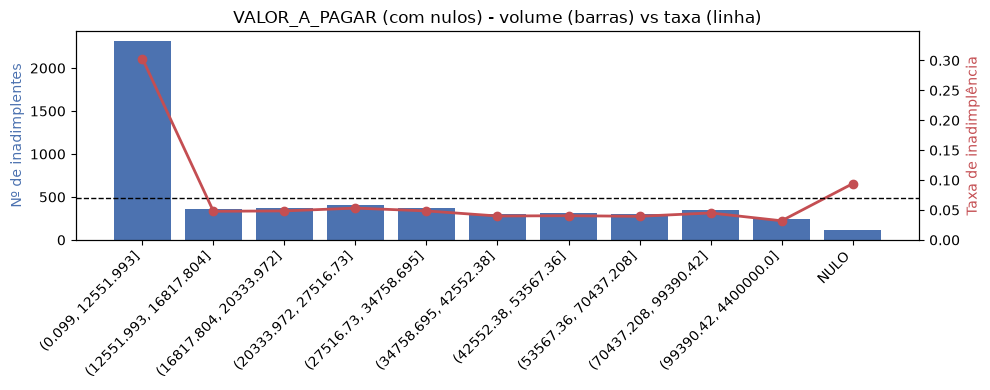

In [72]:
print("Zeros:", (df3["VALOR_A_PAGAR"] == 0).sum(),
      "| Nulos:", df3["VALOR_A_PAGAR"].isna().sum())

volume_por_faixa_com_nulos("VALOR_A_PAGAR", "VALOR_A_PAGAR (com nulos)")

### TAXA

         taxa      n
TAXA                
8.99   0.0763   7934
11.99  0.0757   5297
6.99   0.0748  22021
4.99   0.0699  15703
5.99   0.0637  26459


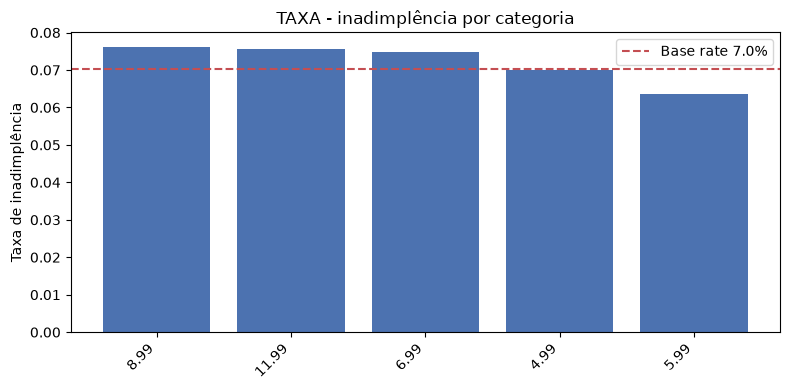

In [73]:
taxa_por_categoria("TAXA", "TAXA")

         taxa      n  inadimplentes  %_do_total
TAXA                                           
5.99   0.0637  26459           1685        31.0
6.99   0.0748  22021           1647        30.3
4.99   0.0699  15703           1098        20.2
8.99   0.0763   7934            605        11.1
11.99  0.0757   5297            401         7.4


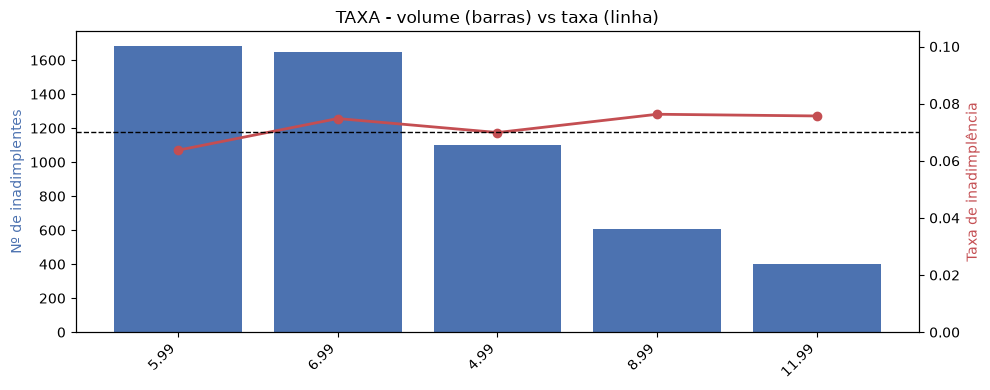

In [74]:
volume_por_categoria("TAXA", "TAXA")

### FLAG_PF

           taxa      n
FLAG_PF               
1        0.2009    219
0        0.0698  77195


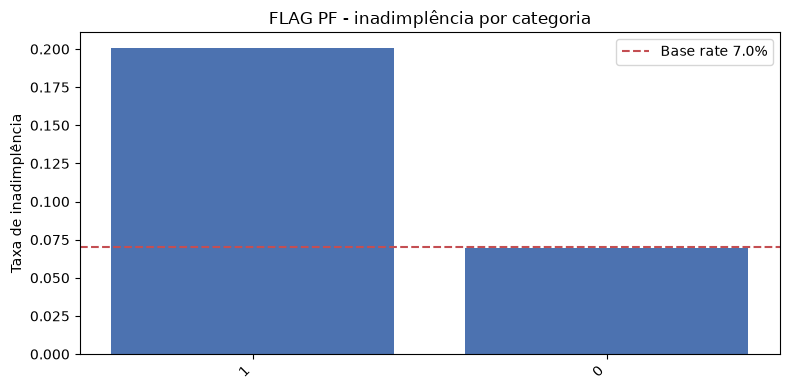

In [75]:
taxa_por_categoria("FLAG_PF", "FLAG PF")

           taxa      n  inadimplentes  %_do_total
FLAG_PF                                          
0        0.0698  77195           5392        99.2
1        0.2009    219             44         0.8


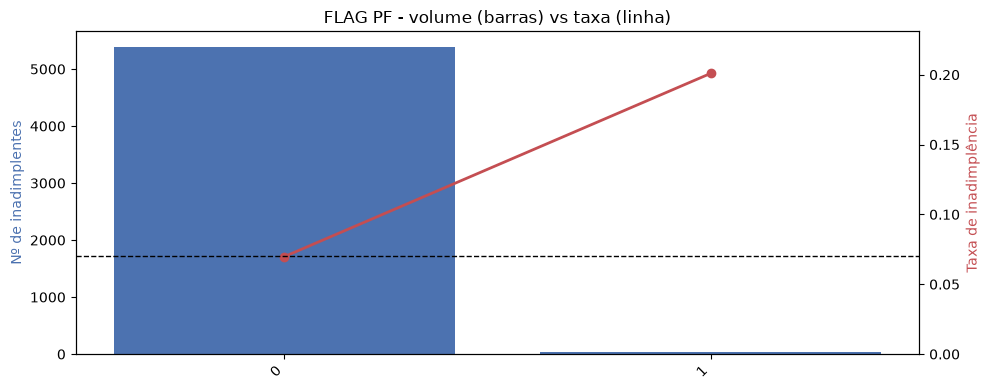

In [76]:
# FLAG_PF: taxa ~20%, mas só 219 cobranças. Volume mostra o quão marginal é.
volume_por_categoria("FLAG_PF", "FLAG PF")

### SEGMENTO_INDUSTRIAL

                       taxa      n
SEGMENTO_INDUSTRIAL               
Serviços             0.0875  31638
Indústria            0.0765  17297
NULO                 0.0734   1417
Comércio             0.0459  27062


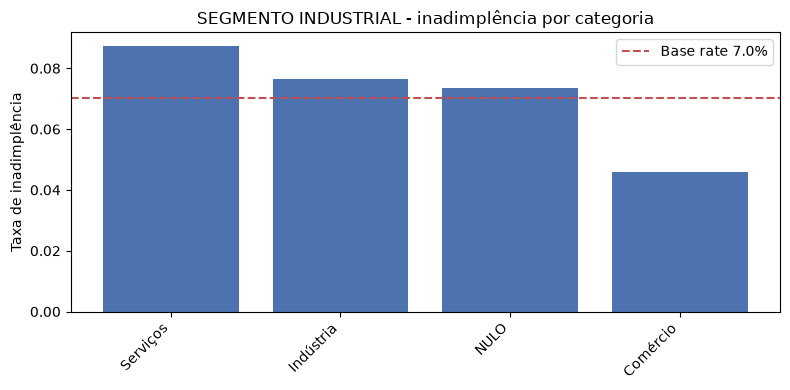

In [77]:
taxa_por_categoria("SEGMENTO_INDUSTRIAL", "SEGMENTO INDUSTRIAL")

                       taxa      n  inadimplentes  %_do_total
SEGMENTO_INDUSTRIAL                                          
Serviços             0.0875  31638           2767        50.9
Indústria            0.0765  17297           1323        24.3
Comércio             0.0459  27062           1242        22.8
NULO                 0.0734   1417            104         1.9


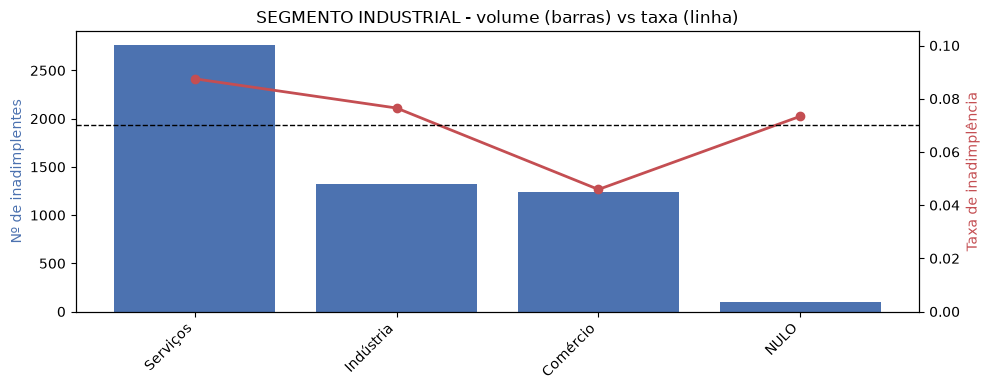

In [78]:
volume_por_categoria("SEGMENTO_INDUSTRIAL", "SEGMENTO INDUSTRIAL")

### DOMINIO_EMAIL

                 taxa      n
DOMINIO_EMAIL               
HOTMAIL        0.0926  18681
GMAIL          0.0740  21407
BOL            0.0727   1842
YAHOO          0.0596  25322
NULO           0.0590    898
OUTLOOK        0.0522   4808
AOL            0.0390   4456


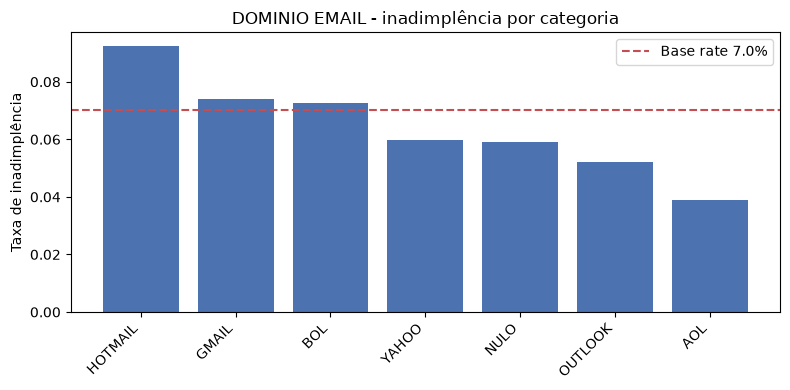

In [79]:
taxa_por_categoria("DOMINIO_EMAIL", "DOMINIO EMAIL")

                 taxa      n  inadimplentes  %_do_total
DOMINIO_EMAIL                                          
HOTMAIL        0.0926  18681           1729        31.8
GMAIL          0.0740  21407           1585        29.2
YAHOO          0.0596  25322           1510        27.8
OUTLOOK        0.0522   4808            251         4.6
AOL            0.0390   4456            174         3.2
BOL            0.0727   1842            134         2.5
NULO           0.0590    898             53         1.0


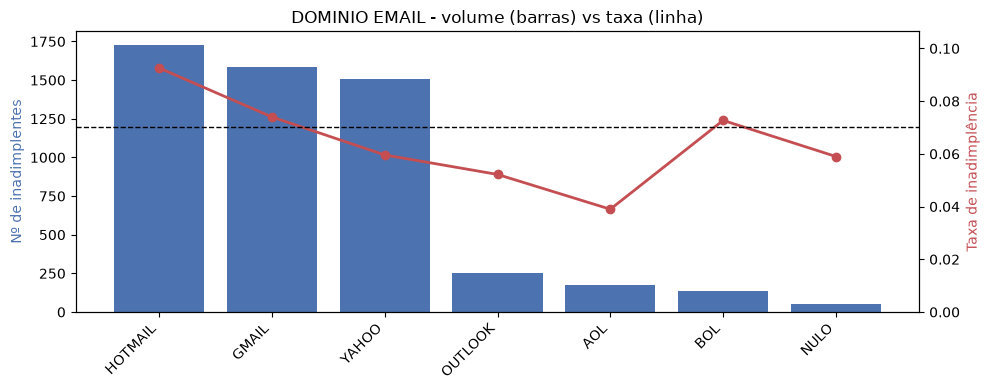

In [80]:
volume_por_categoria("DOMINIO_EMAIL", "DOMINIO EMAIL")

### PORTE

           taxa      n
PORTE                 
NULO     0.1749   2476
PEQUENO  0.0917  15977
MEDIO    0.0648  29929
GRANDE   0.0551  29032


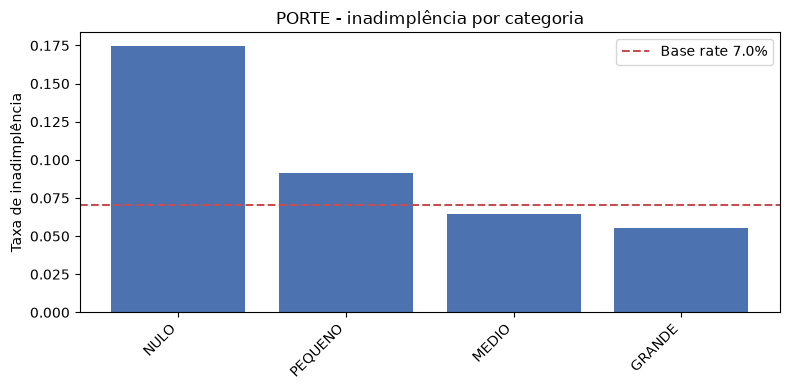

In [81]:
taxa_por_categoria("PORTE", "PORTE")

In [82]:
print("PORTE nulo x FLAG_PF (proporção por linha):")
print(pd.crosstab(df3["PORTE"].isna(), df3["FLAG_PF"], normalize="index").round(3))
print("\nInadimplência:")
for nome, mask in [("PORTE nulo", df3["PORTE"].isna()),
                   ("PORTE preenchido", df3["PORTE"].notna()),
                   ("FLAG_PF == 1", df3["FLAG_PF"].eq(1))]:
    print(f"{nome:18s}: taxa={df3.loc[mask,'INADIMPLENTE'].mean():.3f}  n={mask.sum()}")


# PORTE nulo NÃO marca pf. Nenhuma das 2.476 cobranças com PORTE nulo é PF (100% PJ), 
# e os 219 PF estão todos no grupo de PORTE preenchido. 

# A taxa alta (17,5% contra 6,7% de PORTE preenchido, 2,6x) sinaliza cadastro incompleto/risco maior.

PORTE nulo x FLAG_PF (proporção por linha):
FLAG_PF      0      1
PORTE                
False    0.997  0.003
True     1.000  0.000

Inadimplência:
PORTE nulo        : taxa=0.175  n=2476
PORTE preenchido  : taxa=0.067  n=74938
FLAG_PF == 1      : taxa=0.201  n=219


           taxa      n  inadimplentes  %_do_total
PORTE                                            
MEDIO    0.0648  29929           1938        35.7
GRANDE   0.0551  29032           1600        29.4
PEQUENO  0.0917  15977           1465        26.9
NULO     0.1749   2476            433         8.0


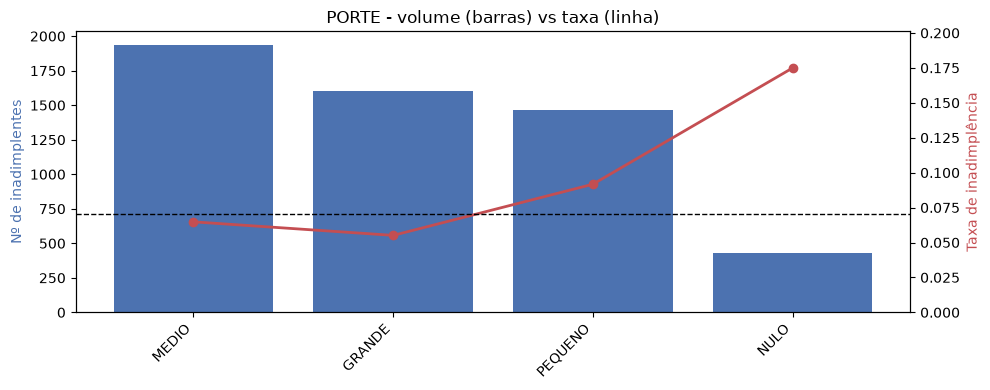

In [83]:
# PORTE: nulo tem taxa 17,5%; ver quanto da inadimplência total ele carrega.
volume_por_categoria("PORTE", "PORTE")

### RENDA_MES_ANTERIOR

Nulos excluídos: 6132


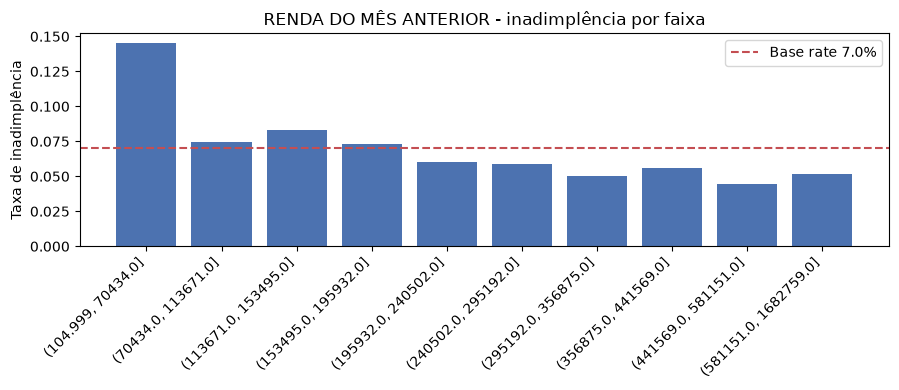

In [84]:
taxa_por_faixa("RENDA_MES_ANTERIOR", "RENDA DO MÊS ANTERIOR")

                        mean  size
sub                               
(104.999, 13845.0]  0.389344   732
(13845.0, 24053.0]  0.261119   697
(24053.0, 31618.0]  0.150281   712
(31618.0, 38640.0]  0.092179   716
(38640.0, 46088.0]  0.093969   713
(46088.0, 51216.0]  0.089888   712
(51216.0, 56314.0]  0.098748   719
(56314.0, 61586.0]  0.097320   709
(61586.0, 66264.0]  0.111878   724
(66264.0, 70434.0]  0.060000   700


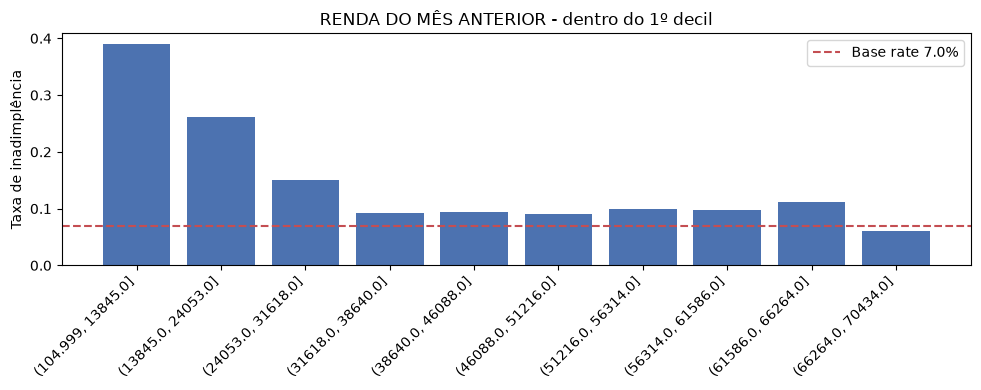

In [85]:
# Zoom no 1º decil de RENDA. Renda baixa = cliente mais frágil?
# Subdividir p/ ver se o risco cresce rumo às rendas mínimas.
faixa1 = df3[df3["RENDA_MES_ANTERIOR"] <= df3["RENDA_MES_ANTERIOR"].quantile(0.10)].copy()
faixa1["sub"] = pd.qcut(faixa1["RENDA_MES_ANTERIOR"], 10, duplicates="drop")
sub = faixa1.groupby("sub", observed=True)["INADIMPLENTE"].agg(["mean", "size"])
print(sub)
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(len(sub)), sub["mean"], color="#4C72B0")
ax.axhline(base_rate, color="#C44E52", linestyle="--", label=f"Base rate {base_rate:.1%}")
ax.set_xticks(range(len(sub)))
ax.set_xticklabels([str(i) for i in sub.index], rotation=45, ha="right")
ax.set_ylabel("Taxa de inadimplência")
ax.set_title("RENDA DO MÊS ANTERIOR - dentro do 1º decil")
ax.legend()
plt.tight_layout()
plt.show()

In [86]:
print("Renda < 105:", (df3["RENDA_MES_ANTERIOR"] < 104.999).sum())
print("Renda == 105 (mínimo):", (df3["RENDA_MES_ANTERIOR"] == 105).sum())
print("\ninadimplência por grupo:")
for nome, mask in [
    ("Renda nula", df3["RENDA_MES_ANTERIOR"].isna()),
    ("Renda == 105", df3["RENDA_MES_ANTERIOR"] == 105),
    ("Renda 105-70k (1º decil)", (df3["RENDA_MES_ANTERIOR"] > 105) & (df3["RENDA_MES_ANTERIOR"] <= 70434)),
    ("Renda > 70k", df3["RENDA_MES_ANTERIOR"] > 70434),
]:
    sub = df3.loc[mask, "INADIMPLENTE"]
    print(f"{nome:26s}: taxa={sub.mean():.3f}  n={mask.sum()}")

Renda < 105: 0
Renda == 105 (mínimo): 8

inadimplência por grupo:
Renda nula                : taxa=0.076  n=6132
Renda == 105              : taxa=0.125  n=8
Renda 105-70k (1º decil)  : taxa=0.145  n=7126
Renda > 70k               : taxa=0.061  n=64148


                         taxa     n  inadimplentes  %_do_total
RENDA_MES_ANTERIOR                                            
(104.999, 70434.0]     0.1449  7134           1034        19.0
(70434.0, 113671.0]    0.0747  7126            532         9.8
(113671.0, 153495.0]   0.0832  7127            593        10.9
(153495.0, 195932.0]   0.0731  7128            521         9.6
(195932.0, 240502.0]   0.0600  7130            428         7.9
(240502.0, 295192.0]   0.0590  7139            421         7.7
(295192.0, 356875.0]   0.0505  7115            359         6.6
(356875.0, 441569.0]   0.0557  7132            397         7.3
(441569.0, 581151.0]   0.0446  7123            318         5.8
(581151.0, 1682759.0]  0.0518  7128            369         6.8
NULO                   0.0757  6132            464         8.5


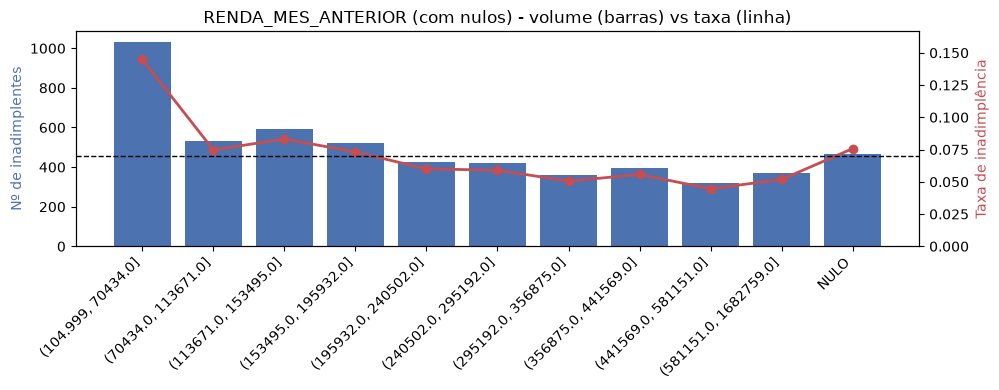

In [87]:
# RENDA_MES_ANTERIOR: renda baixa concentra taxa; ver se concentra volume também.

volume_por_faixa_com_nulos("RENDA_MES_ANTERIOR", "RENDA_MES_ANTERIOR (com nulos)")

### NO_FUNCIONARIOS

Nulos excluídos: 7587


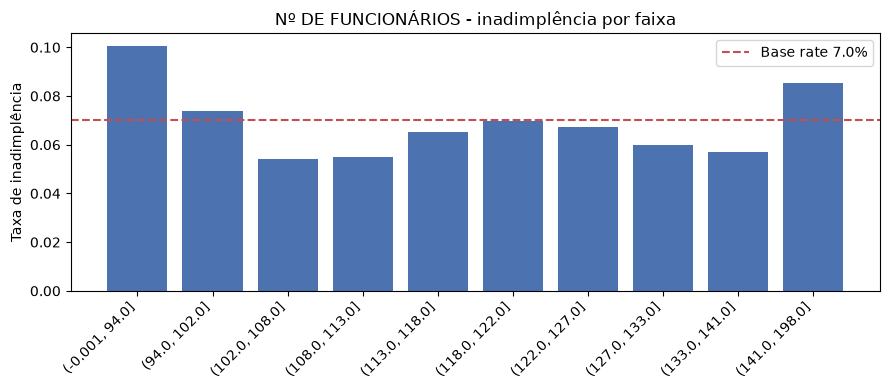

In [88]:
taxa_por_faixa("NO_FUNCIONARIOS", "Nº DE FUNCIONÁRIOS")

Zeros: 147 | Nulos: 7587
                   taxa     n  inadimplentes  %_do_total
NO_FUNCIONARIOS                                         
(59.999, 94.0]   0.0984  7152            704        13.0
(94.0, 102.0]    0.0738  6939            512         9.4
(102.0, 108.0]   0.0541  7003            379         7.0
(108.0, 113.0]   0.0550  6895            379         7.0
(113.0, 118.0]   0.0653  7770            507         9.3
(118.0, 122.0]   0.0697  6359            443         8.1
(122.0, 127.0]   0.0674  6873            463         8.5
(127.0, 133.0]   0.0600  7219            433         8.0
(133.0, 141.0]   0.0569  6594            375         6.9
(141.0, 198.0]   0.0855  6876            588        10.8
ZERO (PF)        0.2109   147             31         0.6
NULO             0.0820  7587            622        11.4


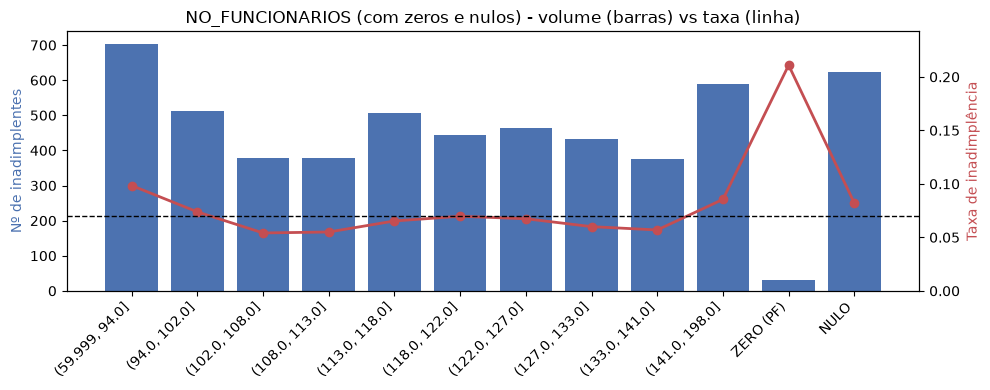

In [89]:
print("Zeros:", (df3["NO_FUNCIONARIOS"] == 0).sum(),
      "| Nulos:", df3["NO_FUNCIONARIOS"].isna().sum())

# Zero não é "poucos funcionários": é codificação de pessoa física (100% FLAG_PF=1).
# Deixá-lo dentro do 1º decil mistura duas populações, então vira faixa própria.
pos = df3["NO_FUNCIONARIOS"] > 0
faixa = pd.qcut(df3.loc[pos, "NO_FUNCIONARIOS"], 10)
faixa = faixa.cat.add_categories(["ZERO (PF)", "NULO"]).reindex(df3.index)
faixa[df3["NO_FUNCIONARIOS"].eq(0)] = "ZERO (PF)"
faixa[df3["NO_FUNCIONARIOS"].isna()] = "NULO"

g = df3.groupby(faixa, observed=True)["INADIMPLENTE"]
tab = pd.DataFrame({"taxa": g.mean().round(4), "n": g.size(), "inadimplentes": g.sum()})
tab["%_do_total"] = (tab["inadimplentes"] / TOTAL_INAD * 100).round(1)
print(tab)
_plot_volume(tab, "NO_FUNCIONARIOS (com zeros e nulos)")

In [90]:
# NO_FUNCIONARIOS: entender nulo vs ==0 separadamente.

print("NO_FUNC nulo x FLAG_PF:")
print(pd.crosstab(df3["NO_FUNCIONARIOS"].isna(), df3["FLAG_PF"], normalize="index").round(3))
print("\nNO_FUNC ==0 x FLAG_PF:")
print(pd.crosstab(df3["NO_FUNCIONARIOS"].eq(0), df3["FLAG_PF"], normalize="index").round(3))
print("\ninadimplência por grupo:")
for nome, mask in [("NO_FUNC nulo", df3["NO_FUNCIONARIOS"].isna()),
                   ("NO_FUNC == 0", df3["NO_FUNCIONARIOS"].eq(0)),
                   ("NO_FUNC > 0", df3["NO_FUNCIONARIOS"] > 0),
                   ("FLAG_PF == 1", df3["FLAG_PF"].eq(1))]:
    print(f"{nome:14s}: taxa={df3.loc[mask,'INADIMPLENTE'].mean():.3f}  n={mask.sum()}")


# CONCLUSÃO: zero e nulo NÃO são o mesmo fenômeno.
    
# - NO_FUNC == 0: 100% são pessoa física (FLAG_PF=1), e a taxa (21,1%) bate com
#   a de FLAG_PF=1 (20,1%). Zero não é "poucos funcionários": é uma categoria
#   disfarçada de número, já que PF não tem funcionários.
    
# - NO_FUNC nulo: 99,1% são pessoa jurídica e a taxa (8,2%) fica perto da base
#   rate (7,0%). É dado faltante comum, não marcador de PF.
    
# - A implicação vale num sentido só: zero => PF, mas PF não => zero. São 219 PF
#   dos quais 147 têm zero e 72 têm o campo nulo. Nenhum PF tem funcionários > 0.
    
# Consequências: NO_FUNC == 0 é redundante com FLAG_PF (manter FLAG_PF, que cobre
# mais casos), e o zero não pode ficar numa escala contínua ao lado de 94, 102...

NO_FUNC nulo x FLAG_PF:
FLAG_PF              0      1
NO_FUNCIONARIOS              
False            0.998  0.002
True             0.991  0.009

NO_FUNC ==0 x FLAG_PF:
FLAG_PF              0      1
NO_FUNCIONARIOS              
False            0.999  0.001
True             0.000  1.000

inadimplência por grupo:
NO_FUNC nulo  : taxa=0.082  n=7587
NO_FUNC == 0  : taxa=0.211  n=147
NO_FUNC > 0   : taxa=0.069  n=69680
FLAG_PF == 1  : taxa=0.201  n=219


In [91]:
grupo = pd.Series("> 0", index=df3.index)
grupo[df3["NO_FUNCIONARIOS"].isna()] = "nulo"
grupo[df3["NO_FUNCIONARIOS"].eq(0)] = "== 0 (PF)"
tmp = df3.assign(_g=grupo)
g = tmp.groupby("_g")["INADIMPLENTE"]
tab = pd.DataFrame({"taxa": g.mean().round(4), "n": g.size(), "inadimplentes": g.sum()})
tab["%_do_total"] = (tab["inadimplentes"] / TOTAL_INAD * 100).round(1)
print(tab.sort_values("inadimplentes", ascending=False))

# CONCLUSÃO: divergência entre taxa e volume.
# - == 0 (PF): maior taxa (21,1%, 3x a base rate), mas só 147 cobranças e 31
#   inadimplentes, 0,6% do problema. Sinal real, impacto operacional baixo.

# - nulo: taxa modesta (8,2%), porém 7.587 cobranças e 11,4% da inadimplência,
#   ou seja, 20x mais inadimplentes que o grupo zero.

# - > 0: menor taxa (6,9%) e 88% de toda a inadimplência, puro volume.
# Para cobrança, o grupo "interessante" (zero) é irrelevante e o grupo
# "sem graça" (> 0) é onde o problema realmente mora.

             taxa      n  inadimplentes  %_do_total
_g                                                 
> 0        0.0686  69680           4783        88.0
nulo       0.0820   7587            622        11.4
== 0 (PF)  0.2109    147             31         0.6


### MES_VENCIMENTO

                  taxa     n
MES_VENCIMENTO              
3               0.1145  6889
1               0.0801  6978
7               0.0798  6517
4               0.0793  6219
2               0.0740  6500
6               0.0682  6477
5               0.0622  6459
8               0.0611  4584
12              0.0561  6885
11              0.0556  6660
9               0.0551  6062
10              0.0529  7184


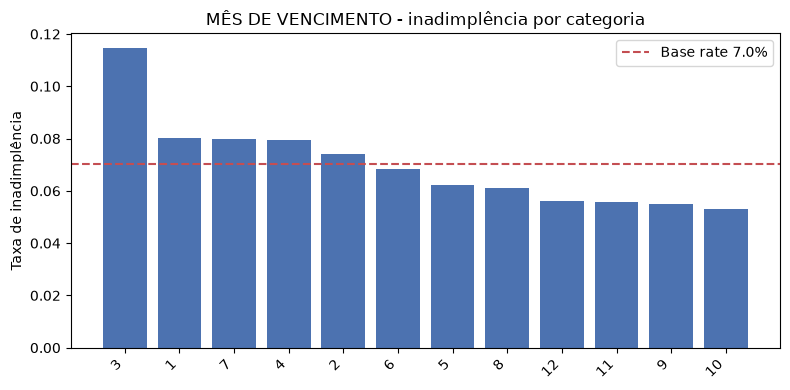

In [92]:
taxa_por_categoria("MES_VENCIMENTO", "MÊS DE VENCIMENTO")

### SEMANA_VENCIMENTO

Nulos excluídos: 0


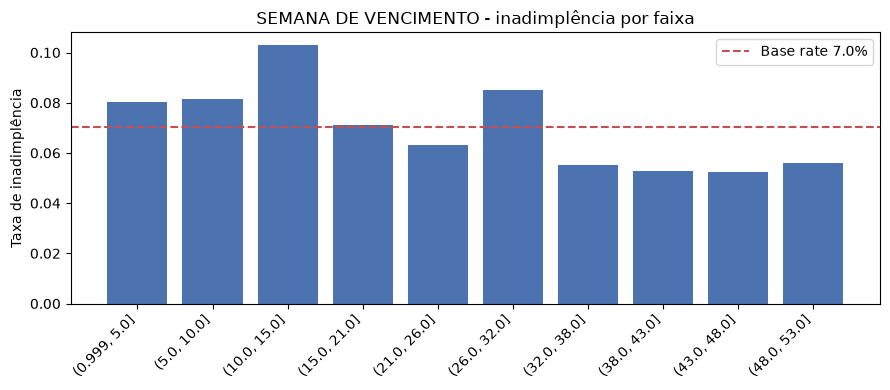

In [93]:
taxa_por_faixa("SEMANA_VENCIMENTO", "SEMANA DE VENCIMENTO", q=10)

### DIA_SEMANA_VENCIMENTO

                         taxa      n
DIA_SEMANA_VENCIMENTO               
5                      0.1673    281
6                      0.1642     67
2                      0.0916  13374
3                      0.0889  12386
4                      0.0780  11135
1                      0.0558  13432
0                      0.0536  26739


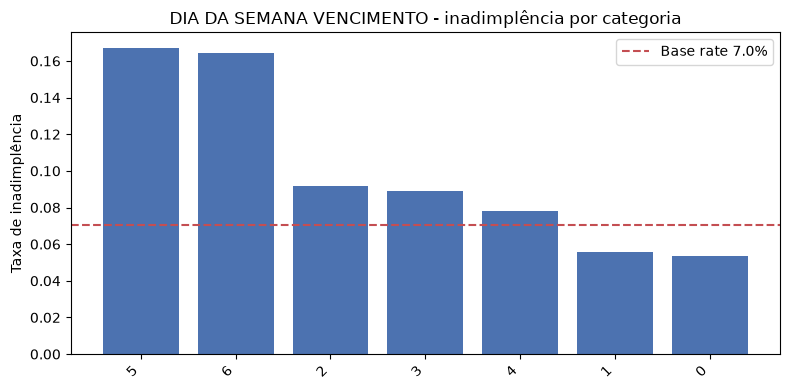

In [94]:
taxa_por_categoria("DIA_SEMANA_VENCIMENTO", "DIA DA SEMANA VENCIMENTO")

        taxa      n  inadimplentes  %_do_total
_dia                                          
0     0.0536  26739           1433        26.4
1     0.0558  13432            750        13.8
2     0.0916  13374           1225        22.5
3     0.0889  12386           1101        20.3
4     0.0780  11135            869        16.0
5     0.1673    281             47         0.9
6     0.1642     67             11         0.2


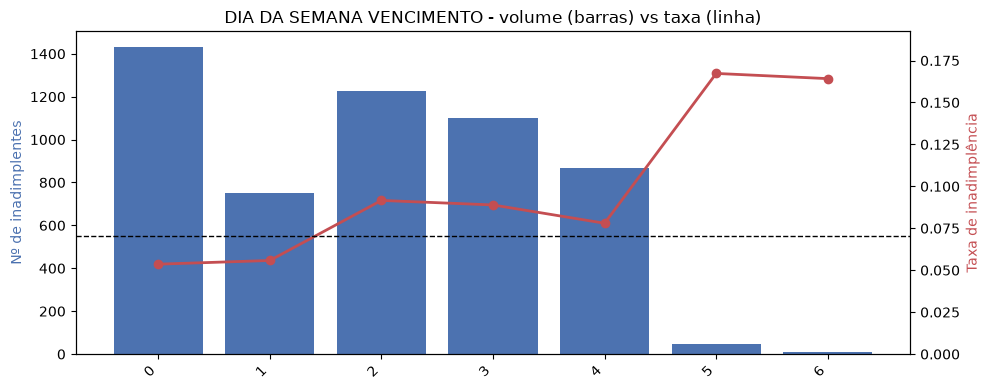

In [95]:
tmp = df3.assign(_dia=df3["DIA_SEMANA_VENCIMENTO"])
g = tmp.groupby("_dia")["INADIMPLENTE"]
tab = pd.DataFrame({"taxa": g.mean().round(4), "n": g.size(), "inadimplentes": g.sum()})
tab["%_do_total"] = (tab["inadimplentes"] / TOTAL_INAD * 100).round(1)
print(tab)
_plot_volume(tab, "DIA DA SEMANA VENCIMENTO")

### DIAS_FIDELIDADE

Nulos excluídos: 0


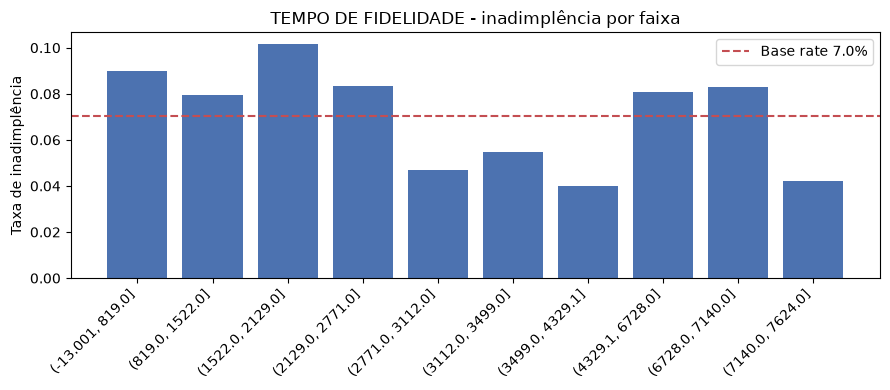

In [96]:
taxa_por_faixa("DIAS_FIDELIDADE", "TEMPO DE FIDELIDADE")

Taxa nesses bins: 0.082  n: 15487

Distribuição de safra DENTRO desses bins (top 12):
SAFRA_REF
2018-08    0.020
2018-09    0.042
2018-10    0.041
2018-11    0.040
2018-12    0.039
2019-01    0.045
2019-02    0.036
2019-03    0.042
2019-04    0.040
2019-05    0.047
2019-06    0.043
2019-07    0.046
2019-08    0.042
2019-09    0.049
2019-10    0.049
2019-11    0.046
2019-12    0.051
2020-01    0.045
2020-02    0.040
2020-03    0.014
2020-04    0.006
2020-05    0.010
2020-06    0.009
2020-07    0.011
2020-08    0.011
2020-09    0.012
2020-10    0.010
2020-11    0.013
2020-12    0.012
2021-01    0.014
2021-02    0.013
2021-03    0.015
2021-04    0.013
2021-05    0.016
2021-06    0.017
Name: proportion, dtype: float64


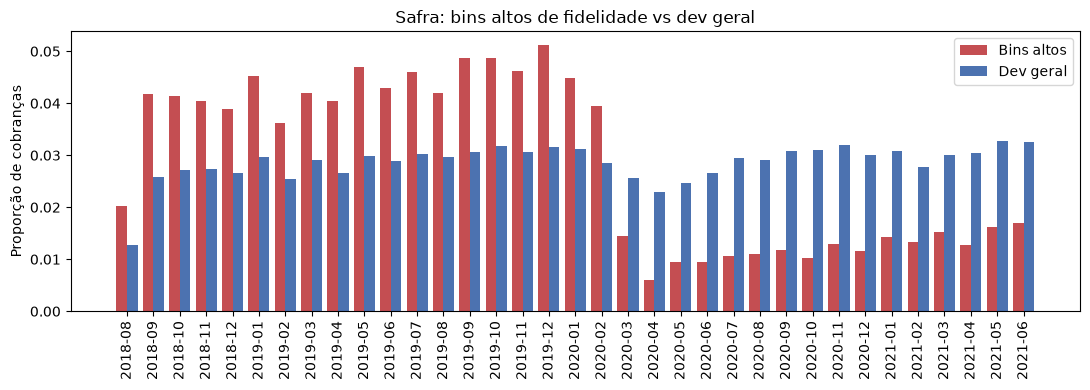

In [97]:
# Inadimplência cai com fidelidade, MAS dois bins altos (4329-6728, 6728-7140) sobem.
# Hipótese: efeito covid, não fidelidade. Se as cobranças desses bins se
# concentram nas safras de surto (2019-12 a 2020-03), a fidelidade é confundidor.
alvo = df3[(df3["DIAS_FIDELIDADE"] > 4329) & (df3["DIAS_FIDELIDADE"] <= 7140)].copy()
print("Taxa nesses bins:", alvo["INADIMPLENTE"].mean().round(3), " n:", len(alvo))
print("\nDistribuição de safra DENTRO desses bins (top 12):")
print(alvo["SAFRA_REF"].value_counts(normalize=True).sort_index().round(3))

# Comparar: a safra desses bins pende mais para o surto que o dev geral?
comp = pd.DataFrame({
    "nos_bins": alvo["SAFRA_REF"].value_counts(normalize=True),
    "geral": df3["SAFRA_REF"].value_counts(normalize=True),
}).fillna(0).sort_index()
fig, ax = plt.subplots(figsize=(11, 4))
x = range(len(comp))
ax.bar([i-0.2 for i in x], comp["nos_bins"], width=0.4, label="Bins altos", color="#C44E52")
ax.bar([i+0.2 for i in x], comp["geral"], width=0.4, label="Dev geral", color="#4C72B0")
ax.set_xticks(list(x)); ax.set_xticklabels(comp.index, rotation=90)
ax.set_ylabel("Proporção de cobranças")
ax.set_title("Safra: bins altos de fidelidade vs dev geral")
ax.legend(); plt.tight_layout(); plt.show()

                    taxa     n  inadimplentes  %_do_total
faixa                                                    
(-13.001, 819.0]  0.0901  7746            698        12.8
(819.0, 1522.0]   0.0794  7742            615        11.3
(1522.0, 2129.0]  0.1016  7745            787        14.5
(2129.0, 2771.0]  0.0832  7751            645        11.9
(2771.0, 3112.0]  0.0471  7734            364         6.7
(3112.0, 3499.0]  0.0549  7743            425         7.8
(3499.0, 4329.1]  0.0400  7729            309         5.7
(4329.1, 6728.0]  0.0808  7744            626        11.5
(6728.0, 7140.0]  0.0828  7743            641        11.8
(7140.0, 7624.0]  0.0421  7737            326         6.0
Nulos excluídos: 0


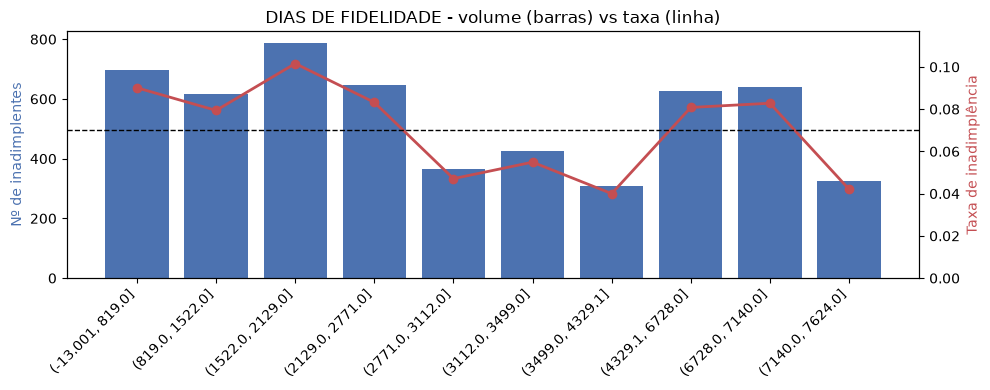

In [98]:
volume_por_faixa("DIAS_FIDELIDADE", "DIAS DE FIDELIDADE")

### DIAS_PARA_VENCIMENTO

                 mean   size
_janela_bin                 
(-9999, 0]   0.962963     27
(0, 20]      0.034683  49332
(20, 40]     0.097452  23078
(40, 60]     0.308878   3503
(60, 90]     0.313609    676
(90, 9999]   0.195489    798


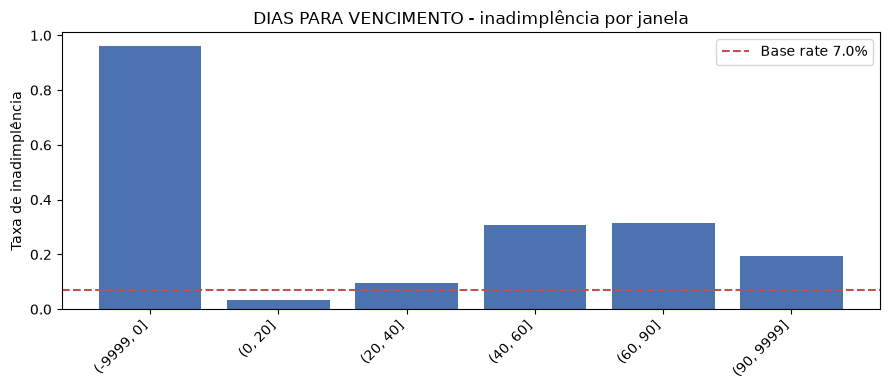

In [99]:
bins = [-9999, 0, 20, 40, 60, 90, 9999]
df3["_janela_bin"] = pd.cut(df3["DIAS_PARA_VENCIMENTO"], bins)
jb = df3.groupby("_janela_bin", observed=True)["INADIMPLENTE"].agg(["mean", "size"])
print(jb)
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar([str(i) for i in jb.index], jb["mean"], color="#4C72B0")
ax.axhline(base_rate, color="#C44E52", linestyle="--", label=f"Base rate {base_rate:.1%}")
ax.set_ylabel("Taxa de inadimplência")
ax.set_title("DIAS PARA VENCIMENTO - inadimplência por janela")
ax.legend(); plt.xticks(rotation=45, ha="right"); plt.tight_layout(); plt.show()
df3.drop(columns="_janela_bin", inplace=True)

              taxa      n  inadimplentes  %_do_total
faixa                                               
(-9999, 0]  0.9630     27             26         0.5
(0, 20]     0.0347  49332           1711        31.5
(20, 40]    0.0975  23078           2249        41.4
(40, 60]    0.3089   3503           1082        19.9
(60, 90]    0.3136    676            212         3.9
(90, 9999]  0.1955    798            156         2.9
Nulos excluídos: 0


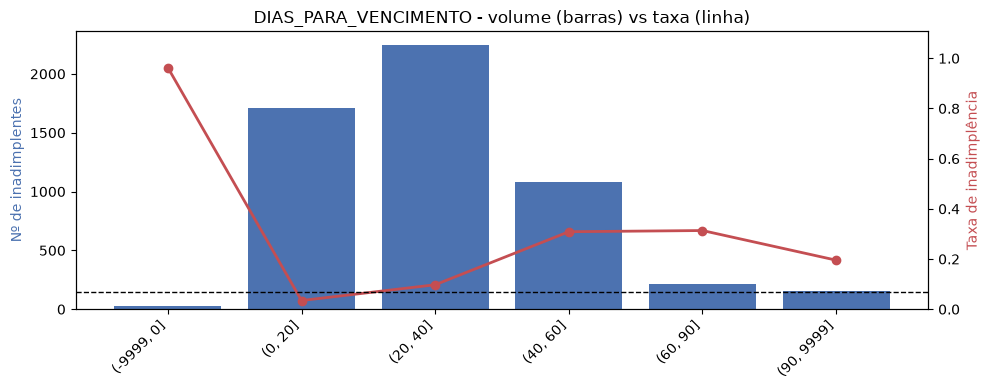

In [100]:
# DIAS_PARA_VENCIMENTO: o caso mais claro de divergência taxa x volume.
volume_por_faixa("DIAS_PARA_VENCIMENTO", "DIAS_PARA_VENCIMENTO",
                 bins=[-9999, 0, 20, 40, 60, 90, 9999])

### VALOR_SOBRE_RENDA

Nulos excluídos: 7204


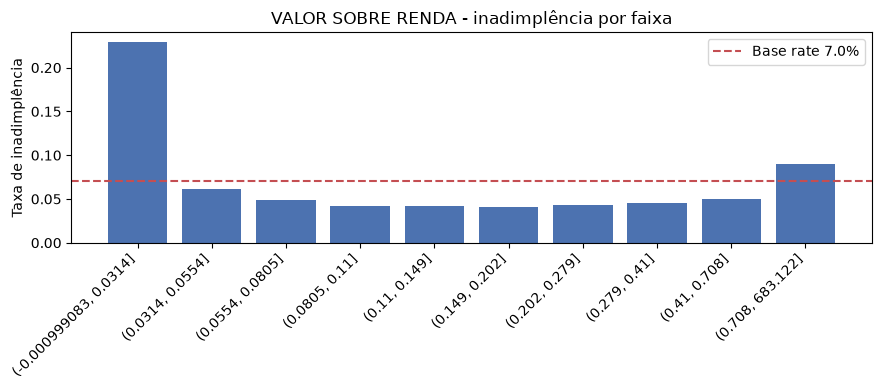

In [101]:
taxa_por_faixa("VALOR_SOBRE_RENDA", "VALOR SOBRE RENDA")

In [102]:
faixa1 = df3[df3["VALOR_SOBRE_RENDA"] <= df3["VALOR_SOBRE_RENDA"].quantile(0.10)].copy()
print("Taxa no 1º decil:", faixa1["INADIMPLENTE"].mean().round(3), " n:", len(faixa1))
print("\nVALOR_A_PAGAR dentro desse bin:")
print(faixa1["VALOR_A_PAGAR"].describe().round(2))
print("\n% do bin com VALOR_A_PAGAR < R$100:",
      (faixa1["VALOR_A_PAGAR"] < 100).mean().round(3))

Taxa no 1º decil: 0.229  n: 7021

VALOR_A_PAGAR dentro desse bin:
count     7021.00
mean      8238.17
std       7906.27
min          0.10
25%        999.00
50%       5634.41
75%      14844.68
max      44623.50
Name: VALOR_A_PAGAR, dtype: float64

% do bin com VALOR_A_PAGAR < R$100: 0.015


In [103]:
# 1º bin (ratio baixo) tem inadimplência 22.9%, e NÃO são centavos (só 1.5% < R$100).
# Ratio baixo = renda alta frente ao valor. Cruzar ratio x nível de renda p/ ver se o responsável é a renda alta no denominador.
faixa1 = df3[df3["VALOR_SOBRE_RENDA"] <= df3["VALOR_SOBRE_RENDA"].quantile(0.10)].copy()
print("Renda dentro do 1º decil do ratio:")
print(faixa1["RENDA_MES_ANTERIOR"].describe().round(0))
print("\nMediana de renda no dev geral:", df3["RENDA_MES_ANTERIOR"].median())

# Inadimplência dos NULOS de VALOR_SOBRE_RENDA (excluídos do plot):
nulo = df3["VALOR_SOBRE_RENDA"].isna()
print(f"\nVALOR_SOBRE_RENDA nulo: taxa={df3.loc[nulo,'INADIMPLENTE'].mean():.3f}  n={nulo.sum()}")
print(f"VALOR_SOBRE_RENDA preenchido: taxa={df3.loc[~nulo,'INADIMPLENTE'].mean():.3f}  n={(~nulo).sum()}")

Renda dentro do 1º decil do ratio:
count       7021.0
mean      482219.0
std       293313.0
min         3289.0
25%       240032.0
50%       456774.0
75%       672963.0
max      1682759.0
Name: RENDA_MES_ANTERIOR, dtype: float64

Mediana de renda no dev geral: 240502.0

VALOR_SOBRE_RENDA nulo: taxa=0.078  n=7204
VALOR_SOBRE_RENDA preenchido: taxa=0.069  n=70210


                      mean  size
sub                             
(0.707, 0.765]    0.056899   703
(0.765, 0.834]    0.047009   702
(0.834, 0.917]    0.076923   702
(0.917, 1.019]    0.051282   702
(1.019, 1.15]     0.066952   702
(1.15, 1.334]     0.068376   702
(1.334, 1.608]    0.088319   702
(1.608, 2.105]    0.088193   703
(2.105, 3.165]    0.141227   701
(3.165, 683.122]  0.213675   702


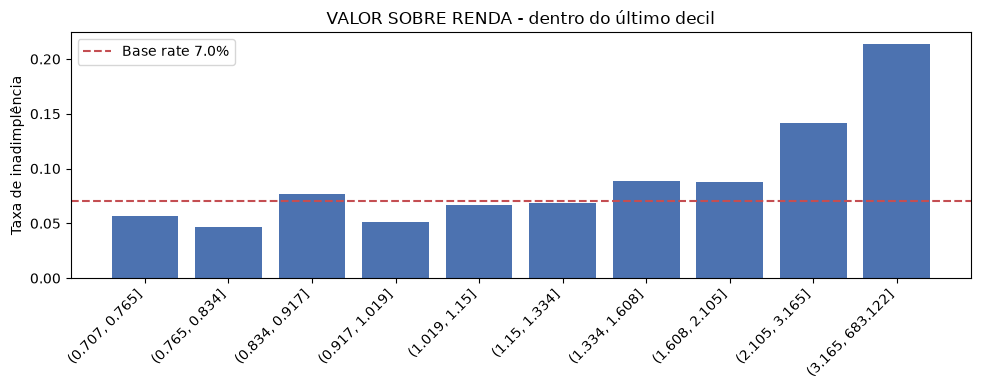

In [104]:
# Zoom no último decil de VALOR_SOBRE_RENDA (0.708 - 683). A faixa é larguíssima
# (3 ordens de grandeza), então pode misturar populações distintas. Subdividir
# para ver se a inadimplência é alta em toda a faixa ou só na cauda extrema.
ultimo = df3[df3["VALOR_SOBRE_RENDA"] > df3["VALOR_SOBRE_RENDA"].quantile(0.90)].copy()
ultimo["sub"] = pd.qcut(ultimo["VALOR_SOBRE_RENDA"], 10, duplicates="drop")
sub = ultimo.groupby("sub", observed=True)["INADIMPLENTE"].agg(["mean", "size"])
print(sub)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(len(sub)), sub["mean"], color="#4C72B0")
ax.axhline(base_rate, color="#C44E52", linestyle="--", label=f"Base rate {base_rate:.1%}")
ax.set_xticks(range(len(sub)))
ax.set_xticklabels([str(i) for i in sub.index], rotation=45, ha="right")
ax.set_ylabel("Taxa de inadimplência")
ax.set_title("VALOR SOBRE RENDA - dentro do último decil")
ax.legend()
plt.tight_layout()
plt.show()

In [105]:
# Quantas cobranças existem nos extremos e qual a inadimplência de cada corte.
for limite in [1, 2, 5, 10, 50, 100]:
    mask = df3["VALOR_SOBRE_RENDA"] > limite
    if mask.sum() > 0:
        print(f"ratio > {limite:>3}: taxa={df3.loc[mask,'INADIMPLENTE'].mean():.3f}  n={mask.sum()}")

# Peso da cauda dentro do último decil
ultimo = df3[df3["VALOR_SOBRE_RENDA"] > df3["VALOR_SOBRE_RENDA"].quantile(0.90)]
print(f"\nÚltimo decil: n={len(ultimo)}, taxa={ultimo['INADIMPLENTE'].mean():.3f}")
print(f"Dentro dele, ratio > 5: n={(ultimo['VALOR_SOBRE_RENDA'] > 5).sum()}")

ratio >   1: taxa=0.111  n=4329
ratio >   2: taxa=0.173  n=1512
ratio >   5: taxa=0.283  n=361
ratio >  10: taxa=0.361  n=144
ratio >  50: taxa=0.409  n=22
ratio > 100: taxa=0.353  n=17

Último decil: n=7021, taxa=0.090
Dentro dele, ratio > 5: n=361


                    mean  size
faixa                         
(3.165, 10.0]   0.175627   558
(10.0, 30.0]    0.355140   107
(30.0, 60.0]    0.333333    15
(60.0, 100.0]   0.600000     5
(100.0, 200.0]  1.000000     2
(200.0, 700.0]  0.266667    15

Total na cauda: 702


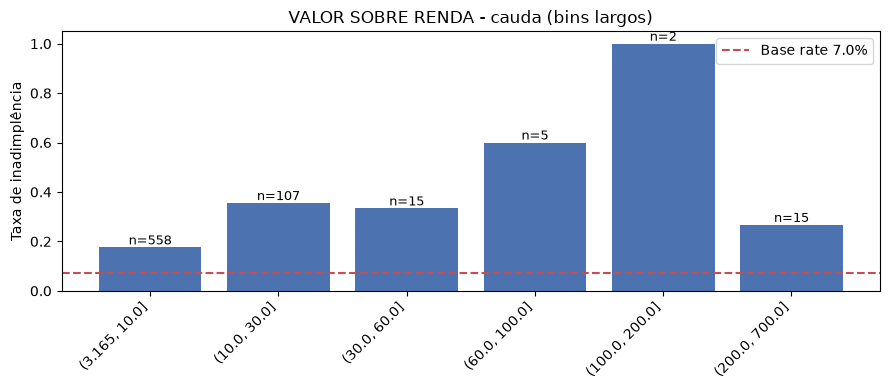

In [106]:
# Último sub-bin (3.165 - 683): faixa larguíssima. Bins manuais e largos para ver
# onde a inadimplência realmente se concentra na cauda, com o n de cada faixa
# (na cauda extrema, poucas cobranças = taxa instável, ler com cuidado).
cauda = df3[df3["VALOR_SOBRE_RENDA"] > 3.165].copy()
bins = [3.165, 10, 30, 60, 100, 200, 700]
cauda["faixa"] = pd.cut(cauda["VALOR_SOBRE_RENDA"], bins)
cb = cauda.groupby("faixa", observed=True)["INADIMPLENTE"].agg(["mean", "size"])
print(cb)
print("\nTotal na cauda:", len(cauda))

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar([str(i) for i in cb.index], cb["mean"], color="#4C72B0")
ax.axhline(base_rate, color="#C44E52", linestyle="--", label=f"Base rate {base_rate:.1%}")
for i, (m, n) in enumerate(zip(cb["mean"], cb["size"])):
    ax.text(i, m, f"n={n}", ha="center", va="bottom", fontsize=9)
ax.set_ylabel("Taxa de inadimplência")
ax.set_title("VALOR SOBRE RENDA - cauda (bins largos)")
ax.legend()
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

                          taxa     n  inadimplentes  %_do_total
faixa                                                          
(-0.000999083, 0.0314]  0.2289  7021           1607        29.6
(0.0314, 0.0554]        0.0619  7022            435         8.0
(0.0554, 0.0805]        0.0490  7020            344         6.3
(0.0805, 0.11]          0.0424  7021            298         5.5
(0.11, 0.149]           0.0420  7021            295         5.4
(0.149, 0.202]          0.0409  7021            287         5.3
(0.202, 0.279]          0.0436  7021            306         5.6
(0.279, 0.41]           0.0457  7021            321         5.9
(0.41, 0.708]           0.0494  7021            347         6.4
(0.708, 683.122]        0.0899  7021            631        11.6
Nulos excluídos: 7204


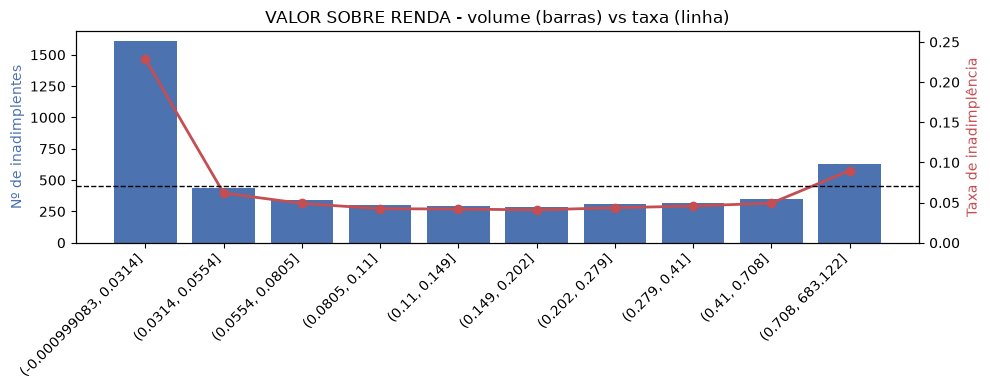

In [107]:
volume_por_faixa("VALOR_SOBRE_RENDA", "VALOR SOBRE RENDA")

## 3.3 Multivariate Analysis

### Numerical

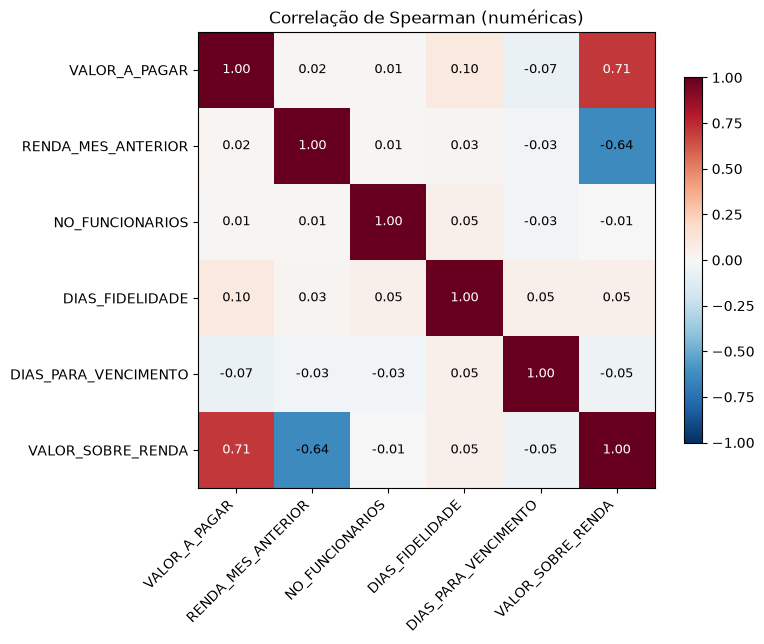

VALOR_A_PAGAR         VALOR_SOBRE_RENDA       0.706471
RENDA_MES_ANTERIOR    VALOR_SOBRE_RENDA       0.639078
VALOR_A_PAGAR         DIAS_FIDELIDADE         0.099238
                      DIAS_PARA_VENCIMENTO    0.070012
DIAS_FIDELIDADE       DIAS_PARA_VENCIMENTO    0.052854
DIAS_PARA_VENCIMENTO  VALOR_SOBRE_RENDA       0.049935
NO_FUNCIONARIOS       DIAS_FIDELIDADE         0.049790
DIAS_FIDELIDADE       VALOR_SOBRE_RENDA       0.047722
RENDA_MES_ANTERIOR    DIAS_PARA_VENCIMENTO    0.030110
NO_FUNCIONARIOS       DIAS_PARA_VENCIMENTO    0.027938
dtype: float64


In [108]:
# Fora: target e DIAS_ATRASO (circulares), ID_CLIENTE(identificador), TAXA/MES/DIA_SEMANA (analisadas como categóricas).
nums = ["VALOR_A_PAGAR", "RENDA_MES_ANTERIOR", "NO_FUNCIONARIOS",
             "DIAS_FIDELIDADE", "DIAS_PARA_VENCIMENTO", "VALOR_SOBRE_RENDA"]

spearman = df3[nums].corr(method="spearman")
heatmap_matriz(spearman, "Correlação de Spearman (numéricas)")
print(pares_mais_associados(spearman))

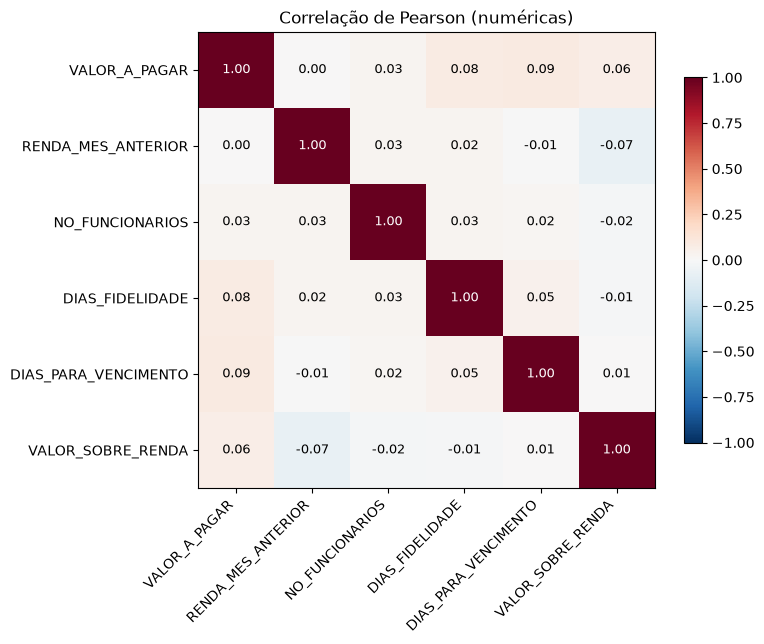

Maior divergência entre os métodos:
VALOR_A_PAGAR         VALOR_SOBRE_RENDA       0.643835
RENDA_MES_ANTERIOR    VALOR_SOBRE_RENDA       0.568498
VALOR_A_PAGAR         DIAS_PARA_VENCIMENTO    0.156854
DIAS_FIDELIDADE       VALOR_SOBRE_RENDA       0.058527
DIAS_PARA_VENCIMENTO  VALOR_SOBRE_RENDA       0.056893
dtype: float64


In [109]:
# Pearson para comparar.
pearson = df3[nums].corr(method="pearson")
heatmap_matriz(pearson, "Correlação de Pearson (numéricas)")

print("Maior divergência entre os métodos:")
dif = (spearman - pearson).abs()
print(pares_mais_associados(dif, 5))

### Categorial

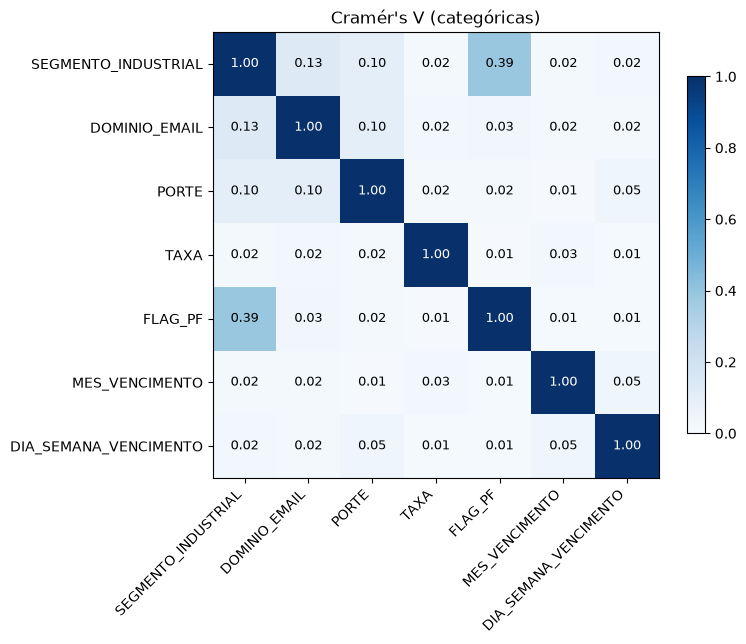

SEGMENTO_INDUSTRIAL  FLAG_PF                  0.390068
                     DOMINIO_EMAIL            0.131914
                     PORTE                    0.099534
DOMINIO_EMAIL        PORTE                    0.096700
MES_VENCIMENTO       DIA_SEMANA_VENCIMENTO    0.045790
PORTE                DIA_SEMANA_VENCIMENTO    0.045207
DOMINIO_EMAIL        FLAG_PF                  0.033991
TAXA                 MES_VENCIMENTO           0.026495
DOMINIO_EMAIL        TAXA                     0.023989
SEGMENTO_INDUSTRIAL  DIA_SEMANA_VENCIMENTO    0.023981
dtype: float64


In [110]:
def cramers_v(x, y):
    tab = pd.crosstab(x, y)
    n = tab.values.sum()
    esperado = np.outer(tab.sum(axis=1), tab.sum(axis=0)) / n
    chi2 = ((tab.values - esperado) ** 2 / esperado).sum()
    r, k = tab.shape
    return np.sqrt(chi2 / (n * min(r - 1, k - 1)))

# SEMANA_VENCIMENTO fica de fora: 53 categorias esparsas.
CATEGORICAS = ["SEGMENTO_INDUSTRIAL", "DOMINIO_EMAIL", "PORTE", "TAXA",
               "FLAG_PF", "MES_VENCIMENTO", "DIA_SEMANA_VENCIMENTO"]

cat = df3[CATEGORICAS].fillna("NULO").astype(str)
V = pd.DataFrame(
    [[cramers_v(cat[a], cat[b]) for b in CATEGORICAS] for a in CATEGORICAS],
    index=CATEGORICAS, columns=CATEGORICAS)
heatmap_matriz(V, "Cramér's V (categóricas)", vmin=0, vmax=1, cmap="Blues")
print(pares_mais_associados(V))

## 3.4 Business Hypothesis

### Dimensão 1 - Capacidade financeira

#### H1.1 Queda de renda antecede inadimplência.

                     taxa     n  inadimplentes  %_do_total
faixa                                                     
(-1.0, -0.776]     0.1082  6635            718        13.2
(-0.776, -0.619]   0.0766  6633            508         9.3
(-0.619, -0.451]   0.0612  6631            406         7.5
(-0.451, -0.242]   0.0522  6631            346         6.4
(-0.242, 0.0121]   0.0615  6634            408         7.5
(0.0121, 0.349]    0.0656  6631            435         8.0
(0.349, 0.814]     0.0592  6636            393         7.2
(0.814, 1.636]     0.0593  6631            393         7.2
(1.636, 3.497]     0.0607  6635            403         7.4
(3.497, 1505.121]  0.0949  6628            629        11.6
Nulos excluídos: 11089


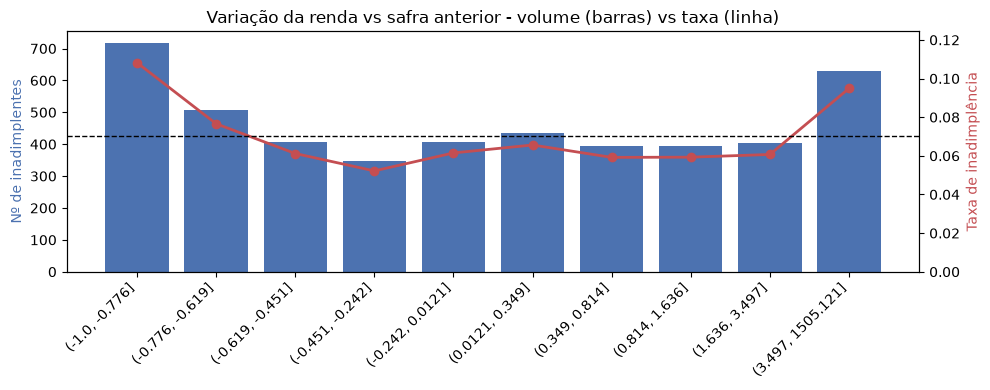

In [111]:
# base_info é mensal: dá para medir a trajetória da renda por cliente.
info = raw_info.sort_values(["ID_CLIENTE", "SAFRA_REF"]).copy()
info["_RENDA_ANT"] = info.groupby("ID_CLIENTE")["RENDA_MES_ANTERIOR"].shift(1)
info["VAR_RENDA"] = (info["RENDA_MES_ANTERIOR"] - info["_RENDA_ANT"]) / info["_RENDA_ANT"]

aux = df3.merge(info[["ID_CLIENTE", "SAFRA_REF", "VAR_RENDA"]],
                on=["ID_CLIENTE", "SAFRA_REF"], how="left")
assert len(aux) == len(df3)
df3["VAR_RENDA"] = aux["VAR_RENDA"].values

volume_por_faixa("VAR_RENDA", "Variação da renda vs safra anterior")

# CONCLUSÃO [PARCIAL]: queda forte de renda (-100% a -78%) dá 10,8%, mas alta forte
# (>350%) dá 9,5%. O que prevê é variação brusca em qualquer direção, não a
# queda especificamente.

### Dimensão 2 - Características da cobrança

#### H2.1 Valores minúsculos são resíduo de pagamento parcial.

In [112]:
# Se forem resíduo, a cobrança pequena deve vir acompanhada de outra(s) MAIORES
# do mesmo cliente na mesma safra.
df3["_N_SAFRA"] = df3.groupby(["ID_CLIENTE", "SAFRA_REF"])["VALOR_A_PAGAR"].transform("size")
df3["_MAX_SAFRA"] = df3.groupby(["ID_CLIENTE", "SAFRA_REF"])["VALOR_A_PAGAR"].transform("max")

peq = df3["VALOR_A_PAGAR"] < 500
print("Cobranças < R$500:", peq.sum())
print("Delas, acompanhadas de outra na mesma safra:", (peq & (df3["_N_SAFRA"] > 1)).sum())
print("\nRazão valor máximo da safra / valor da cobrança (só as pequenas):")
print((df3.loc[peq, "_MAX_SAFRA"] / df3.loc[peq, "VALOR_A_PAGAR"]).describe().round(1))

# CONCLUSÃO [CONFIRMADA]: das 775 cobranças abaixo de R$500, 666 (86%) convivem com
# outra na mesma safra, e a maior cobrança da safra é mediana 118x maior.
# Sustenta a leitura de resíduo de pagamento parcial, a explicação de negócio
# para o achado mais forte de VALOR_A_PAGAR.

Cobranças < R$500: 775
Delas, acompanhadas de outra na mesma safra: 666

Razão valor máximo da safra / valor da cobrança (só as pequenas):
count       775.0
mean       1418.0
std       14880.5
min           1.0
25%          40.9
50%         118.1
75%         253.1
max      274992.2
dtype: float64


#### H2.2 Efeito lote: cobranças do mesmo dia compartilham desfecho.

In [113]:
# Se houver efeito lote, o desfecho dentro do lote é homogêneo.
lote = df3.groupby(["ID_CLIENTE", "DATA_EMISSAO_DOCUMENTO"])["INADIMPLENTE"].agg(["mean", "size"])
lote = lote[lote["size"] > 1]
print("Lotes com mais de uma cobrança:", len(lote))
print("Lotes 100% homogêneos:", ((lote["mean"] == 0) | (lote["mean"] == 1)).mean().round(3))
print("\nDistribuição da taxa dentro do lote:")
print(lote["mean"].value_counts(normalize=True).sort_index().round(3).head(10))

# CONCLUSÃO [CONFIRMADA]: 93% dos 6.738 lotes com mais de uma cobrança têm desfecho
# 100% homogêneo (82,6% inteiramente adimplentes). Além de feature, é problema
# de validação: amostras do mesmo lote são correlacionadas, o que reforça a
# validação out-of-time por safra.

Lotes com mais de uma cobrança: 6738
Lotes 100% homogêneos: 0.93

Distribuição da taxa dentro do lote:
mean
0.000000    0.826
0.200000    0.000
0.250000    0.001
0.285714    0.000
0.333333    0.007
0.400000    0.000
0.500000    0.044
0.600000    0.001
0.625000    0.000
0.666667    0.010
Name: proportion, dtype: float64


### Dimensão 3 - Maturidade do relacionamento

#### H3.1 Cliente que some e volta é mais arriscado.

              taxa      n  inadimplentes  %_do_total
GAP_SAFRAS                                          
1.0         0.0687  70165           4821        88.7
NULO        0.1020   2295            234         4.3
2.0         0.0593   3189            189         3.5
3.0         0.1027    779             80         1.5
4.0         0.0918    305             28         0.5
6.0         0.1953    128             25         0.5
5.0         0.0870    207             18         0.3
8.0         0.1528     72             11         0.2
7.0         0.0886     79              7         0.1
13.0        0.2632     19              5         0.1
9.0         0.1667     30              5         0.1
12.0        0.2105     19              4         0.1
14.0        0.2857      7              2         0.0
10.0        0.0370     27              1         0.0
11.0        0.0345     29              1         0.0
19.0        0.3333      3              1         0.0
15.0        0.1250      8              1      

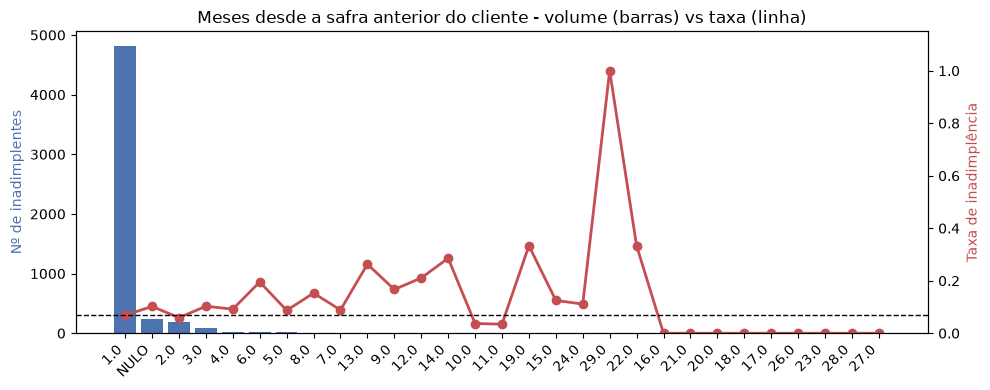

In [114]:
# Intervalo em meses desde a safra anterior COM cobrança do mesmo cliente.
s = df3[["ID_CLIENTE", "SAFRA_REF"]].drop_duplicates().copy()
s["_p"] = pd.PeriodIndex(s["SAFRA_REF"], freq="M")
s["_m"] = s["_p"].dt.year * 12 + s["_p"].dt.month
s = s.sort_values(["ID_CLIENTE", "_m"])
s["GAP_SAFRAS"] = s.groupby("ID_CLIENTE")["_m"].diff()

aux = df3.merge(s[["ID_CLIENTE", "SAFRA_REF", "GAP_SAFRAS"]],
                on=["ID_CLIENTE", "SAFRA_REF"], how="left")
assert len(aux) == len(df3)
df3["GAP_SAFRAS"] = aux["GAP_SAFRAS"].values
volume_por_categoria("GAP_SAFRAS", "Meses desde a safra anterior do cliente")

# CONCLUSÃO [CONFIRMADA, direcional]: gap de 1 safra 6,9%; gap de 3: 10,3%; gap de
# 6: 19,5%; gap de 13: 26,3%. Consistente na direção, com a ressalva de
# volumes pequenos nas caudas.

### Dimensão 4 - Histórico de pagamento

#### Construção das features de histórico (corte anti-vazamento)

In [115]:
# Estado do histórico do cliente na data de emissão de cada cobrança.
# Corte: só cobranças já PAGAS antes da emissão atual (evita vazamento do lote).
esq = (df3.reset_index().rename(columns={"index": "_idx"})
          .sort_values("DATA_EMISSAO_DOCUMENTO"))

dirt = (df3[["ID_CLIENTE", "DATA_PAGAMENTO", "INADIMPLENTE", "DIAS_ATRASO"]]
          .sort_values(["ID_CLIENTE", "DATA_PAGAMENTO"]).copy())
dirt["N_ANTERIORES"] = dirt.groupby("ID_CLIENTE").cumcount() + 1
dirt["TAXA_HIST"] = dirt.groupby("ID_CLIENTE")["INADIMPLENTE"].transform(
    lambda s: s.expanding().mean())
dirt["ATRASO_HIST"] = dirt.groupby("ID_CLIENTE")["DIAS_ATRASO"].transform(
    lambda s: s.expanding().mean())
dirt["ULT_INADIMPLENTE"] = dirt["INADIMPLENTE"]
# kind="stable": ~27% das linhas dividem (cliente, data de pagamento). Um sort
# instável pode deixar por último uma linha do meio do empate, e o merge_asof
# herdaria um histórico parcial daquele dia. Estável garante a linha acumulada.
dirt = dirt.rename(columns={"DATA_PAGAMENTO": "_DT_PAG"}).sort_values("_DT_PAG", kind="stable")

m = pd.merge_asof(
    esq, dirt[["ID_CLIENTE", "_DT_PAG", "N_ANTERIORES", "TAXA_HIST",
               "ATRASO_HIST", "ULT_INADIMPLENTE"]],
    left_on="DATA_EMISSAO_DOCUMENTO", right_on="_DT_PAG",
    by="ID_CLIENTE", direction="backward", allow_exact_matches=False)
m = m.set_index("_idx").sort_index()

for c in ["N_ANTERIORES", "TAXA_HIST", "ATRASO_HIST", "ULT_INADIMPLENTE"]:
    df3[c] = m[c]

print("Cobranças sem histórico anterior:", df3["TAXA_HIST"].isna().sum())

Cobranças sem histórico anterior: 3177


#### H4.1 Cliente que já atrasou tende a atrasar de novo.

                    taxa      n  inadimplentes  %_do_total
ULT_INADIMPLENTE                                          
0.0               0.0506  70797           3579        65.8
1.0               0.4317   3440           1485        27.3
NULO              0.1171   3177            372         6.8


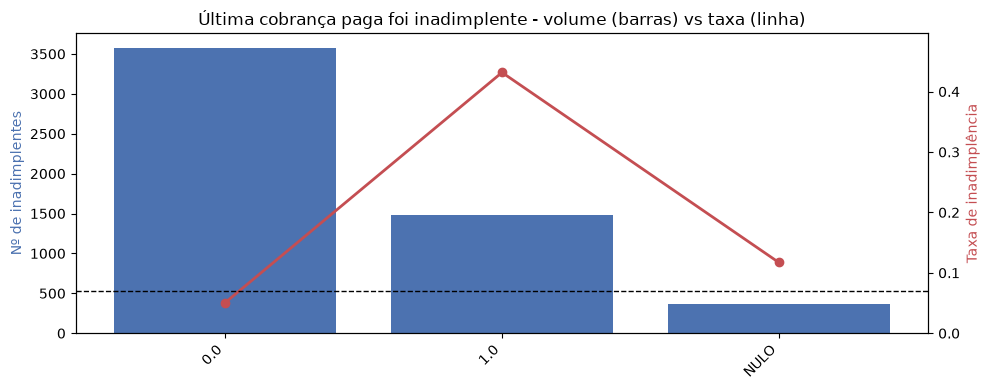

In [116]:
volume_por_categoria("ULT_INADIMPLENTE", "Última cobrança paga foi inadimplente")

# CONCLUSÃO [CONFIRMADA]: quando a última cobrança paga foi inadimplente, a taxa é
# 43,2% contra 5,1% quando foi adimplente (8,5x). Quem já atrasou tende a
# atrasar de novo.

#### H4.2 A taxa histórica de inadimplência do cliente é o preditor mais forte disponível na base.

                     taxa      n  inadimplentes  %_do_total
faixa                                                      
(-0.001, 0.00649]  0.0198  44543            880        16.2
(0.00649, 0.0238]  0.0170   7518            128         2.4
(0.0238, 0.0625]   0.0493   7427            366         6.7
(0.0625, 0.184]    0.1407   7342           1033        19.0
(0.184, 1.0]       0.3587   7407           2657        48.9
Nulos excluídos: 3177


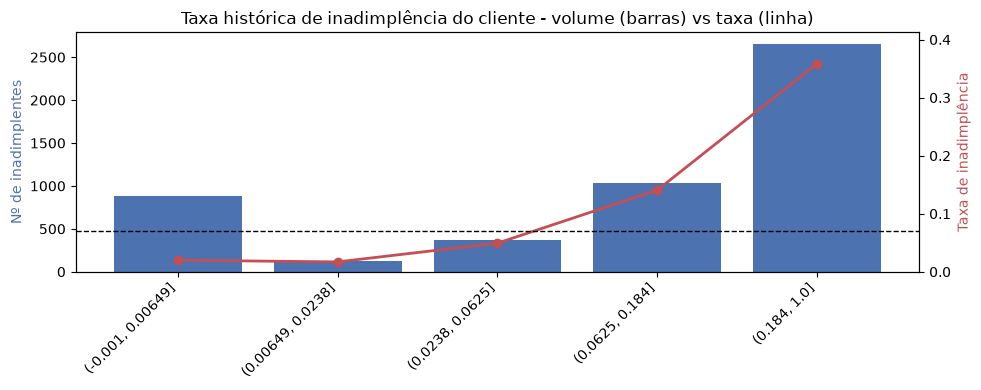

In [117]:
volume_por_faixa("TAXA_HIST", "Taxa histórica de inadimplência do cliente")

# CONCLUSÃO [CONFIRMADA]: TAXA_HIST separa 18x entre a primeira e a última faixa
# (2,0% a 35,9%; contra a faixa de menor taxa, 1,7%, a razão chega a ~21x), e
# o decil superior sozinho carrega 48,9% da inadimplência. É o preditor mais
# forte disponível na base e justifica incorporar as features de histórico.

#### H4.3 Atraso médio passado discrimina melhor que a contagem de atrasos.

                      taxa      n  inadimplentes  %_do_total
faixa                                                       
(-199.633, -0.737]  0.0629   7426            467         8.6
(-0.737, -0.155]    0.0256   7422            190         3.5
(-0.155, -0.0508]   0.0096   7428             71         1.3
(-0.0508, 0.0]      0.0182  19569            357         6.6
(0.0, 0.0305]       0.0089   2697             24         0.4
(0.0305, 0.193]     0.0190   7424            141         2.6
(0.193, 0.708]      0.0460   7428            342         6.3
(0.708, 2.519]      0.1280   7420            950        17.5
(2.519, 216.0]      0.3398   7423           2522        46.4
Nulos excluídos: 3177


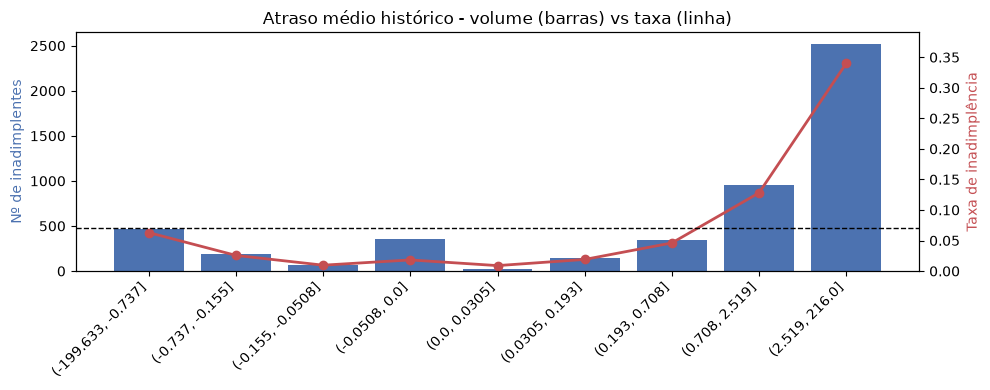

In [118]:
volume_por_faixa("ATRASO_HIST", "Atraso médio histórico")

# CONCLUSÃO [CONFIRMADA]: faixa superior de ATRASO_HIST com 34,0% de taxa e 46,4%
# de toda a inadimplência.

#### H4.4 Atraso recente pesa mais que atraso antigo.

In [119]:
comp = df3.dropna(subset=["TAXA_HIST", "ULT_INADIMPLENTE"])
print("Taxa quando a ÚLTIMA paga foi inadimplente:",
      comp.loc[comp["ULT_INADIMPLENTE"] == 1, "INADIMPLENTE"].mean().round(3))
print("Taxa quando a última foi adimplente:",
      comp.loc[comp["ULT_INADIMPLENTE"] == 0, "INADIMPLENTE"].mean().round(3))
print("\nTaxa por faixa de histórico acumulado:")
print(comp.groupby(pd.qcut(comp["TAXA_HIST"], 5, duplicates="drop"),
                   observed=True)["INADIMPLENTE"].mean().round(3))

# CONCLUSÃO [CONFIRMADA]: última paga inadimplente dá 43,2% contra 5,1% (8,5x),
# enquanto o tercil superior do histórico acumulado chega a 25%. Um único
# evento recente discrimina mais que a média de toda a vida do cliente:
# recência importa mais que frequência.

Taxa quando a ÚLTIMA paga foi inadimplente: 0.432
Taxa quando a última foi adimplente: 0.051

Taxa por faixa de histórico acumulado:
TAXA_HIST
(-0.001, 0.00649]    0.020
(0.00649, 0.0625]    0.033
(0.0625, 1.0]        0.250
Name: INADIMPLENTE, dtype: float64


#### H4.5 Cliente sem histórico (cold start) tem risco diferente da base geral.

                 taxa      n  inadimplentes  %_do_total
SEM_HISTORICO                                          
0              0.0682  74237           5064        93.2
1              0.1171   3177            372         6.8


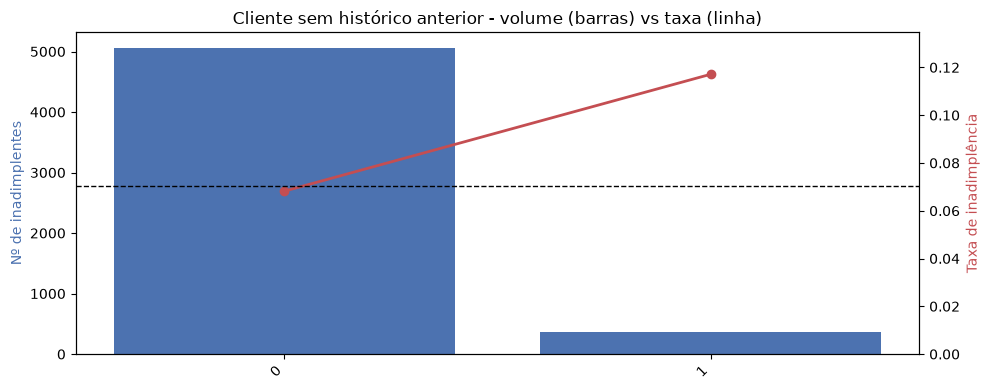

In [120]:
df3["SEM_HISTORICO"] = df3["TAXA_HIST"].isna().astype(int)
volume_por_categoria("SEM_HISTORICO", "Cliente sem histórico anterior")

# CONCLUSÃO [CONFIRMADA]: sem histórico 11,7% contra 6,8% com histórico. Cold start
# difere da base geral; na modelagem, preencher com base rate, não com 0.

#### H4.6 Poucas cobranças anteriores tornam a taxa histórica instável e pouco confiável.

In [121]:
# A taxa histórica é confiável com poucas cobranças anteriores?
com = df3.dropna(subset=["TAXA_HIST"])
print(com.groupby(pd.cut(com["N_ANTERIORES"], [0, 1, 3, 10, 30, 9999]),
                  observed=True)["INADIMPLENTE"].agg(["mean", "size"]).round(3))

# CONCLUSÃO [CONFIRMADA]: 1 cobrança anterior: 10,2%; 3 a 10: 6,0%; acima de 30:
# 6,8%. Histórico curto torna a taxa histórica instável e pouco confiável.

               mean   size
N_ANTERIORES              
(0, 1]        0.102   1302
(1, 3]        0.087   2068
(3, 10]       0.060   5998
(10, 30]      0.065  13421
(30, 9999]    0.068  51448


### Dimensão 5 - Exposição e concentração

#### H5.1 O valor total devido pelo cliente na safra prevê melhor que o valor da cobrança isolada.

                                   taxa     n  inadimplentes  %_do_total
faixa                                                                   
(11.219000000000001, 48679.375]  0.1271  7733            983        18.1
(48679.375, 79985.0]             0.0656  7734            507         9.3
(79985.0, 111049.11]             0.0634  7733            490         9.0
(111049.11, 146652.07]           0.0513  7732            397         7.3
(146652.07, 189354.11]           0.0518  7736            401         7.4
(189354.11, 241155.45]           0.0550  7731            425         7.8
(241155.45, 325527.659]          0.0598  7730            462         8.5
(325527.659, 452809.85]          0.0583  7735            451         8.3
(452809.85, 821597.25]           0.0667  7739            516         9.5
(821597.25, 6676694.97]          0.1025  7725            792        14.6
Nulos excluídos: 86


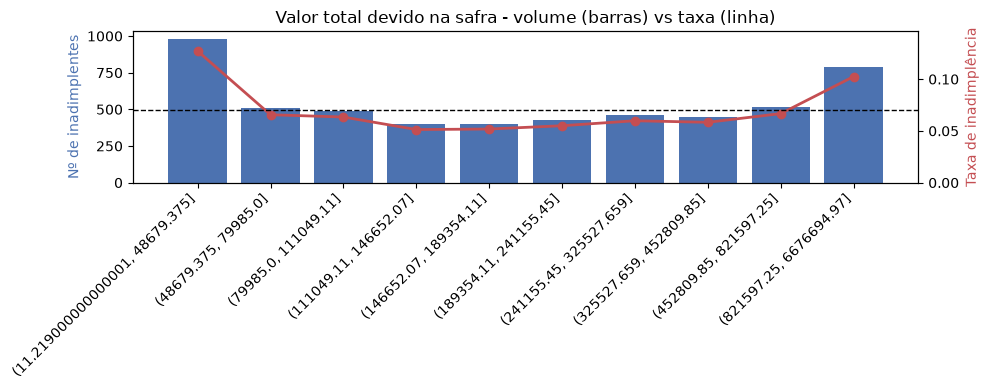

In [122]:
df3['VALOR_TOTAL_SAFRA'] = df3.groupby(['ID_CLIENTE', 'SAFRA_REF'])['VALOR_A_PAGAR'] \
                              .transform('sum', min_count=1)

volume_por_faixa("VALOR_TOTAL_SAFRA", "Valor total devido na safra")

# CONCLUSÃO [PARCIAL, formato em U]: menor total devido na safra dá 12,7%; meio
# 5,2%; maior total 10,2%.

#### H5.2 Cobrança pequena dentro de um lote grande é despriorizada pelo cliente.

                          taxa     n  inadimplentes  %_do_total
faixa                                                          
(-0.000999652, 0.0377]  0.2463  7625           1878        34.5
(0.0377, 0.0727]        0.0843  7624            643        11.8
(0.0727, 0.108]         0.0611  7624            466         8.6
(0.108, 0.144]          0.0509  7625            388         7.1
(0.144, 0.187]          0.0401  7624            306         5.6
(0.187, 0.24]           0.0370  7624            282         5.2
(0.24, 0.313]           0.0359  7625            274         5.0
(0.313, 0.421]          0.0355  7624            271         5.0
(0.421, 0.648]          0.0426  7624            325         6.0
(0.648, 1.0]            0.0647  7625            493         9.1
Nulos excluídos: 1170


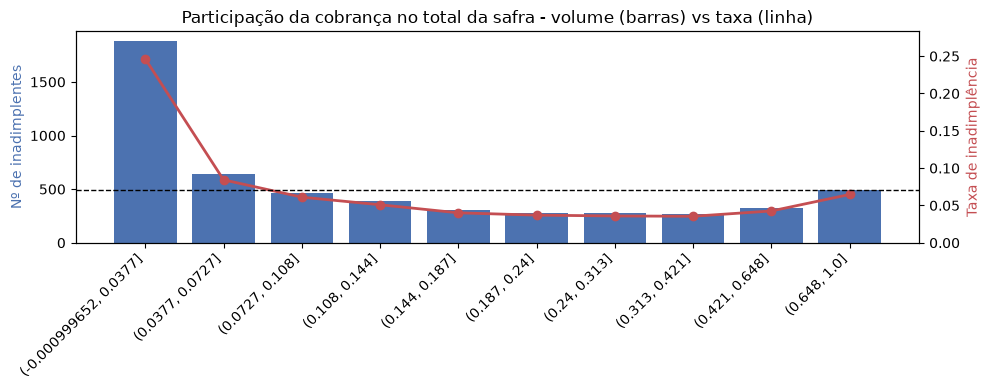

           mean  size
_N_SAFRA             
False     0.466   232
True      0.469  1747


In [123]:
# Hipótese mais promissora: explicaria o achado de valor baixo.
# Depende de _N_SAFRA, criada em H2.1.
df3["SHARE_NA_SAFRA"] = df3["VALOR_A_PAGAR"] / df3["VALOR_TOTAL_SAFRA"]
volume_por_faixa("SHARE_NA_SAFRA", "Participação da cobrança no total da safra")

# Isola o efeito: entre cobranças pequenas, importa estar ou não em lote grande?
peq = df3["VALOR_A_PAGAR"] < 1000
print(df3[peq].groupby(df3.loc[peq, "_N_SAFRA"] > 1)["INADIMPLENTE"]
      .agg(["mean", "size"]).round(3))

# CONCLUSÃO [PARCIAL]: feature confirmada, mecanismo refutado. SHARE_NA_SAFRA na
# faixa mais baixa dá 24,6% com 34,5% da inadimplência; mas entre cobranças
# abaixo de R$1.000, estar sozinha (46,6%) ou em lote (46,9%) não muda nada.
# O que pesa é o tamanho relativo, não a existência do lote.

#### H5.3 Clientes que concentram muitas cobranças respondem por parcela desproporcional da inadimplência.

In [124]:
por_cliente = (df3.groupby("ID_CLIENTE")["INADIMPLENTE"].agg(["sum", "size"])
                 .sort_values("sum", ascending=False))
acum = por_cliente["sum"].cumsum() / TOTAL_INAD
for p in [0.05, 0.10, 0.20, 0.50]:
    k = int(len(por_cliente) * p)
    print(f"{p:.0%} dos clientes concentram {acum.iloc[k-1]:.1%} da inadimplência")

# CONCLUSÃO [CONFIRMADA]: 5% dos clientes cobrem 63,2% da inadimplência; 20% cobrem
# 89,5%. É a resposta direta à pergunta operacional do case.

5% dos clientes concentram 63.2% da inadimplência
10% dos clientes concentram 77.2% da inadimplência
20% dos clientes concentram 89.5% da inadimplência
50% dos clientes concentram 100.0% da inadimplência


### Dimensão 6 - Sazonalidade e tempo

#### H6.1 O "efeito março" é a safra 2020-03 vazando para dentro da feature de mês.

In [125]:
# Se março só for ruim em 2020, o efeito é a safra vazando, não sazonalidade.
df3["_ANO"] = df3["DATA_VENCIMENTO"].dt.year

marco = df3["MES_VENCIMENTO"] == 3
print("Taxa de março excluindo 2020:",
      df3[marco & (df3["_ANO"] != 2020)]["INADIMPLENTE"].mean().round(3))
print("Taxa de março só em 2020:",
      df3[marco & (df3["_ANO"] == 2020)]["INADIMPLENTE"].mean().round(3))
print("Base rate geral:", round(base_rate, 3))

# CONCLUSÃO [CONFIRMADA]: março excluindo 2020 dá 7,3%, a própria base rate; março
# só em 2020 dá 19,0%. A feature de mês lia a safra 2020-03, não sazonalidade.
# Consequência: MES_VENCIMENTO deve sair do modelo ou ser tratada
# explicitamente.

Taxa de março excluindo 2020: 0.073
Taxa de março só em 2020: 0.19
Base rate geral: 0.07


### Dimensão 7 - Geografia

#### H7.1 Existe concentração regional de inadimplência.

In [126]:
# CEP_2_DIG e DDD foram descartados em 2.5; recuperar da base cadastral.
geo = df3.merge(raw_cadastral[["ID_CLIENTE", "CEP_2_DIG", "DDD"]], on="ID_CLIENTE", how="left")
assert len(geo) == len(df3)
df3["CEP_2_DIG"] = geo["CEP_2_DIG"].values
df3["DDD"] = geo["DDD"].values

# Só faixas com volume relevante, para não ler ruído.
print(df3.groupby("CEP_2_DIG")["INADIMPLENTE"].agg(["mean", "size"])
        .query("size >= 200").sort_values("mean", ascending=False).head(10).round(3))

# CONCLUSÃO [CONFIRMADA]: concentração regional real. CEP 48: 32,1%; CEP 70: 29,7%;
# CEP 33: 25,4%, contra base rate de 7,0%.

            mean  size
CEP_2_DIG             
48         0.321   598
70         0.297   676
33         0.254   224
65         0.220  1316
67         0.209   665
26         0.172   616
78         0.172  2067
17         0.170   751
12         0.167  2076
55         0.161  1146


#### H7.2 Agrupar CEP em macrorregiões resolve a esparsidade das 90 categorias originais.

          taxa      n  inadimplentes  %_do_total
REGIAO                                          
6.0     0.1133   8473            960        17.7
7.0     0.1097   8285            909        16.7
1.0     0.0706  12444            878        16.2
3.0     0.0543  11830            642        11.8
4.0     0.0949   6051            574        10.6
2.0     0.0570   7877            449         8.3
8.0     0.0329  12792            421         7.7
5.0     0.1116   3307            369         6.8
9.0     0.0358   6347            227         4.2
NULO    0.8750      8              7         0.1


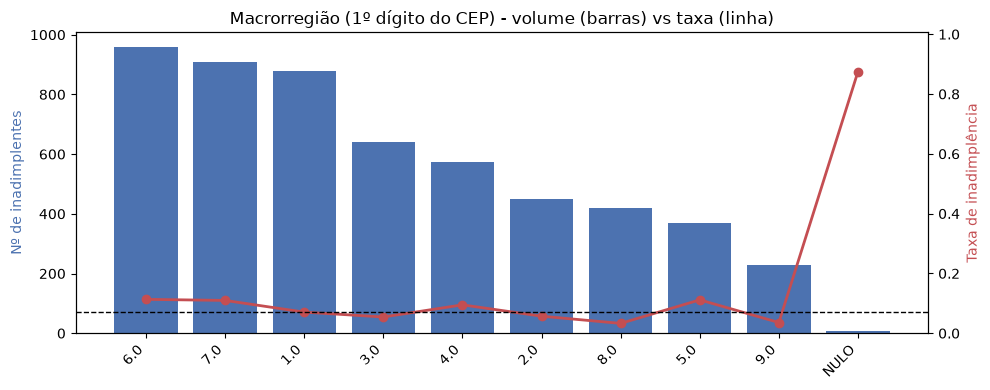

In [127]:
df3["REGIAO"] = pd.to_numeric(df3["CEP_2_DIG"], errors="coerce") // 10
volume_por_categoria("REGIAO", "Macrorregião (1º dígito do CEP)")

# CONCLUSÃO [CONFIRMADA]: 9 macrorregiões com volume alto em todas, espalhamento de
# 3,3% (região 8) a 11,3% (região 6), ~3,4x. Resolve a esparsidade das 90
# categorias e justifica reverter o descarte de CEP_2_DIG na forma agrupada.

#### H7.3 DDD e CEP carregam a mesma informação geográfica.

In [128]:
print("Cramér's V CEP x DDD:",
      round(cramers_v(df3["CEP_2_DIG"].fillna("NULO").astype(str),
                      df3["DDD"].fillna("NULO").astype(str)), 3))

# CONCLUSÃO [REFUTADA]: Cramér's V CEP x DDD = 0,635. Relacionados, mas não
# intercambiáveis; não carregam a mesma informação.

Cramér's V CEP x DDD: 0.635


### Dimensão 8 - Qualidade do cadastro

#### H8.1 A contagem de campos nulos por cobrança prevê melhor que qualquer campo nulo isolado.

           taxa      n  inadimplentes  %_do_total
N_NULOS                                          
0        0.0655  62732           4106        75.5
1        0.0922  10069            928        17.1
2        0.0822   4235            348         6.4
3        0.1456    371             54         1.0
4        0.0000      7              0         0.0


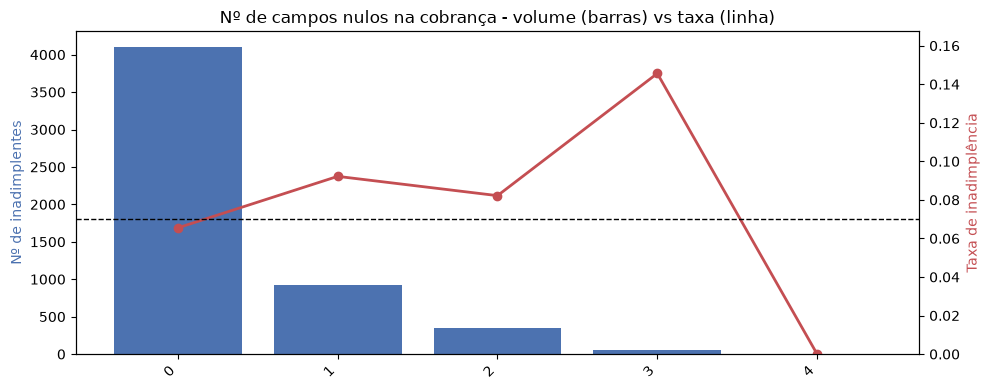

In [129]:
CAMPOS = ["PORTE", "SEGMENTO_INDUSTRIAL", "DOMINIO_EMAIL",
          "RENDA_MES_ANTERIOR", "NO_FUNCIONARIOS", "VALOR_A_PAGAR"]
df3["N_NULOS"] = df3[CAMPOS].isna().sum(axis=1)
volume_por_categoria("N_NULOS", "Nº de campos nulos na cobrança")

# CONCLUSÃO [CONFIRMADA, efeito modesto]: 0 nulos 6,6%; 1: 9,2%; 2: 8,2%; 3: 14,6%
# (4 nulos: 0%, mas n=7). Tendência crescente, não estritamente monotônica: a
# faixa de dois nulos recua.

### Dimensão 9 - Anomalias operacionais

#### H9.1 Cobrança emitida antes do cadastro do cliente é erro de registro, sem sinal de risco.

In [130]:
df3["FIDELIDADE_NEG"] = (df3["DIAS_FIDELIDADE"] < 0).astype(int)
print(df3.groupby("FIDELIDADE_NEG")["INADIMPLENTE"].agg(["mean", "size"]).round(3))

# CONCLUSÃO [REFUTADA]: as 40 cobranças emitidas antes do cadastro têm 40% de
# inadimplência contra 7% da base. Não é ruído de registro, é marcador de
# risco.

                mean   size
FIDELIDADE_NEG             
0               0.07  77374
1               0.40     40


#### H9.2 Cliente com alguma cobrança reemitida apresenta risco elevado também nas demais cobranças.

In [131]:
# Exclui as próprias reemissões, senão a hipótese se autoconfirma.
clientes_reemissao = df3.loc[df3["DIAS_PARA_VENCIMENTO"] < 0, "ID_CLIENTE"].unique()
outras = df3[df3["DIAS_PARA_VENCIMENTO"] >= 0].copy()
outras["_marcado"] = outras["ID_CLIENTE"].isin(clientes_reemissao)
print(outras.groupby("_marcado")["INADIMPLENTE"].agg(["mean", "size"]).round(3))

# CONCLUSÃO [CONFIRMADA]: excluindo as próprias reemissões, as demais cobranças
# desses clientes têm 36,0% contra 6,4% (5,6x). A reemissão marca o cliente,
# não só a cobrança.

           mean   size
_marcado              
False     0.064  75722
True      0.360   1665


## Findings

#### **Univariada**

- **Target desbalanceado:** 7,02% de inadimplência. 

- **Contínuas assimétricas:** `VALOR_A_PAGAR`, `RENDA_MES_ANTERIOR` e
  `VALOR_SOBRE_RENDA` têm cauda longa à direita. 

- **`TAXA` pode ser categórica:** float, mas só 5 valores.

- **Anomalias:** `DATA_VENCIMENTO` até 2027-03, `DATA_PAGAMENTO` antes da 1ª
  emissão, `DIAS_FIDELIDADE` mín -13, `DIAS_PARA_VENCIMENTO` negativo
  (reemissão). Investigadas depois: os vencimentos distantes têm valores altos e
  redondos (R$250.000, R$150.000), parecem crédito de longo prazo legítimo, não
  erro; e a fidelidade negativa tem 40% de inadimplência, ou seja, é marcador de
  risco, não ruído.

- **`NO_FUNCIONARIOS` suspeita:** distribuição concentrada demais (mediana 118,
  std 18,8, máx 198) e 10% nulos. Pode ser dado sintético/pré-tratado.

#### **Bivariada**

- **`SAFRA_REF`:** pico de taxa e casos de inadimplência entre 12-2019 e 03-2020, possivelmente causado pela pandemia.

- **Features mais representativas:**
  - `VALOR_A_PAGAR`: cobranças abaixo de R$100 chegam a 94% de inadimplência; o
    1º decil concentra 42,5% do problema. A mais forte da base.
    
  - `DIAS_PARA_VENCIMENTO`: gradiente limpo de 3,5% (0-20 dias) a 31% (40-90
    dias). Janela longa não é folga, é prazo esticado/renegociação. Os 27
    negativos chegam a 96%, mas são irrisórios em volume.
    
  - `VALOR_SOBRE_RENDA`: formato em U (22,9% no 1º decil, 9,0% no último). O
    extremo baixo herda o efeito de valor pequeno, não é fenômeno próprio.
    
  - `RENDA_MES_ANTERIOR`: abaixo de R$13.845 a taxa é 38,9%.
    Renda **ausente** fica na média (7,6%), ou seja, não é sinal.
    
  - `PORTE`: gradiente ordinal (GRANDE 5,5% < MEDIO 6,5% < PEQUENO 9,2%) e
    **NULO 17,5%**, o mais arriscado, com 8% da inadimplência total.
    
  - `SEGMENTO_INDUSTRIAL`: Serviços 8,8% contra Comércio 4,6%.
    
  - `DIA_SEMANA_VENCIMENTO`: fim de semana 3x a taxa dos dias úteis, mas só
    1,1% da inadimplência.
    
  - `NO_FUNCIONARIOS`: formato em U (0-94 dá 10,1%, meio ~5,4%, 141-198 dá
    8,6%), não a queda monotônica esperada.
    
  - `DOMINIO_EMAIL`: mais informativo que o esperado, de 3,9% (AOL) a 9,3%
    (HOTMAIL), razão de 2,4x.
 
  - `FLAG_PF`: pessoa física tem 20,1% contra 7,0% de pessoa jurídica, mas são
    só 219 cobranças (0,8% da inadimplência). Sinal real, porém sem tamanho.

- **Features fracas:** `TAXA` (6,4% a 7,6%, quase plana: a precificação atual não
  captura risco de atraso) e `DIAS_FIDELIDADE` (4,0% a 10,2%).

- **Taxa ≠ volume:** os segmentos de maior taxa são minúsculos. A faixa de menor
  taxa de `DIAS_PARA_VENCIMENTO` (3,5%) carrega 31,5% da inadimplência, e a de
  maior taxa (96,3%) carrega 0,5%. `FLAG_PF` tem 20,1% de taxa e 0,8% do volume.

#### **Multivariada**

- **Multicolinearidade baixa:** fora as correlações estruturais de
  `VALOR_SOBRE_RENDA` com seus componentes (0,71 e -0,64), nenhum par de
  numéricas passa de 0,10. Nenhuma associação categórica passa de 0,39
  (`SEGMENTO_INDUSTRIAL` x `FLAG_PF`).

- **Redundâncias:** `MES` x `SEMANA` de vencimento (V = 0,953, praticamente a
  mesma informação), `FLAG_PF` x `NO_FUNCIONARIOS == 0` (V = 0,819; zero é
  codificação de pessoa física) e sobreposição de 46% (Jaccard) entre os 1ºs
  decis de `VALOR_A_PAGAR` e `VALOR_SOBRE_RENDA`.

#### **Hipóteses de negócio**

- **Histórico de pagamento importa:** `TAXA_HIST` separa 18x (2,0% a 35,9%) e
  seu decil superior carrega 48,9% da inadimplência. A última cobrança paga
  separa 8,5x (5,1% vs 43,2%): recência pesa mais que o acumulado.

- **Inadimplência concentrada:** 20% dos clientes cobrem 89,5% do problema.

- **Efeito lote:** 93% dos lotes emitidos no mesmo dia têm desfecho homogêneo. As
  cobranças não são independentes.

- **`MES_VENCIMENTO` está contaminada:** março sem 2020 dá 7,3% (a média);
  março só em 2020 dá 19,0%. A feature lia uma safra, não sazonalidade.

- **Geografia tem sinal:** agrupado em 9 macrorregiões, o CEP
  separa de 3,3% a 11,3% com volume alto em todas as faixas.

- **Reemissão marca o cliente:** excluindo as próprias reemissões, as demais
  cobranças desses clientes têm 36,0% contra 6,4%.

# 4 Data Preparation

In [132]:
df4=df3.copy()

In [133]:
df4.columns
df4.shape

(77414, 38)

## 4.1 Drop Columns

In [134]:
# Temporárias da EDA (prefixo _), sem valor fora da seção 3.
drop_eda_temp = ['_N_SAFRA', '_MAX_SAFRA', '_ANO']

# Descartadas por decisão da EDA:
# MES_VENCIMENTO      
# SEMANA_VENCIMENTO   
# DDD                 
# CEP_2_DIG           90 categorias esparsas; entra agrupado em REGIAO 
drop_refutadas = ['MES_VENCIMENTO', 'SEMANA_VENCIMENTO', 'DDD', 'CEP_2_DIG']

drop = drop_eda_temp + drop_refutadas
assert not (set(drop) - set(df4.columns)), f'não existe: {set(drop) - set(df4.columns)}'

df4 = df4.drop(columns=drop)
print(f'{len(drop)} colunas descartadas, restam {df4.shape[1]}')
df4.columns.tolist()

7 colunas descartadas, restam 31


['ID_CLIENTE',
 'SAFRA_REF',
 'DATA_EMISSAO_DOCUMENTO',
 'DATA_PAGAMENTO',
 'DATA_VENCIMENTO',
 'VALOR_A_PAGAR',
 'TAXA',
 'FLAG_PF',
 'SEGMENTO_INDUSTRIAL',
 'DOMINIO_EMAIL',
 'PORTE',
 'RENDA_MES_ANTERIOR',
 'NO_FUNCIONARIOS',
 'DIA_SEMANA_VENCIMENTO',
 'DIAS_FIDELIDADE',
 'DIAS_PARA_VENCIMENTO',
 'VALOR_SOBRE_RENDA',
 'DIAS_ATRASO',
 'INADIMPLENTE',
 'VAR_RENDA',
 'GAP_SAFRAS',
 'N_ANTERIORES',
 'TAXA_HIST',
 'ATRASO_HIST',
 'ULT_INADIMPLENTE',
 'SEM_HISTORICO',
 'VALOR_TOTAL_SAFRA',
 'SHARE_NA_SAFRA',
 'REGIAO',
 'N_NULOS',
 'FIDELIDADE_NEG']

## 4.2 Historical Features Creation

In [135]:
# ---------------------------------------------------------------------------
# 1. TAXA_HIST_SUAVE: encolhimento em direção à base rate (H4.6 + H4.5)
# ---------------------------------------------------------------------------
k_suavizacao = 5   # peso do prior, em "cobranças fictícias".

assert (df4['TAXA_HIST'].isna() == df4['N_ANTERIORES'].isna()).all(), \
    'TAXA_HIST e N_ANTERIORES nulas em linhas diferentes: fillna(0) deixa de ser seguro'

def suavizar(taxa, n, base=base_rate, k=k_suavizacao):
    """Média ponderada entre a taxa do cliente (peso n) e a base rate (peso k).

    taxa * n é o número de inadimplências observadas, então o numerador é
    "inadimplências reais + inadimplências fictícias" e o denominador é
    "cobranças reais + cobranças fictícias". Com n = 0 devolve a base rate.
    """
    n = n.fillna(0)
    return (taxa.fillna(0) * n + base * k) / (n + k)

# Nulo em N_ANTERIORES significa "nenhuma cobrança anterior", não dado ausente: cold start.
df4['N_ANTERIORES']    = df4['N_ANTERIORES'].fillna(0)
df4['TAXA_HIST_SUAVE'] = suavizar(df4['TAXA_HIST'], df4['N_ANTERIORES'])

# Demonstração do mecanismo
demo = pd.DataFrame({'N_ANTERIORES': [0, 1, 1, 3, 20, 100],
                     'TAXA_HIST':    [np.nan, 1.0, 0.0, 1/3, 0.5, 0.5]})
demo['TAXA_HIST_SUAVE'] = suavizar(demo['TAXA_HIST'], demo['N_ANTERIORES'])
print(f'base rate: {base_rate:.4f} | k = {k_suavizacao}')
print(demo.round(4).to_string(index=False))

# O caso que motiva tudo: taxa de 100% apoiada em uma única cobrança.
uma_so = (df4['TAXA_HIST'] == 1.0) & (df4['N_ANTERIORES'] == 1)
print(f'\ncobranças com TAXA_HIST = 1,00 e apenas 1 anterior: {uma_so.sum()}')
print(f'  suavizadas para: {df4.loc[uma_so, "TAXA_HIST_SUAVE"].iloc[0]:.4f}')

# ---------------------------------------------------------------------------
# 2. GAP_SAFRAS: capping da cauda (H3.1)
# ---------------------------------------------------------------------------
# H3.1 confirmou a direção (gap de 1 safra: 6,9%; de 3: 10,3%; de 6: 19,5%; de
# 13: 26,3%), mas o volume seca rápido: 70.165 cobranças têm gap 1 e só 346
# (0,45%) têm gap acima de 6, espalhadas até 29. Sem capping, o modelo criaria
# splits sobre dezenas de observações e leria ruído como gradiente.
#
# clip(upper=6) achata tudo acima de 6 em 6. Não descarta linha nenhuma: apenas
# transforma "sumiu por 13 safras" em "sumiu por 6 ou mais", que é toda a
# informação que o volume sustenta.
#
# Os 2.295 nulos são primeira aparição do cliente, e continuam nulos de
# propósito: "nunca apareceu antes" não é "voltou depois de 0 meses". A árvore
# trata o nulo como caminho próprio, que é o comportamento certo aqui.
df4['GAP_SAFRAS'] = df4['GAP_SAFRAS'].clip(upper=6)

# ---------------------------------------------------------------------------
# 3. VAR_RENDA_ABS: o sinal está no módulo (H1.1)
# ---------------------------------------------------------------------------
# H1.1 foi testada como "queda de renda antecede inadimplência" e voltou
# PARCIAL: queda forte (-100% a -78%) dá 10,8%, mas alta forte (>350%) dá 9,5%.
# Os dois extremos são arriscados, o meio não. Ou seja, o que prevê é
# INSTABILIDADE, não direção. Uma empresa cujo faturamento declarado quadruplica
# de um mês para o outro é tão suspeita quanto uma que despenca.
#
# Em VAR_RENDA crua esse sinal tem formato de U, e o modelo precisaria de dois
# cortes para capturá-lo. O módulo dobra a distribuição no zero e transforma o U
# em uma relação monotônica: um corte só resolve.
#
# Os 14,3% de nulos vêm da primeira safra de cada cliente na base_info (não há
# mês anterior para comparar). Mantidos nulos: não existe variação, não é zero.
df4['VAR_RENDA_ABS'] = df4['VAR_RENDA'].abs()

# ---------------------------------------------------------------------------
# 4. Descarte das versões cruas
# ---------------------------------------------------------------------------
# TAXA_HIST: TAXA_HIST_SUAVE carrega a mesma informação já corrigida, e
#   N_ANTERIORES fica no modelo para o algoritmo saber quanta evidência existe
#   por trás de cada valor. Manter as duas versões da taxa seria redundância
#   quase perfeita, e a crua é a pior das duas.
# VAR_RENDA: substituída pelo módulo, pelo motivo do bloco 3.
df4 = df4.drop(columns=['TAXA_HIST', 'VAR_RENDA'])

print(f'\ndf4: {df4.shape[0]} cobranças, {df4.shape[1]} colunas')

base rate: 0.0702 | k = 5
 N_ANTERIORES  TAXA_HIST  TAXA_HIST_SUAVE
            0        NaN           0.0702
            1     1.0000           0.2252
            1     0.0000           0.0585
            3     0.3333           0.1689
           20     0.5000           0.4140
          100     0.5000           0.4795

cobranças com TAXA_HIST = 1,00 e apenas 1 anterior: 95
  suavizadas para: 0.2252

df4: 77414 cobranças, 31 colunas


## 4.3 Test Preparation

In [136]:
# ===========================================================================
# 1. JOINS 
# ===========================================================================
# Pagamentos é a tabela fato; cadastral e info são dimensões que entram por
# LEFT join. 'left' e não 'inner' de propósito: cliente sem cadastro tem que
# sobreviver com nulo, porque a submissão exige uma linha por cobrança do teste.
# São 38 cobranças de clientes ausentes da base cadastral.
#
# Os asserts checam CARDINALIDADE, não conteúdo. Se a chave da direita não for
# única, o merge multiplica linhas em silêncio e a submissão sai com o número
# errado de linhas.
df4_test = raw_pag_teste.merge(raw_cadastral, how='left', on='ID_CLIENTE')
assert len(df4_test) == len(raw_pag_teste), 'join cadastral duplicou linhas'

df4_test = df4_test.merge(raw_info, how='left', on=['ID_CLIENTE', 'SAFRA_REF'])
assert len(df4_test) == len(raw_pag_teste), 'join info duplicou linhas'

# O merge sempre devolve índice novo 0..n-1. O merge_asof lá embaixo depende
# disso para devolver as linhas à ordem original, então confirmar.
assert df4_test.index.equals(pd.RangeIndex(len(df4_test))), 'índice não é 0..n-1'

# ===========================================================================
# 2. DTYPES 
# ===========================================================================
# format explícito
for c in ['DATA_EMISSAO_DOCUMENTO', 'DATA_VENCIMENTO', 'DATA_CADASTRO']:
    df4_test[c] = pd.to_datetime(df4_test[c], format='%Y-%m-%d')

# ===========================================================================
# 3. FEATURES 
# ===========================================================================
df4_test['DIA_SEMANA_VENCIMENTO'] = df4_test['DATA_VENCIMENTO'].dt.dayofweek
df4_test['DIAS_FIDELIDADE']       = (df4_test['DATA_EMISSAO_DOCUMENTO'] - df4_test['DATA_CADASTRO']).dt.days
df4_test['DIAS_PARA_VENCIMENTO']  = (df4_test['DATA_VENCIMENTO'] - df4_test['DATA_EMISSAO_DOCUMENTO']).dt.days
df4_test['VALOR_SOBRE_RENDA']     = df4_test['VALOR_A_PAGAR'] / df4_test['RENDA_MES_ANTERIOR']

# notna() e não fillna(): em FLAG_PF o vazio SIGNIFICA pessoa jurídica, não é dado faltante 
df4_test['FLAG_PF'] = df4_test['FLAG_PF'].notna().astype(int)

# ===========================================================================
# 4. AGREGADOS DENTRO DA SAFRA (H5.1, H5.2, H7.2, H8.1, H9.1)
# ===========================================================================
# transform devolve uma Series do TAMANHO DO DATAFRAME, com o valor do grupo repetido em cada linha dele. agg devolveria uma linha
# por grupo e exigiria um merge de volta.
#
# min_count=1 é o conserto do bug do total zerado: sum() de um grupo
# inteiramente nulo devolve 0.0, e "total da safra = R$0" seria lido como
# cliente que não deve nada, quando a verdade é que o valor é desconhecido.
df4_test['VALOR_TOTAL_SAFRA'] = df4_test.groupby(['ID_CLIENTE', 'SAFRA_REF'])['VALOR_A_PAGAR'] \
                                        .transform('sum', min_count=1)
df4_test['SHARE_NA_SAFRA']    = df4_test['VALOR_A_PAGAR'] / df4_test['VALOR_TOTAL_SAFRA']

# H7.2: os 2 primeiros dígitos do CEP dão 90 categorias, esparsas demais para
# base rate de 7%. O // 10 (divisão inteira) descarta o segundo dígito e agrupa
# em 9 macrorregiões, todas com volume alto. errors='coerce' manda CEP
# malformado para nulo em vez de derrubar a célula: são 39 cobranças.
df4_test['REGIAO'] = pd.to_numeric(df4_test['CEP_2_DIG'], errors='coerce') // 10

# H8.1: índice de completude do cadastro.
campos_nulos = ['PORTE', 'SEGMENTO_INDUSTRIAL', 'DOMINIO_EMAIL',
                'RENDA_MES_ANTERIOR', 'NO_FUNCIONARIOS', 'VALOR_A_PAGAR']
df4_test['N_NULOS'] = df4_test[campos_nulos].isna().sum(axis=1)

# H9.1: cobrança emitida antes do cadastro do cliente.
df4_test['FIDELIDADE_NEG'] = (df4_test['DIAS_FIDELIDADE'] < 0).astype(int)

# ===========================================================================
# 5. VARIAÇÃO DE RENDA (H1.1)
# ===========================================================================
# A variação é calculada na base_info, não no df4_test, e o motivo importa:
# base_info tem uma linha por (cliente, mês) inclusive nos meses SEM cobrança.
# Calcular o shift no df4_test compararia com a safra anterior em que o cliente
# teve cobrança, que pode estar 6 meses atrás. Aqui queremos o mês anterior.
info = raw_info.sort_values(['ID_CLIENTE', 'SAFRA_REF']).copy()
info['_RENDA_ANT'] = info.groupby('ID_CLIENTE')['RENDA_MES_ANTERIOR'].shift(1)
info['VAR_RENDA']  = (info['RENDA_MES_ANTERIOR'] - info['_RENDA_ANT']) / info['_RENDA_ANT']

# Merge em variável auxiliar, e não direto: assim o assert roda ANTES de
# qualquer coluna ser gravada. Se duplicar, df4_test fica intacto.
# .values no fim descarta o índice do aux e cola posição a posição, o que só é
# seguro porque o assert já garantiu mesmo tamanho e mesma ordem.
aux = df4_test.merge(info[['ID_CLIENTE', 'SAFRA_REF', 'VAR_RENDA']],
                     on=['ID_CLIENTE', 'SAFRA_REF'], how='left')
assert len(aux) == len(df4_test), 'merge de VAR_RENDA duplicou linhas'
df4_test['VAR_RENDA_ABS'] = aux['VAR_RENDA'].abs().values   # .abs(): H1.1, o sinal é o módulo

# ===========================================================================
# 6. GAP DE SAFRAS (H3.1)
# ===========================================================================
# A linha do tempo precisa de dev + teste concatenados. Só com o teste, toda
# cobrança de 2021-07 pareceria primeira aparição do cliente; só com o dev,
# uma cobrança de 2021-09 não saberia que houve outra em 2021-08.
# Não há vazamento: o que se usa daqui é a EXISTÊNCIA da cobrança e sua safra,
# ambas conhecidas no momento do score. Nada de desfecho entra.
linha_tempo = pd.concat([raw_pag_dev[['ID_CLIENTE', 'SAFRA_REF']],
                         raw_pag_teste[['ID_CLIENTE', 'SAFRA_REF']]]).drop_duplicates()

# SAFRA_REF é string 'YYYY-MM': subtrair texto não dá distância. Converter para
# um contador absoluto de meses (ano*12 + mês) faz a diferença virar aritmética
# simples, e ainda atravessa a virada de ano corretamente
# (2020-12 → 2021-01 dá 1, não -11).
_p = pd.PeriodIndex(linha_tempo['SAFRA_REF'], freq='M')
linha_tempo['_m'] = _p.year * 12 + _p.month

# diff() dentro do groupby: distância até a safra anterior DO MESMO CLIENTE.
# O sort é obrigatório, senão diff() subtrai vizinhos em ordem arbitrária.
linha_tempo = linha_tempo.sort_values(['ID_CLIENTE', '_m'])
linha_tempo['GAP_SAFRAS'] = linha_tempo.groupby('ID_CLIENTE')['_m'].diff()

aux = df4_test.merge(linha_tempo[['ID_CLIENTE', 'SAFRA_REF', 'GAP_SAFRAS']],
                     on=['ID_CLIENTE', 'SAFRA_REF'], how='left')
assert len(aux) == len(df4_test), 'merge de GAP_SAFRAS duplicou linhas'
df4_test['GAP_SAFRAS'] = aux['GAP_SAFRAS'].values

# Mesmo capping da 4.2. Os 130 nulos são primeira aparição e continuam nulos.
df4_test['GAP_SAFRAS'] = df4_test['GAP_SAFRAS'].clip(upper=6)

# ===========================================================================
# 7. HISTÓRICO DE PAGAMENTO (dimensão 4) - o bloco com risco de vazamento
# ===========================================================================
# LADO DIREITO: o pool. Vem de df3, ou seja, só do dev, porque só cobrança PAGA
# informa comportamento passado. Cada linha guarda o estado ACUMULADO do
# cliente na data em que aquela cobrança foi paga.
dirt = (df3[['ID_CLIENTE', 'DATA_PAGAMENTO', 'INADIMPLENTE', 'DIAS_ATRASO']]
          .sort_values(['ID_CLIENTE', 'DATA_PAGAMENTO']).copy())

# cumcount() conta de 0, daí o +1: quantas cobranças o cliente já pagou até aqui.
dirt['N_ANTERIORES'] = dirt.groupby('ID_CLIENTE').cumcount() + 1

# expanding().mean() = média de TUDO desde a primeira cobrança até a linha
# atual, inclusive. Diferente de rolling(), que teria janela fixa. É o que
# transforma cada linha em um retrato do histórico inteiro naquele instante,
# e é por isso que uma única linha basta no merge_asof.
dirt['TAXA_HIST']   = dirt.groupby('ID_CLIENTE')['INADIMPLENTE'].transform(lambda s: s.expanding().mean())
dirt['ATRASO_HIST'] = dirt.groupby('ID_CLIENTE')['DIAS_ATRASO'].transform(lambda s: s.expanding().mean())

# Sem acumulação: é o desfecho da última cobrança paga, e o merge_asof já
# escolhe qual é "a última". A cópia só dá um nome que sobrevive ao merge.
# H4.4: recência pesa mais que a média acumulada (43,2% contra 5,1%).
dirt['ULT_INADIMPLENTE'] = dirt['INADIMPLENTE']

# merge_asof exige as duas bases ordenadas pela chave temporal.
# kind='stable' porque ~27% das linhas dividem (cliente, data de pagamento):
# num empate, quem ficar por último é quem o merge devolve. Ordenação estável
# preserva a ordem anterior (cliente, data), garantindo que a última linha do
# empate seja a de acumulação completa. Um sort instável poderia deixar por
# último uma linha do meio do empate, e o histórico voltaria parcial.
dirt = dirt.rename(columns={'DATA_PAGAMENTO': '_DT_PAG'}).sort_values('_DT_PAG', kind='stable')

# LADO ESQUERDO: as cobranças do teste. reset_index() salva a posição original
# em _idx antes de reordenar, porque o merge_asof vai devolver as linhas na
# ordem cronológica e a submissão precisa da ordem original.
esq = (df4_test.reset_index().rename(columns={'index': '_idx'})
               .sort_values('DATA_EMISSAO_DOCUMENTO'))

m = pd.merge_asof(
    esq,
    dirt[['ID_CLIENTE', '_DT_PAG', 'N_ANTERIORES', 'TAXA_HIST',
          'ATRASO_HIST', 'ULT_INADIMPLENTE']],
    left_on='DATA_EMISSAO_DOCUMENTO',   # instante do corte: emissão da cobrança nova
    right_on='_DT_PAG',                 # candidata: data em que a antiga foi PAGA
    by='ID_CLIENTE',                    # casa só dentro do mesmo cliente
    direction='backward',               # só olha para trás
    allow_exact_matches=False)          # '<' em vez de '<=': o dia exato não conta

# Desfaz a reordenação: volta à ordem original das cobranças do teste.
m = m.set_index('_idx').sort_index()

for c in ['N_ANTERIORES', 'ATRASO_HIST', 'ULT_INADIMPLENTE']:
    df4_test[c] = m[c]

# Nulo aqui significa "nenhuma cobrança anterior", não dado ausente.
df4_test['N_ANTERIORES']  = df4_test['N_ANTERIORES'].fillna(0)
df4_test['SEM_HISTORICO'] = m['TAXA_HIST'].isna().astype(int)

# Mesma função da 4.2, mesmo k, mesma base rate: é o que garante que a feature
# tem a mesma escala no treino e na predição.
df4_test['TAXA_HIST_SUAVE'] = suavizar(m['TAXA_HIST'], df4_test['N_ANTERIORES'])

# ===========================================================================
# 8. DESCARTE E PARIDADE
# ===========================================================================
# Mesmas 3 colunas da 2.5: DATA_CADASTRO foi consumida em DIAS_FIDELIDADE,
# CEP_2_DIG em REGIAO, e DDD é redundante com CEP (H7.3, Cramér's V 0,635).
df4_test = df4_test.drop(columns=['DATA_CADASTRO', 'DDD', 'CEP_2_DIG'])

# O assert mais importante da célula. Compara CONJUNTOS de colunas nos dois
# lados, e separa os dois tipos de erro em vez de dar um booleano:
#   falta = criada no dev e esquecida aqui  -> KeyError na hora do predict
#   sobra = criada aqui e não no dev        -> feature que o modelo nunca viu
# Sem ele, os dois erros só apareceriam na seção 7, ou pior, não apareceriam.
cols_target = {'DATA_PAGAMENTO', 'DIAS_ATRASO', 'INADIMPLENTE'}
falta = (set(df4.columns) - cols_target) - set(df4_test.columns)
sobra = set(df4_test.columns) - (set(df4.columns) - cols_target)
assert not falta and not sobra, f'falta: {falta} | sobra: {sobra}'

print(df4_test.shape)
print('sem histórico no teste:', f"{df4_test['SEM_HISTORICO'].mean():.2%}")
df4_test.isna().sum()[lambda s: s > 0]

(12275, 28)
sem histórico no teste: 1.95%


VALOR_A_PAGAR           131
SEGMENTO_INDUSTRIAL     254
DOMINIO_EMAIL           208
PORTE                   416
RENDA_MES_ANTERIOR      726
NO_FUNCIONARIOS        1167
DIAS_FIDELIDADE          38
VALOR_SOBRE_RENDA       854
VALOR_TOTAL_SAFRA        10
SHARE_NA_SAFRA          131
REGIAO                   39
VAR_RENDA_ABS          1168
GAP_SAFRAS              130
ATRASO_HIST             239
ULT_INADIMPLENTE        239
dtype: int64

## 4.4 Encoding

In [137]:
# PORTE é ordinal, mas a ordem que importa é a de RISCO, não a de tamanho:
# GRANDE 5,5% < MEDIO 6,5% < PEQUENO 9,2% < NULO 17,5%. 
# O nulo não aparece no dicionário: em codificar(), .map() o deixa como NaN e o
# .fillna(3) o coloca no nível 3, depois de PEQUENO.
porte_risco = {'GRANDE': 0, 'MEDIO': 1, 'PEQUENO': 2}

# dummy_na porque ausência de cadastro é informação (H8.1).
categorias = {'SEGMENTO_INDUSTRIAL': ['Comércio', 'Indústria', 'Serviços'],
              'DOMINIO_EMAIL': ['AOL', 'BOL', 'GMAIL', 'HOTMAIL', 'OUTLOOK', 'YAHOO'],
              'REGIAO': [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0]}

df4 = codificar(df4)
df4_test = codificar(df4_test)

# Redescobre no dataframe os nomes das colunas que o one-hot criou, em vez de
# manter uma lista escrita à mão.
gerada = lambda d: sorted(c for c in d.columns
                          if c.startswith(('SEGMENTO_INDUSTRIAL_', 'DOMINIO_EMAIL_', 'REGIAO_')))

print(len(gerada(df4)), 'colunas one-hot:', gerada(df4))

21 colunas one-hot: ['DOMINIO_EMAIL_AOL', 'DOMINIO_EMAIL_BOL', 'DOMINIO_EMAIL_GMAIL', 'DOMINIO_EMAIL_HOTMAIL', 'DOMINIO_EMAIL_OUTLOOK', 'DOMINIO_EMAIL_YAHOO', 'DOMINIO_EMAIL_nan', 'REGIAO_1.0', 'REGIAO_2.0', 'REGIAO_3.0', 'REGIAO_4.0', 'REGIAO_5.0', 'REGIAO_6.0', 'REGIAO_7.0', 'REGIAO_8.0', 'REGIAO_9.0', 'REGIAO_nan', 'SEGMENTO_INDUSTRIAL_Comércio', 'SEGMENTO_INDUSTRIAL_Indústria', 'SEGMENTO_INDUSTRIAL_Serviços', 'SEGMENTO_INDUSTRIAL_nan']


## 4.5 Feature List

In [138]:
# Lista de inclusão explícita.

features = (
    # originais
    ['VALOR_A_PAGAR', 'TAXA', 'FLAG_PF', 'RENDA_MES_ANTERIOR', 'NO_FUNCIONARIOS',
     'DIAS_FIDELIDADE', 'DIAS_PARA_VENCIMENTO', 'VALOR_SOBRE_RENDA',
     'DIA_SEMANA_VENCIMENTO', 'PORTE_RISCO']
    # histórico de pagamento (dimensão 4): o bloco mais forte da base
    + ['N_ANTERIORES', 'TAXA_HIST_SUAVE', 'ATRASO_HIST', 'ULT_INADIMPLENTE', 'SEM_HISTORICO']
    # exposição, relacionamento, renda e cadastro
    + ['VALOR_TOTAL_SAFRA', 'SHARE_NA_SAFRA', 'GAP_SAFRAS', 'VAR_RENDA_ABS', 'N_NULOS', 'FIDELIDADE_NEG']
    # one-hot: segmento, domínio de e-mail e macrorregião
    + gerada(df4)
)
target = 'INADIMPLENTE'

features_completo = features.copy()

print(len(features), 'features')
features

42 features


['VALOR_A_PAGAR',
 'TAXA',
 'FLAG_PF',
 'RENDA_MES_ANTERIOR',
 'NO_FUNCIONARIOS',
 'DIAS_FIDELIDADE',
 'DIAS_PARA_VENCIMENTO',
 'VALOR_SOBRE_RENDA',
 'DIA_SEMANA_VENCIMENTO',
 'PORTE_RISCO',
 'N_ANTERIORES',
 'TAXA_HIST_SUAVE',
 'ATRASO_HIST',
 'ULT_INADIMPLENTE',
 'SEM_HISTORICO',
 'VALOR_TOTAL_SAFRA',
 'SHARE_NA_SAFRA',
 'GAP_SAFRAS',
 'VAR_RENDA_ABS',
 'N_NULOS',
 'FIDELIDADE_NEG',
 'DOMINIO_EMAIL_AOL',
 'DOMINIO_EMAIL_BOL',
 'DOMINIO_EMAIL_GMAIL',
 'DOMINIO_EMAIL_HOTMAIL',
 'DOMINIO_EMAIL_OUTLOOK',
 'DOMINIO_EMAIL_YAHOO',
 'DOMINIO_EMAIL_nan',
 'REGIAO_1.0',
 'REGIAO_2.0',
 'REGIAO_3.0',
 'REGIAO_4.0',
 'REGIAO_5.0',
 'REGIAO_6.0',
 'REGIAO_7.0',
 'REGIAO_8.0',
 'REGIAO_9.0',
 'REGIAO_nan',
 'SEGMENTO_INDUSTRIAL_Comércio',
 'SEGMENTO_INDUSTRIAL_Indústria',
 'SEGMENTO_INDUSTRIAL_Serviços',
 'SEGMENTO_INDUSTRIAL_nan']

## 4.6 Train and Validation 

In [139]:
# 5 safras de validação para espelhar as 5 safras da base de teste.

# pega e ordena as últimas 5 safras da base para serem usadas na validação
safras_val = sorted(df4['SAFRA_REF'].unique())[-5:]

# marca com True as linhas que caem nessas safras
val_mask = df4['SAFRA_REF'].isin(safras_val)

# o ~ inverte a máscara: lista as safras que sobraram para o treino
safras_train = sorted(df4.loc[~val_mask, 'SAFRA_REF'].unique())

# lista as safras da base de teste
safras_test = sorted(df4_test['SAFRA_REF'].unique())

# corta linhas pela máscara e colunas por 'features', que também fixa a ordem delas
x_train, y_train = df4.loc[~val_mask, features], df4.loc[~val_mask, target]

# o mesmo com a máscara sem inverter
x_val, y_val = df4.loc[val_mask, features], df4.loc[val_mask, target]

# sem máscara: o teste é inteiro, com as mesmas colunas na mesma ordem
x_test = df4_test[features]

# Chaves da submissão, preservadas fora da matriz de features.
# ficam fora de x_test para ID_CLIENTE não virar preditor
chaves_teste = df4_test[['ID_CLIENTE', 'SAFRA_REF']].copy()

# imprime a janela (primeira e última safra) de cada bloco
for nome, safras in [('train', safras_train), ('val', safras_val), ('test', safras_test)]:
    print(f'{nome:>5}: {len(safras):>2} safras, {safras[0]} a {safras[-1]}')

print()

# lista completa, para conferir que não falta safra no meio da série
print('train:', safras_train)
print('val  :', safras_val)
print('test :', safras_test)

print()

# target é 0/1, então sum() conta os inadimplentes e mean() é a taxa do bloco
for nome, x, y in [('train', x_train, y_train), ('val', x_val, y_val)]:
    print(f'{nome}: {len(x):>6} linhas, {y.sum():>4} inadimplentes, base rate {y.mean():.4f}')

# o teste não tem target, só cabe contar as linhas
print(f'test : {len(x_test):>6} linhas')

# A validação é representativa ou pegou uma janela atípica?
# taxa safra a safra na validação: procura-se estabilidade, não um pico isolado
df4.loc[val_mask].groupby('SAFRA_REF')[target].agg(['size', 'sum', 'mean']).round(4)

train: 30 safras, 2018-08 a 2021-01
  val:  5 safras, 2021-02 a 2021-06
 test:  5 safras, 2021-07 a 2021-11

train: ['2018-08', '2018-09', '2018-10', '2018-11', '2018-12', '2019-01', '2019-02', '2019-03', '2019-04', '2019-05', '2019-06', '2019-07', '2019-08', '2019-09', '2019-10', '2019-11', '2019-12', '2020-01', '2020-02', '2020-03', '2020-04', '2020-05', '2020-06', '2020-07', '2020-08', '2020-09', '2020-10', '2020-11', '2020-12', '2021-01']
val  : ['2021-02', '2021-03', '2021-04', '2021-05', '2021-06']
test : ['2021-07', '2021-08', '2021-09', '2021-10', '2021-11']

train:  65540 linhas, 4694 inadimplentes, base rate 0.0716
val:  11874 linhas,  742 inadimplentes, base rate 0.0625
test :  12275 linhas


,size,sum,mean
SAFRA_REF,,,
2021-02,2146,126,0.0587
2021-03,2326,154,0.0662
2021-04,2358,126,0.0534
2021-05,2531,191,0.0755
2021-06,2513,145,0.0577


In [140]:
# 1. treino e validação não compartilham safra
assert not set(df4.loc[~val_mask, 'SAFRA_REF']) & set(safras_val)
# 2. a validação é anterior ao teste
assert max(safras_val) < min(df4_test['SAFRA_REF'])
# 3. as três matrizes têm as mesmas colunas, na mesma ordem
assert list(x_train.columns) == list(x_val.columns) == list(x_test.columns)
# 4. tudo numérico
assert x_train.dtypes.map(lambda t: np.issubdtype(t, np.number)).all()
# 5. ID_CLIENTE não virou float (19 dígitos, no limite do int64)
assert df4_test['ID_CLIENTE'].dtype == 'int64'
# 6. contagem preservada contra as bases de origem
assert len(x_train) + len(x_val) == len(raw_pag_dev)
assert len(x_test) == len(raw_pag_teste)
print('ok')

ok


In [141]:
print(x_train.shape)
print(x_val.shape)
print(x_test.shape)
print(y_train.shape)
print(y_val.shape)

(65540, 42)
(11874, 42)
(12275, 42)
(65540,)
(11874,)


# 5 Feature Selection

## 5.1 Permutation Importance 

In [142]:
# Quanto o AUC cai se embaralhar a coluna.
# Medida na VALIDAÇÃO, com o modelo que vai ser usado.
model_fs = en.RandomForestClassifier(min_samples_leaf=20,
                                     random_state=42, n_jobs=-1)
model_fs.fit(x_train, y_train)

# n_repeats=10: cada coluna é embaralhada 10 vezes. A média das 10 quedas vai
# para 'queda_auc' e o desvio entre elas para 'std'.
r = permutation_importance(model_fs, x_val, y_val, scoring='roc_auc',
                           n_repeats=10, random_state=42, n_jobs=-1)

permutacao = (pd.DataFrame({'feature': features,
                            'queda_auc': r.importances_mean,
                            'std': r.importances_std})
                .sort_values('queda_auc', ascending=False)
                .reset_index(drop=True))

permutacao.round(5)

# Desvio exatamente 0 com queda 0 vira NaN de propósito: a feature não foi
# usada, e NaN >= 2 é False, então ela cai fora sem tratamento especial.
# permutacao['desvios'] = permutacao['queda_auc'] / permutacao['std'].replace(0, np.nan)

# permutacao.round({'queda_auc': 5, 'std': 5, 'desvios': 1})

,feature,queda_auc,std
0,TAXA_HIST_SUAVE,0.03675,0.00188
1,VALOR_A_PAGAR,0.02017,0.00079
2,ATRASO_HIST,0.01864,0.00165
3,DIAS_PARA_VENCIMENTO,0.01746,0.00149
4,SHARE_NA_SAFRA,0.00574,0.00051
5,ULT_INADIMPLENTE,0.00509,0.00041
6,DIAS_FIDELIDADE,0.00288,0.00078
7,VALOR_TOTAL_SAFRA,0.00256,0.00087
8,VALOR_SOBRE_RENDA,0.00238,0.00073
9,NO_FUNCIONARIOS,0.00209,0.00042


## 5.2 Ablation

In [143]:
# Ranking não é decisão: a permutação ordena, a ablação mede. Cortando em
# vários pontos dá para ver onde a métrica começa a doer de verdade.
# Os conjuntos saem da própria tabela de permutação, então se ela mudar, a
# ablação acompanha sozinha.
cortes = [2, 10, 15, 20]

pd.concat(
    [ablacao(features, f'{len(features)} (completo)')]
    + [ablacao(permutacao.head(n)['feature'].tolist(), f'{n} (top permutação)')
       for n in cortes],
    ignore_index=True).round(4)

,conjunto,n,AUC,AUC_std,KS,recall@20%
0,42 (completo),42,0.9434,0.0009,0.7456,0.8900
1,2 (top permutação),2,0.9173,0.0006,0.7052,0.8518
2,10 (top permutação),10,0.9397,0.0008,0.7382,0.8811
3,15 (top permutação),15,0.9413,0.0005,0.7419,0.8819
4,20 (top permutação),20,0.9422,0.0012,0.7433,0.8836


## 5.3 Drop Columns

In [144]:
# Critério: pouca diferença entre top 10 e top 15
N_FEATURES = 10

top = set(permutacao.head(N_FEATURES)['feature'])
features    = [c for c in features_completo if c in top]
descartadas = [c for c in features_completo if c not in top]

x_train = df4.loc[~val_mask, features]
x_val   = df4.loc[ val_mask, features]
x_test  = df4_test[features]

print(f'{len(descartadas)} descartadas:', descartadas)
print(f'\n{len(features)} features:', features)

32 descartadas: ['TAXA', 'FLAG_PF', 'RENDA_MES_ANTERIOR', 'DIA_SEMANA_VENCIMENTO', 'PORTE_RISCO', 'N_ANTERIORES', 'SEM_HISTORICO', 'GAP_SAFRAS', 'VAR_RENDA_ABS', 'N_NULOS', 'FIDELIDADE_NEG', 'DOMINIO_EMAIL_AOL', 'DOMINIO_EMAIL_BOL', 'DOMINIO_EMAIL_GMAIL', 'DOMINIO_EMAIL_HOTMAIL', 'DOMINIO_EMAIL_OUTLOOK', 'DOMINIO_EMAIL_YAHOO', 'DOMINIO_EMAIL_nan', 'REGIAO_1.0', 'REGIAO_2.0', 'REGIAO_3.0', 'REGIAO_4.0', 'REGIAO_5.0', 'REGIAO_6.0', 'REGIAO_7.0', 'REGIAO_8.0', 'REGIAO_9.0', 'REGIAO_nan', 'SEGMENTO_INDUSTRIAL_Comércio', 'SEGMENTO_INDUSTRIAL_Indústria', 'SEGMENTO_INDUSTRIAL_Serviços', 'SEGMENTO_INDUSTRIAL_nan']

10 features: ['VALOR_A_PAGAR', 'NO_FUNCIONARIOS', 'DIAS_FIDELIDADE', 'DIAS_PARA_VENCIMENTO', 'VALOR_SOBRE_RENDA', 'TAXA_HIST_SUAVE', 'ATRASO_HIST', 'ULT_INADIMPLENTE', 'VALOR_TOTAL_SAFRA', 'SHARE_NA_SAFRA']


# 6 Machine Learning

## 6.1 Preliminary Results

In [145]:
# criação de modelo baseado em regras de negócio
class RegrasNegocio(BaseEstimator, ClassifierMixin):
    """Fila de cobrança montada à mão com quatro regras da EDA, sem aprendizado.

    Score de 0 a 4: cada regra marca um sinal medido entre 30% e 43% de
    inadimplência contra base rate de 7%. 
    """
    def __init__(self, q_valor=0.10, q_taxa=0.90, dias=40):
        self.q_valor = q_valor
        self.q_taxa  = q_taxa
        self.dias    = dias

    def fit(self, X, y=None):
        # Os cortes saem apenas do treino para que a regra não tenha vantagem em relação ao modelo
        self.corte_valor_ = X['VALOR_A_PAGAR'].quantile(self.q_valor)
        self.corte_taxa_  = X['TAXA_HIST_SUAVE'].quantile(self.q_taxa)
        self.classes_ = np.array([0, 1])
        return self

    def predict_proba(self, X):
        pontos = ((X['ULT_INADIMPLENTE'] == 1).astype(int)               # 3.4 H4.1: 43,2% contra 5,1%
                + (X['TAXA_HIST_SUAVE'] >= self.corte_taxa_).astype(int) # 3.4 H4.2: faixa alta 35,9%
                + (X['VALOR_A_PAGAR'] <= self.corte_valor_).astype(int)  # 3.2: 1º decil 30,3%
                + (X['DIAS_PARA_VENCIMENTO'] > self.dias).astype(int))   # 3.2: 40-90 dias, ~31%
        p = (pontos / 4).to_numpy(float)
        return np.column_stack([1 - p, p])

baseline = make_pipeline(SimpleImputer(strategy='median'),
                         pp.StandardScaler(),
                         lm.LogisticRegression())

models = {'Regras de negócio (4 regras)':      RegrasNegocio(),
          'LogisticRegression (baseline)':     baseline,
          'RandomForest':                      model_fs}

resultados = []
for nome, modelo in models.items():
    m = clone(modelo).fit(x_train, y_train)
    linha = {'modelo': nome}
    linha.update(metricas(y_val, m.predict_proba(x_val)[:, 1]))
    resultados.append(linha)

pd.DataFrame(resultados).round(4)

,modelo,AUC,KS,recall@5%,recall@10%,recall@20%,lift@20%
0,Regras de negócio (4 regras),0.8759,0.6948,0.4030,0.6307,0.8410,4.2063
1,LogisticRegression (baseline),0.8750,0.6421,0.4151,0.6294,0.7938,3.9703
2,RandomForest,0.9407,0.7325,0.5216,0.7439,0.8814,4.4085


## 6.2 Temporal cross-validation

In [146]:
safra_train = df4.loc[~val_mask, 'SAFRA_REF'].values

# cada fold treina no passado e valida nas 5 safras seguintes
folds_ = folds_temporais(safra_train)

for _, _, ini, fim in folds_:
    print(f'fold: validação {ini} a {fim}')

linhas = []
for nome, modelo in models.items():
    acc = []
    for tr, va, ini, fim in folds_:
        m = clone(modelo).fit(x_train.iloc[tr], y_train.iloc[tr])
        r = metricas(y_train.iloc[va], m.predict_proba(x_train.iloc[va])[:, 1])
        acc.append(r)
        linhas.append({'modelo': nome, 'fold': f'{ini} a {fim}', **r})

    # A média esconde a variação entre janelas, por isso ela vem junto das
    # linhas individuais, e não no lugar delas. AUC_std mede essa variação.
    cv = pd.DataFrame(acc)
    linhas.append({'modelo': nome, 'fold': 'MÉDIA',
                   **cv.mean().to_dict(), 'AUC_std': cv['AUC'].std()})

pd.DataFrame(linhas).round(4)

fold: validação 2019-11 a 2020-03
fold: validação 2020-04 a 2020-08
fold: validação 2020-09 a 2021-01


,modelo,fold,AUC,KS,recall@5%,recall@10%,recall@20%,lift@20%,AUC_std
0,Regras de negócio (4 regras),2019-11 a 2020-03,0.7684,0.4871,0.2473,0.4414,0.6163,3.0825,NaN
1,Regras de negócio (4 regras),2020-04 a 2020-08,0.8812,0.6414,0.4123,0.6510,0.7857,3.9293,NaN
2,Regras de negócio (4 regras),2020-09 a 2021-01,0.8745,0.6765,0.4523,0.6402,0.8209,4.1043,NaN
3,Regras de negócio (4 regras),MÉDIA,0.8414,0.6016,0.3706,0.5776,0.7410,3.7054,0.0633
4,LogisticRegression (baseline),2019-11 a 2020-03,0.7919,0.5110,0.2257,0.4137,0.6356,3.1788,NaN
5,LogisticRegression (baseline),2020-04 a 2020-08,0.8756,0.6416,0.4058,0.5958,0.7971,3.9862,NaN
6,LogisticRegression (baseline),2020-09 a 2021-01,0.8655,0.6112,0.3803,0.6006,0.7651,3.8253,NaN
7,LogisticRegression (baseline),MÉDIA,0.8443,0.5879,0.3373,0.5367,0.7326,3.6634,0.0457
8,RandomForest,2019-11 a 2020-03,0.8272,0.5263,0.2866,0.4730,0.6610,3.3060,NaN
9,RandomForest,2020-04 a 2020-08,0.9224,0.7181,0.5227,0.7338,0.8750,4.3759,NaN


## 6.3 Target Distribution

In [147]:
# Como a inadimplência se distribui ao longo do score.
rf = clone(model_fs).fit(x_train, y_train)
score_val = rf.predict_proba(x_val)[:, 1]

d = pd.DataFrame({'INADIMPLENTE': y_val.values, 'score': score_val})
d['decil'] = pd.qcut(d['score'].rank(method='first', ascending=False),
                     10, labels=range(1, 11)).astype(int)

faixas = d.groupby('decil').agg(cobrancas=('INADIMPLENTE', 'size'),
                                inadimplentes=('INADIMPLENTE', 'sum'),
                                taxa=('INADIMPLENTE', 'mean'))
faixas['pct_da_inadimplencia'] = faixas['inadimplentes'] / faixas['inadimplentes'].sum()
faixas['acumulado'] = faixas['pct_da_inadimplencia'].cumsum()
faixas['lift'] = faixas['taxa'] / d['INADIMPLENTE'].mean()
faixas.round(4)

,cobrancas,inadimplentes,taxa,pct_da_inadimplencia,acumulado,lift
decil,,,,,,
1,1188,552,0.4646,0.7439,0.7439,7.4356
2,1187,103,0.0868,0.1388,0.8827,1.3886
3,1187,45,0.0379,0.0606,0.9434,0.6067
4,1188,21,0.0177,0.0283,0.9717,0.2829
5,1187,13,0.0110,0.0175,0.9892,0.1753
6,1187,3,0.0025,0.0040,0.9933,0.0404
7,1188,0,0.0000,0.0000,0.9933,0.0000
8,1187,0,0.0000,0.0000,0.9933,0.0000
9,1187,4,0.0034,0.0054,0.9987,0.0539


# 7 Submission

## 7.1 Final Training

In [148]:
# train + val para treinar o modelo final
x_full = pd.concat([x_train, x_val])
y_full = pd.concat([y_train, y_val])

modelo_final = clone(model_fs)
modelo_final.fit(x_full, y_full)

print(f'treino final: {len(x_full)} cobranças, base rate {y_full.mean():.4f}')

treino final: 77414 cobranças, base rate 0.0702


## 7.2 Prediction and Submission

In [149]:
probabilidade = modelo_final.predict_proba(x_test)[:, 1]

submissao = chaves_teste.copy()
submissao['PROBABILIDADE_INADIMPLENCIA'] = probabilidade

submissao.to_csv('submissao_case.csv', sep=';', index=False)
submissao.head()

,ID_CLIENTE,SAFRA_REF,PROBABILIDADE_INADIMPLENCIA
0,5058298901476893676,2021-07,0.010177
1,274692171162531764,2021-07,0.015652
2,274692171162531764,2021-07,0.014721
3,274692171162531764,2021-07,0.014044
4,465309249432033993,2021-07,0.005313


## 7.3 Sanity Checks

In [150]:
# 1. formato exigido pelo 4.1: exatamente estas três colunas, nesta ordem
assert list(submissao.columns) == ['ID_CLIENTE', 'SAFRA_REF', 'PROBABILIDADE_INADIMPLENCIA']

# 2. uma linha por cobrança da base de teste, sem perder nem duplicar
assert len(submissao) == len(raw_pag_teste) == 12275

# 3. probabilidade válida e sem nulo
assert submissao['PROBABILIDADE_INADIMPLENCIA'].between(0, 1).all()
assert submissao.notna().all().all()

# 4. ID_CLIENTE tem 19 dígitos, no limite do int64: conferir que sobreviveu
#    à ida e volta do CSV sem virar float nem notação científica
relido = pd.read_csv('submissao_case.csv', sep=';')
assert relido['ID_CLIENTE'].dtype == 'int64'
assert (relido['ID_CLIENTE'].values == submissao['ID_CLIENTE'].values).all()
assert relido.shape == submissao.shape

print('formato ok')
print(f"score: min {probabilidade.min():.4f} | mediana {np.median(probabilidade):.4f} "
      f"| média {probabilidade.mean():.4f} | máx {probabilidade.max():.4f}")

# 5. o score no teste se parece com o score na validação, ou a população mudou?
submissao.groupby('SAFRA_REF')['PROBABILIDADE_INADIMPLENCIA'].agg(['size', 'mean']).round(4)

formato ok
score: min 0.0000 | mediana 0.0130 | média 0.0642 | máx 0.8981


,size,mean
SAFRA_REF,,
2021-07,2529,0.0645
2021-08,2654,0.0704
2021-09,2667,0.0654
2021-10,2673,0.0665
2021-11,1752,0.0490
